# **LIBRERIAS**

In [185]:
import pandas as pd
import numpy as np
# Reinicia el kernel después de la celda de instalación y luego importa:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from prophet import Prophet
import matplotlib.ticker as ticker
from matplotlib.ticker import PercentFormatter
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# **RECOLECCIÓN**

In [2]:
url = "https://datos.cdmx.gob.mx/dataset/f2046fd5-51b5-4876-b008-bd65d95f9a02/resource/0e8ffe58-28bb-4dde-afcd-e5f5b4de4ccb/download/afluenciastc_simple_02_2026.csv"
metro = pd.read_csv(url, encoding = 'utf-8', parse_dates=True) # parse es para convertir fechas


In [3]:
metro

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499
...,...,...,...,...,...,...
1162975,2026-04-30,2026,Abril,Linea B,Romero Rubio,16158
1162976,2026-04-30,2026,Abril,Linea B,RÃ­o de los Remedios,16848
1162977,2026-04-30,2026,Abril,Linea B,San LÃ¡zaro,14443
1162978,2026-04-30,2026,Abril,Linea B,Tepito,14961


# **ENTENDIMIENTO DEL PROBLEMA**

## ¿Existe algún patrón que nos permita predecir la afluencia de personas de manera semanal durante el periodo del año 2021 hasta la actualidad?

# **INTEGRACIÓN DE DATOS**

1. verificar los tipos de datos que tenemos
2. Verificar que el indice este en formato datetame (para asegurar una serie de tiempo de pandas)
3. Realizar el mapeo de registros duplicados
4. Realizar el manejo de datos faltantes 

In [4]:
metro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162980 entries, 0 to 1162979
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   fecha      1162980 non-null  object
 1   anio       1162980 non-null  int64 
 2   mes        1162980 non-null  object
 3   linea      1162980 non-null  object
 4   estacion   1162980 non-null  object
 5   afluencia  1162980 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 53.2+ MB


In [5]:
metro['fecha'] = pd.to_datetime(metro['fecha']) # se le da formato datetime

# **LIMPIEZA**

In [6]:

metro.pop('mes')

0          Enero
1          Enero
2          Enero
3          Enero
4          Enero
           ...  
1162975    Abril
1162976    Abril
1162977    Abril
1162978    Abril
1162979    Abril
Name: mes, Length: 1162980, dtype: object

In [7]:
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return texto
    
    try:
        texto_limpio = texto.encode('latin-1').decode('utf-8')
    except:
        texto_limpio = texto.replace('Ã\xad', 'í')
    
    texto_limpio = texto_limpio.replace('Línea', 'Linea') # para lineas que no tengan el acento
    texto_limpio = texto_limpio.replace('linea', 'Linea')
    texto_limpio = texto_limpio.lower()
    return texto_limpio

In [8]:
metro['linea'] = metro['linea'].apply(limpiar_texto)

In [9]:
metro['estacion'] = metro['estacion'].apply(limpiar_texto)

In [10]:
metro['estacion'].duplicated().any()

np.True_

In [11]:
metro['linea'].unique()

array(['linea 1', 'linea 6', 'linea 9', 'linea 8', 'linea 5', 'linea 7',
       'linea 3', 'linea 4', 'linea 2', 'linea b', 'linea 12', 'linea a'],
      dtype=object)

In [12]:
metro.isnull().sum()

fecha        0
anio         0
linea        0
estacion     0
afluencia    0
dtype: int64

*No hay valores faltantes pero puede haber tuplas con valor 0*

In [13]:
metro.index

RangeIndex(start=0, stop=1162980, step=1)

In [14]:
'''metro['fecha'] = pd.to_datetime(metro['fecha']) # se le da formato datetime 
metro.set_index('fecha', inplace=True)'''

"metro['fecha'] = pd.to_datetime(metro['fecha']) # se le da formato datetime \nmetro.set_index('fecha', inplace=True)"

In [15]:
type(metro.index)
# pandas.core.indexes.datetimes.DatetimeIndex si tenemos como indice la fecha

pandas.core.indexes.range.RangeIndex

Son 164 únicas pero en esta parte no se toma en cuenta que algunas líneas al estar conectadas presentan estaciones con el mismo nombre por lo que en análisis posteriores se toma en cuenta este punto y quedan un total de 195 estaciones.

In [16]:
print(f"Se tiene un total de {metro['estacion'].nunique()} estaciones en todo el conjunto de datos") # nunique cuenta el numero unico de instancias

Se tiene un total de 164 estaciones en todo el conjunto de datos


In [17]:
metro[metro['afluencia'] == 0].count()

fecha        61815
anio         61815
linea        61815
estacion     61815
afluencia    61815
dtype: int64

In [18]:
#el dataset es muy grande, por lo que no se puede guardar como excel
#metro.to_excel('metro_limpio.xlsx', index= False)

No se tienen datos faltantes, ni duplicados, pero se tiene tuplas con valores 0, puede que sea por el tipo de pago por lo que con graficos se visualizará y se tomara una decisión

# **EDA-METRO-SIMPLE-2010-2026**

- estadística descriptiva
- herramientas gráficas 
- creatividad
El análisis exploratorio siempre debe ir acompañado de una pregunta que queramos responder y todo lo que se haga en el análisis debe ser orientado a responder esa pregunta.

In [19]:
af_dia = metro.groupby('fecha')['afluencia'].sum()
af_dia.to_frame()
af_dia = af_dia.reset_index()
af_dia

,fecha,afluencia
0,2010-01-01,1511363
1,2010-01-02,2633052
2,2010-01-03,2216448
3,2010-01-04,4085108
4,2010-01-05,4164143
...,...,...
5959,2026-04-26,2035739
5960,2026-04-27,3854642
5961,2026-04-28,3937374
5962,2026-04-29,4002142


En esta primer serie de tiempo, explica la afluencia diaria del metro de manera general en todas las estaciones, sin tener el nivel de detalle de la linea o estación, es un primer vistazo a la serie de tiempo general diaria de todo el metro de la CDMX.

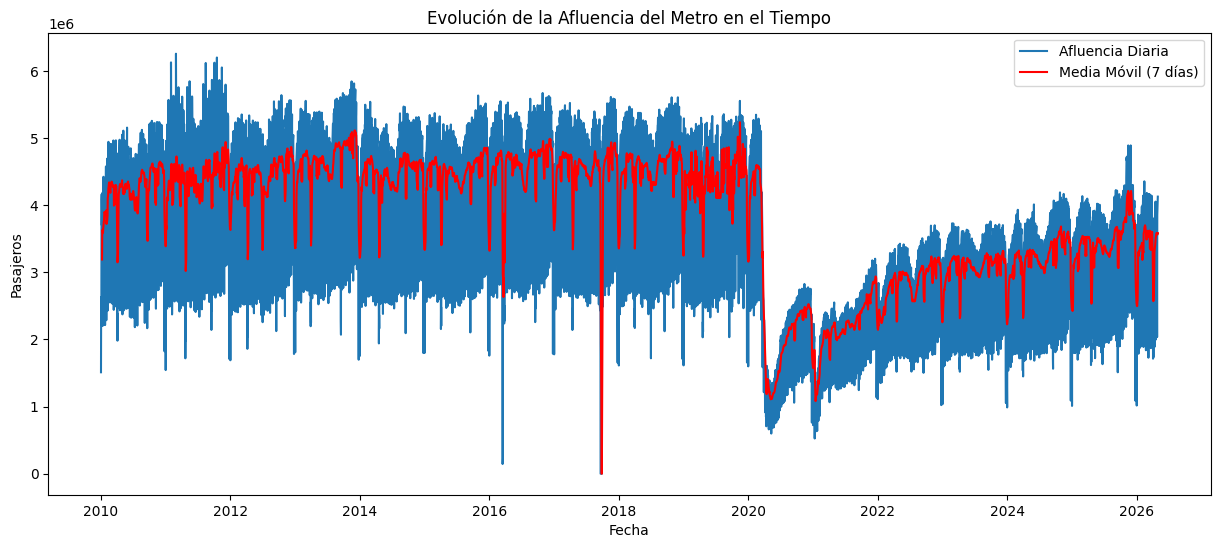

count       5964.00
mean     3830624.29
std      1203458.71
min            0.00
25%      2782836.25
50%      4033299.50
75%      4928676.75
max      6257109.00
Name: afluencia, dtype: float64


In [20]:
# Agrupar por fecha para ver la demanda total del sistema
ts_data = metro.groupby('fecha')['afluencia'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(ts_data['fecha'], ts_data['afluencia'], label='Afluencia Diaria')
# Media móvil de 7 días para suavizar la serie
ts_data['rolling_7d'] = ts_data['afluencia'].rolling(window=7).mean()
plt.plot(ts_data['fecha'], ts_data['rolling_7d'], color='red', label='Media Móvil (7 días)')

plt.title('Evolución de la Afluencia del Metro en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.show()

print(round(af_dia['afluencia'].describe(),2))

*A simple vista se observan patrones de tendencia creciente y ciertos patrones de estacionalidad anual pero sobre todo se nota una diferencia notoria en los datos divididos por la temporada de pandemia, se decidio trabajar con los datos postpandemia a partir de aqui, ya que representan 4 años de datos y aumentando hasta la actualidad (enero 2025)*

# **LIMPIEZA-METRO-NUEVO-DATASET-DESGLOSADO**

Se repite el preprocesamiento para el nuevo dataset desglosado que contiene los datos de semovi a partir del 2021 y se consituyen los datos a usar a partir de enero del 2022

In [21]:
url = "https://datos.cdmx.gob.mx/dataset/f2046fd5-51b5-4876-b008-bd65d95f9a02/resource/cce544e1-dc6b-42b4-bc27-0d8e6eb3ed72/download/afluenciastc_desglosado_02_2026.csv"
metro = pd.read_csv(url, encoding = 'utf-8', parse_dates=True) # parse es para convertir fechas
metro['fecha'] = pd.to_datetime(metro['fecha']) # se le da formato datetime

#Filtrado para obtener solo los años 2022 - 2026
metro = metro[metro['fecha'] >= '2022-01-01'].copy()
metro.pop('mes')
metro['linea'] = metro['linea'].apply(limpiar_texto)
metro['estacion'] = metro['estacion'].apply(limpiar_texto)
metro['estacion'].duplicated().any()
metro['linea'].unique()
metro.isnull().sum()
metro.index
'''metro['fecha'] = pd.to_datetime(metro['fecha']) # se le da formato datetime 
metro.set_index('fecha', inplace=True)'''
type(metro.index)
print(f"Se tiene un total de {metro['estacion'].nunique()} estaciones en todo el conjunto de datos") # nunique cuenta el numero unico de instancias
metro[metro['afluencia'] == 0].count()

#Realizar copia del dataset original para uso en el modelado
dataset_original_copy = metro.copy()



Se tiene un total de 164 estaciones en todo el conjunto de datos


# **EDA-METRO-NUEVO-DATASET-DESGLOSADO**

- estadística descriptiva
- herramientas gráficas 
- creatividad
El análisis exploratorio siempre debe ir acompañado de una pregunta que queramos responder y todo lo que se haga en el análisis debe ser orientado a responder esa pregunta.

En esta agrupacción igual se muestra un análisis general pero tomando en cuenta post-pandemia, que será graficado más adelante, porque como se mencionó los patrones de afluencia cambiaron después de la pandemia

In [22]:
af_dia = metro.groupby('fecha')['afluencia'].sum()
af_dia.to_frame()
af_dia = af_dia.reset_index()
af_dia

,fecha,afluencia
0,2022-01-01,1111885
1,2022-01-02,1441654
2,2022-01-03,2630451
3,2022-01-04,2789531
4,2022-01-05,2841890
...,...,...
1576,2026-04-26,2035739
1577,2026-04-27,3854642
1578,2026-04-28,3937374
1579,2026-04-29,4002142


In [23]:
af_dia_est = metro.groupby(['fecha', 'linea', 'estacion'])['afluencia'].sum()
af_dia_est.to_frame()
af_dia_est = af_dia_est.reset_index()
af_dia_est

,fecha,linea,estacion,afluencia
0,2022-01-01,linea 1,balbuena,2715
1,2022-01-01,linea 1,balderas,5973
2,2022-01-01,linea 1,boulevard puerto aéreo,5633
3,2022-01-01,linea 1,candelaria,17059
4,2022-01-01,linea 1,chapultepec,11955
...,...,...,...,...
308290,2026-04-30,linea b,romero rubio,16158
308291,2026-04-30,linea b,río de los remedios,16848
308292,2026-04-30,linea b,san lázaro,14443
308293,2026-04-30,linea b,tepito,14961


Dataset que servirá más adelante para un análisis más particular donde se tome en cuenta las estaciones y a que línea pertenece

In [24]:
#el dataset ya no es muy grande, por lo que ahora si se puede guardar como excel
#metro.to_excel('metro_limpio.xlsx', index= False)

Se observa la serie de tiempo que se ha cortado post-pandemia donde se observa el comportamiento esperado de recuperación de los niveles de afluencia conforme pasa cada año.

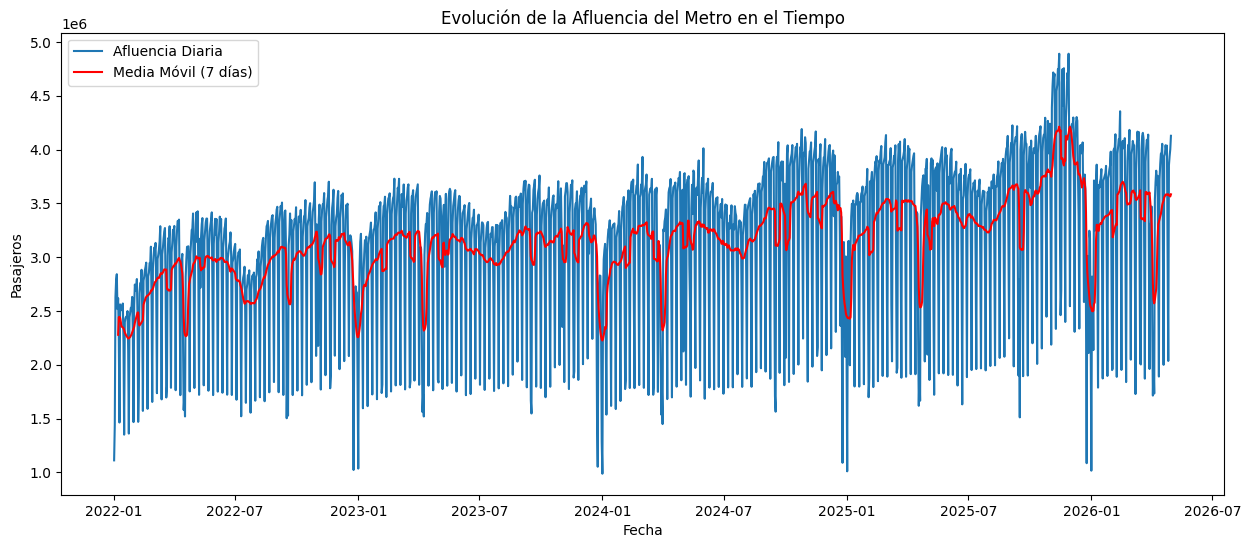

count       1581.00
mean     3149817.47
std       739254.31
min       987685.00
25%      2810069.00
50%      3332697.00
75%      3664177.00
max      4890902.00
Name: afluencia, dtype: float64


In [25]:
# Agrupar por fecha para ver la demanda total del sistema
ts_data = metro.groupby('fecha')['afluencia'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(ts_data['fecha'], ts_data['afluencia'], label='Afluencia Diaria')
# Media móvil de 7 días para suavizar la serie
ts_data['rolling_7d'] = ts_data['afluencia'].rolling(window=7).mean()
plt.plot(ts_data['fecha'], ts_data['rolling_7d'], color='red', label='Media Móvil (7 días)')

plt.title('Evolución de la Afluencia del Metro en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.show()

print(round(af_dia['afluencia'].describe(),2))

In [26]:
df_sin_index = metro.reset_index()
df_sin_index['año'] = df_sin_index['fecha'].dt.year

In [27]:
af_linea = df_sin_index.groupby(['año','linea','estacion','tipo_pago'])['afluencia'].sum()
af_linea.to_frame()
af_linea = af_linea.reset_index()
af_linea

,año,linea,estacion,tipo_pago,afluencia
0,2022,linea 1,balbuena,Boleto,768733
1,2022,linea 1,balbuena,Gratuidad,82189
2,2022,linea 1,balbuena,Prepago,755094
3,2022,linea 1,balderas,Boleto,1462006
4,2022,linea 1,balderas,Gratuidad,1919099
...,...,...,...,...,...
2923,2026,linea b,tepito,Gratuidad,47769
2924,2026,linea b,tepito,Prepago,1903216
2925,2026,linea b,villa de aragón,Boleto,0
2926,2026,linea b,villa de aragón,Gratuidad,149589


Sin tomar en cuenta el año 2026, En el siguiente gráfico se nota con mayor precisión el aumento de la afluencia por año, creciendo aproximadamente 1% cada año, entonces se espera cierta tendencia en las series de tiempo

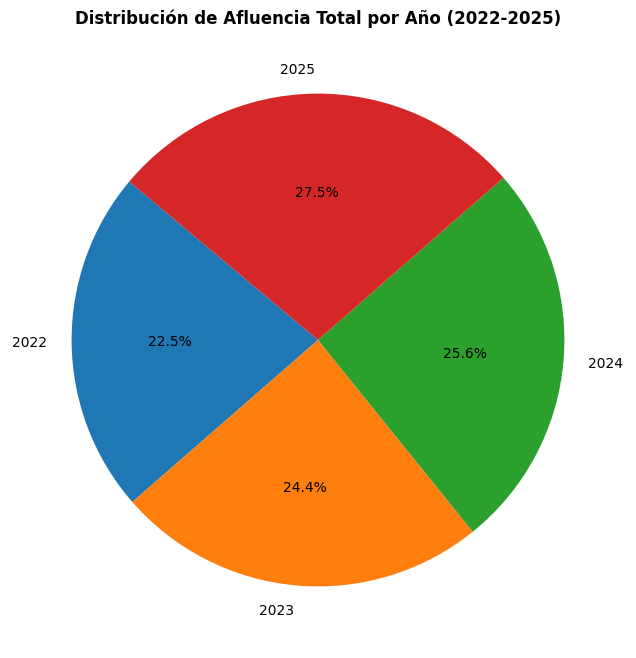

In [28]:
#pie chart de la afluencia total por año a partir del 2022 al 2026
af_anual = df_sin_index.groupby('año')['afluencia'].sum().reset_index()
af_anual = af_anual[af_anual['año'] < 2026]
plt.figure(figsize=(8, 8))
plt.pie(af_anual['afluencia'], labels=af_anual['año'], autopct='%1.1f%%', startangle=140)
plt.title('Distribución de Afluencia Total por Año (2022-2025)', fontweight='bold')
plt.show()

Analizamos la afluencia sumada del periodo de años analizados (2022-2026) pero por línea del metro, para conocer las líneas mas afluenciadas en el periodo completo analizado

El gráfico muestra el siguiente top de lineas mas afluenciadas
1. Línea 2 (17.5%)
2. Línea 3 (14.9%)
3. Línea b (10.9%)
4. Línea 8 (10.6%)
5. Línea 1 (8.2%)


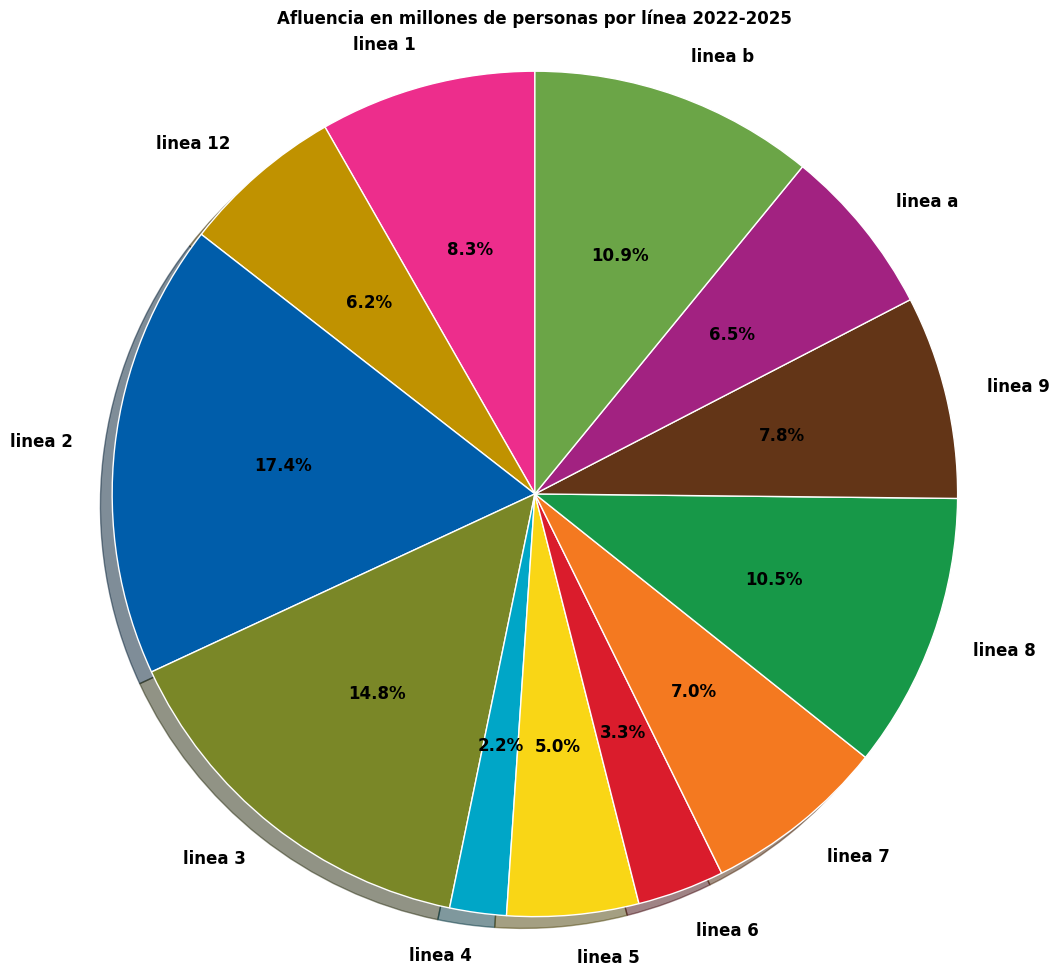

In [29]:
import matplotlib.pyplot as plt

# Agrupar por línea (por si hay más de un registro por línea)
pie_data = af_linea.groupby('linea')['afluencia'].sum()

# Colores oficiales del Metro CDMX en Hex
colores_linea = {
    'linea 1': '#ED2D8C',   # Rosa mexicano
    'linea 2': '#005DAA',   # Azul
    'linea 3': '#7A8727',   # Verde olivo
    'linea 4': '#00A6C7',   # Cian
    'linea 5': '#F9D616',   # Amarillo
    'linea 6': '#DA1C2C',   # Rojo
    'linea 7': '#F47920',   # Naranja
    'linea 8': '#179848',   # Verde bandera
    'linea 9': '#633517',   # Café
    'linea a': '#A22281',   # Morado
    'linea b': '#6BA547',   # Verde con gris
    'linea 12': '#C09200'   # Oro
}

# Mapear los colores en el orden correcto de los datos
colores = [colores_linea.get(linea, '#CCCCCC') for linea in pie_data.index]

plt.figure(figsize=(12,12))
plt.pie(
    pie_data.values,
    labels=pie_data.index,
    colors=colores,  # Añadido: colores oficiales del Metro
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},  # Bordes blancos
    textprops={'fontsize': 12, 'fontweight': 'bold'},  # Estilo del texto
    shadow=True  # Sombra para efecto 3D
)

plt.title('Afluencia en millones de personas por línea 2022-2025', fontweight='bold')
plt.axis('equal')  
plt.show()

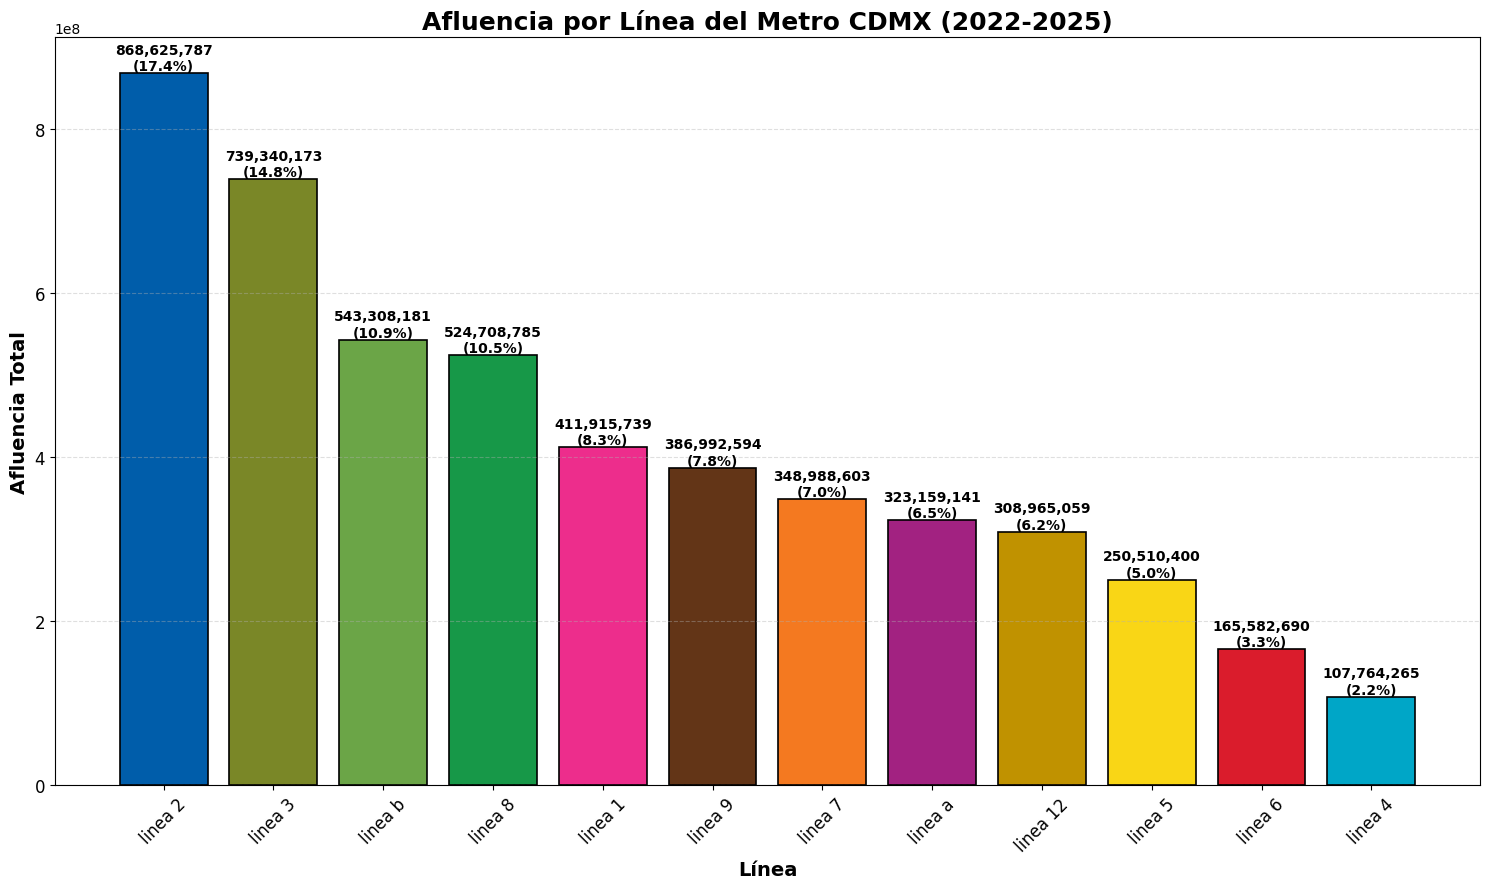

In [30]:

# Agrupar por línea
bar_data = af_linea.groupby('linea')['afluencia'].sum().sort_values(ascending=False)

# Calcular porcentajes
total = bar_data.sum()
porcentajes = (bar_data / total) * 100

# Colores oficiales del Metro CDMX
colores_linea = {
    'linea 1': '#ED2D8C',
    'linea 2': '#005DAA',
    'linea 3': '#7A8727',
    'linea 4': '#00A6C7',
    'linea 5': '#F9D616',
    'linea 6': '#DA1C2C',
    'linea 7': '#F47920',
    'linea 8': '#179848',
    'linea 9': '#633517',
    'linea a': '#A22281',
    'linea b': '#6BA547',
    'linea 12': '#C09200'
}

# Asignar colores
colores = [colores_linea.get(linea, '#CCCCCC') for linea in bar_data.index]

plt.figure(figsize=(15, 9))

bars = plt.bar(
    bar_data.index,
    bar_data.values,
    color=colores,
    edgecolor='black',
    linewidth=1.2
)

# Etiquetas con valor y porcentaje
for bar, valor, pct in zip(bars, bar_data.values, porcentajes):
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura,
        f'{valor:,.0f}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Afluencia por Línea del Metro CDMX (2022-2025)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Línea', fontsize=14, fontweight='bold')
plt.ylabel('Afluencia Total', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

A continuación se desglosa la afluencia total del periodo 2022-2026 en función de cada línea dividido por estación correspondiente a dicha línea.

De esta gráfica podemos notar el siguiente top de estaciones mas afluenciadas por línea:

1. Línea 1:
    1. Chapultepec
    2. Merced
    3. Insurgentes 
    4. Pantitlán
2. Línea 2:
    1. Cuatro caminos
    2. Tasqueña
    3. Zocalo / Tenochtitlan
3. Línea 3:
    1. Indios Verdes
    2. Universidad
    3. Copilco
4. Línea 4:
    1. Martin Carrera
    2. Candelaria
    3. Fray Servando
5. Línea 5:
    1. Pantitlán
    2. Politecnico
    3. Autobuses del norte
    4. Puerto áereo
6. Línea 6:
    1. Martin carrera
    2. Ferreria / Arena CDMX
    3. Lindavista
    4. El rosario
7. Línea 7:
    1. Barranca del Muerto
    2. Polanco
    3. Audítorio
    4. El rosario
8. Línea 8
    1. Constitución de 1917
    2. San Juan de Letrán
    3. Coyuya
    4. UAM
9. Línea 9:
    1. Tacubaya
    2. Pantitlán
    3. Chilpancingo
10. Línea a:
    1. La paz
    2. Santa Marta
    3. Pantitlán
11. Línea b:
    1. Buenavista
    2. Ciudad Azteca
    3. Mezquis
12. Línea 12:
    1. Tlahuac
    2. Periferico Oriente
    3. Insurgentes Sur

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


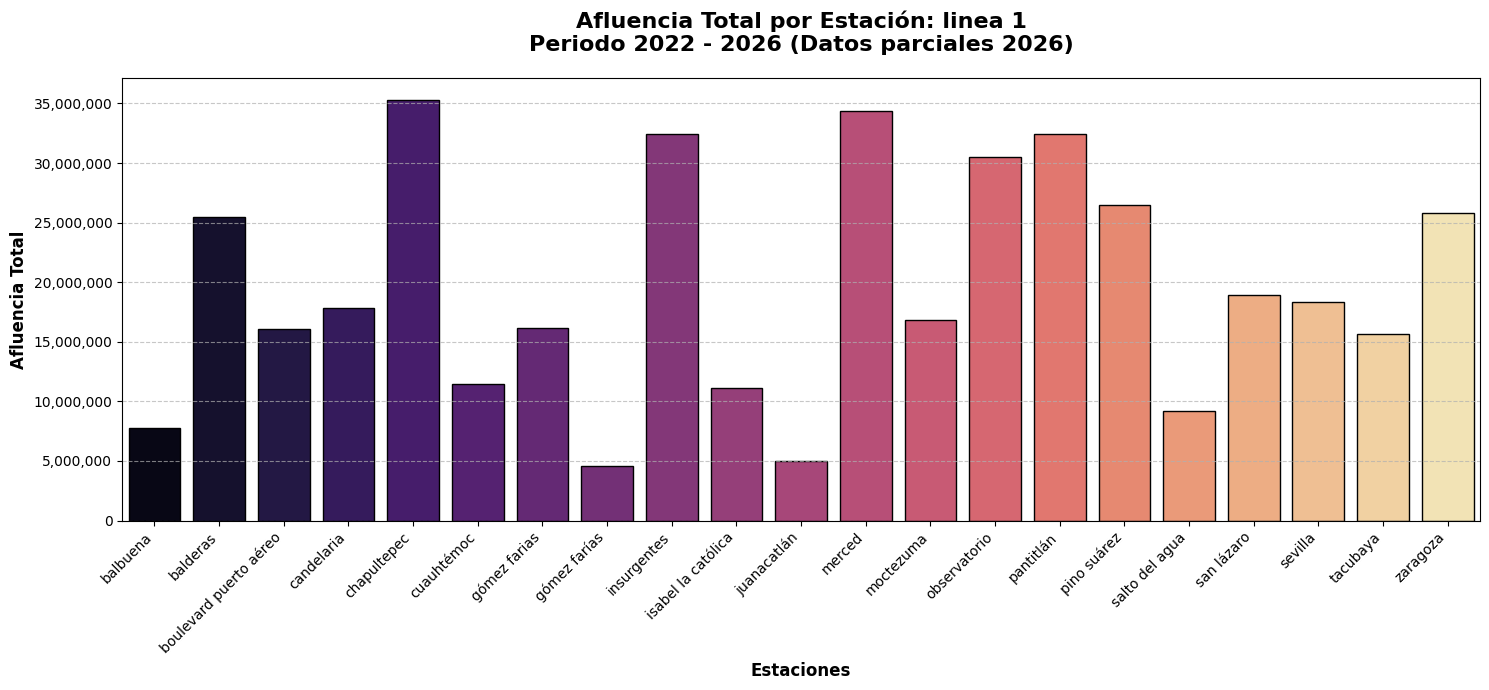

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


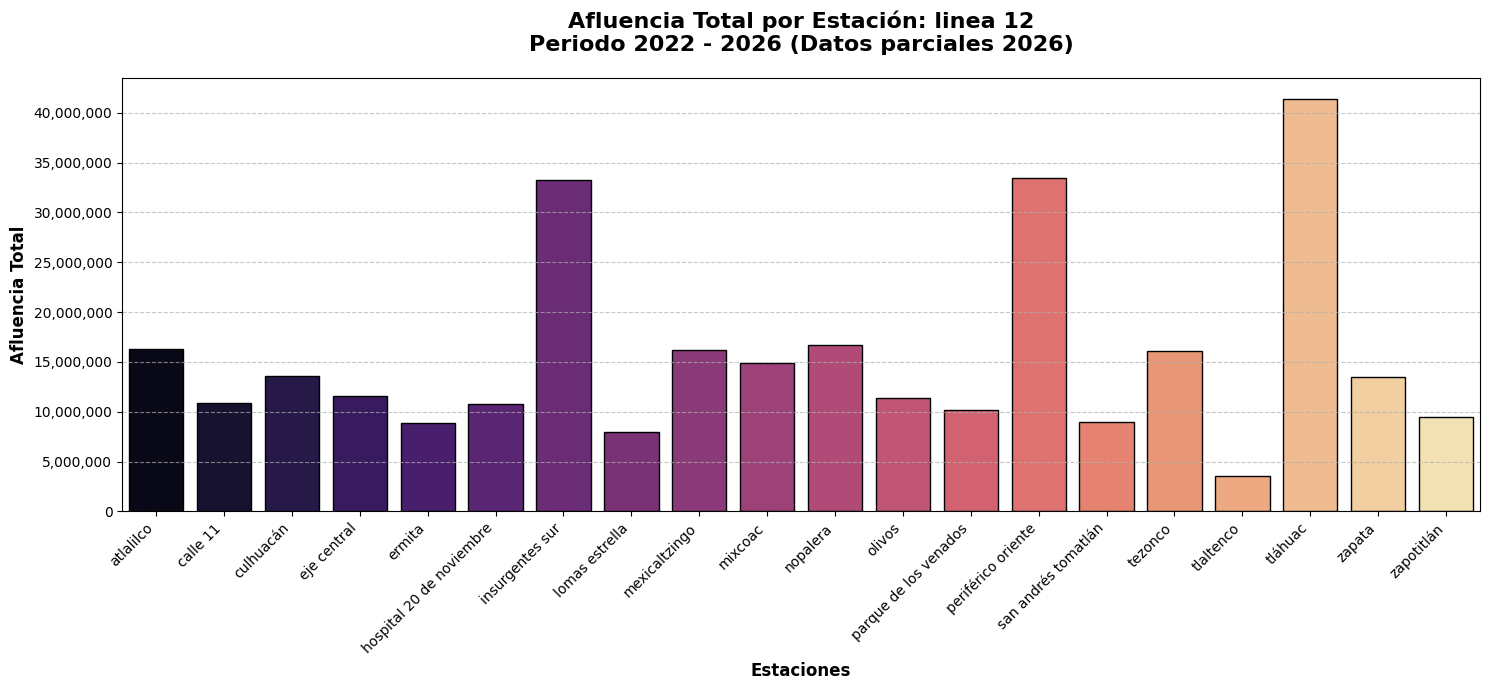

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


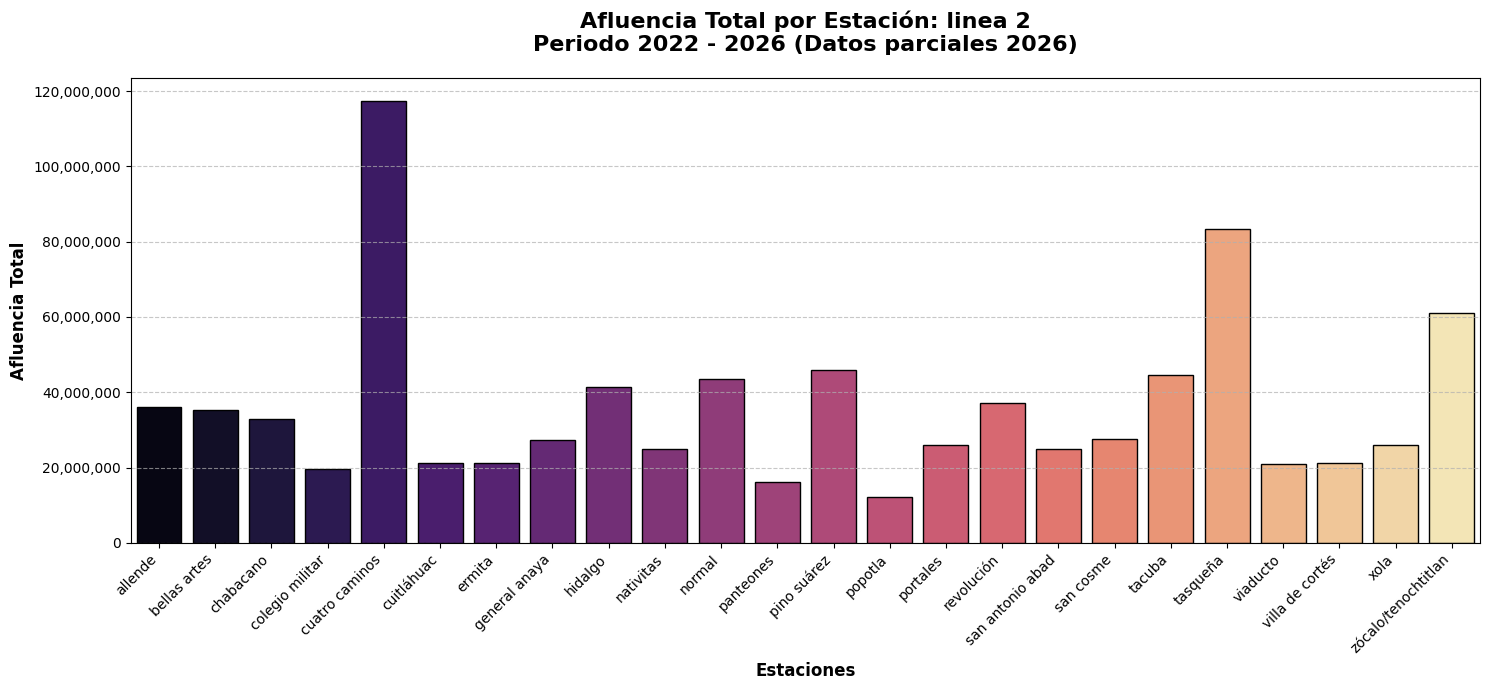

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


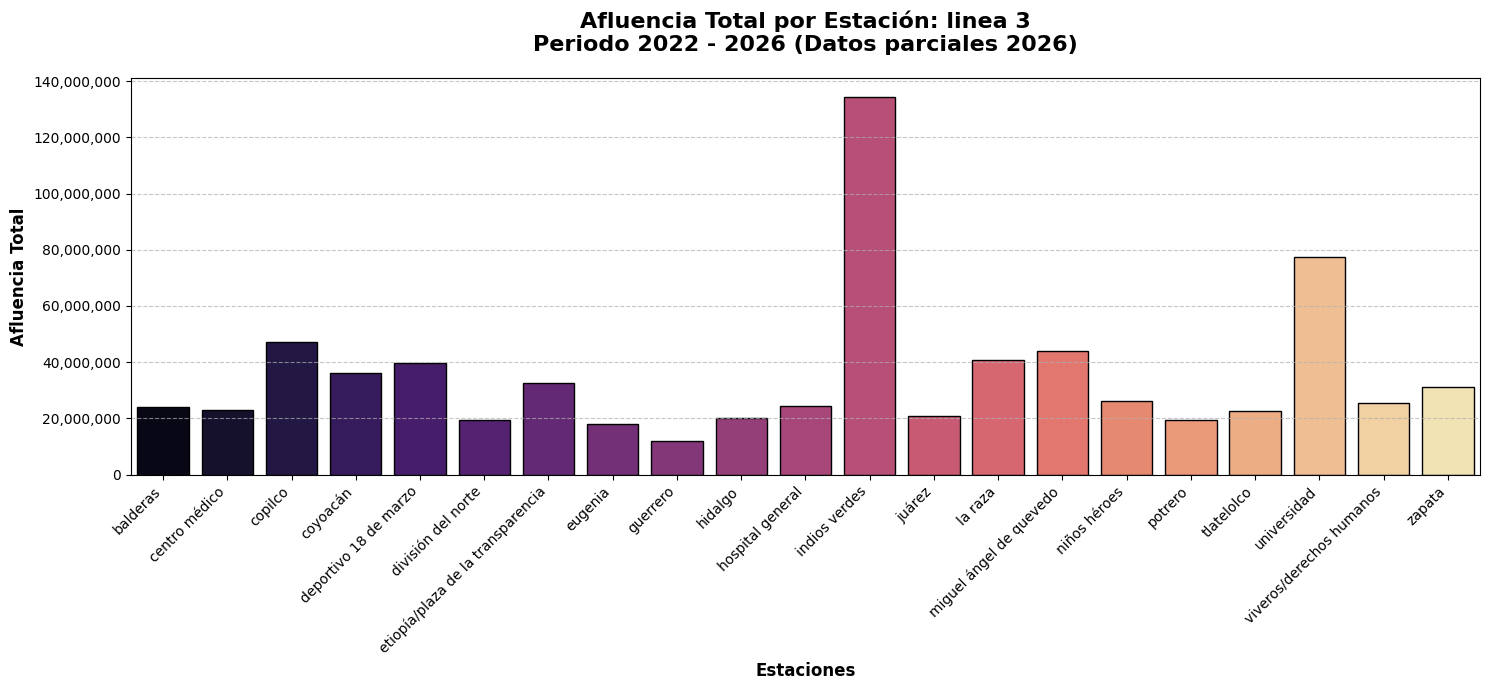

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


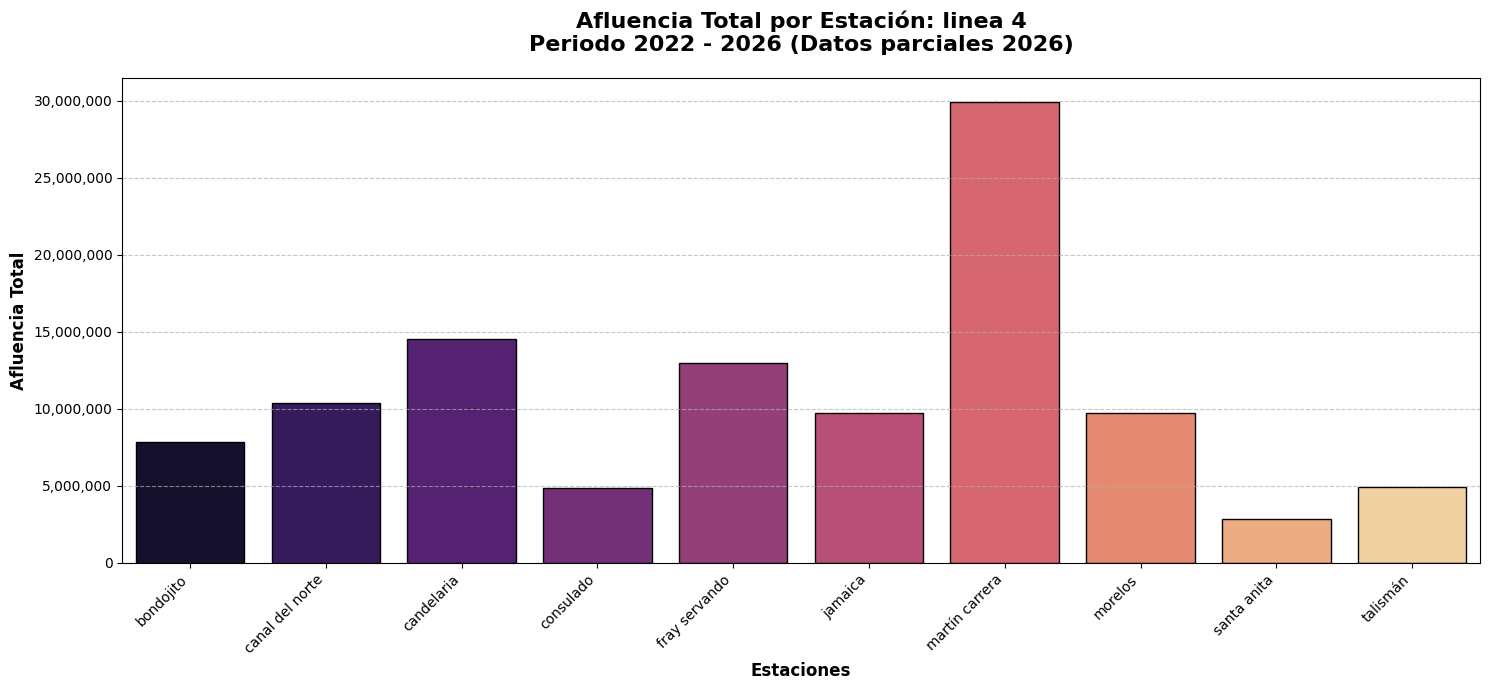

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


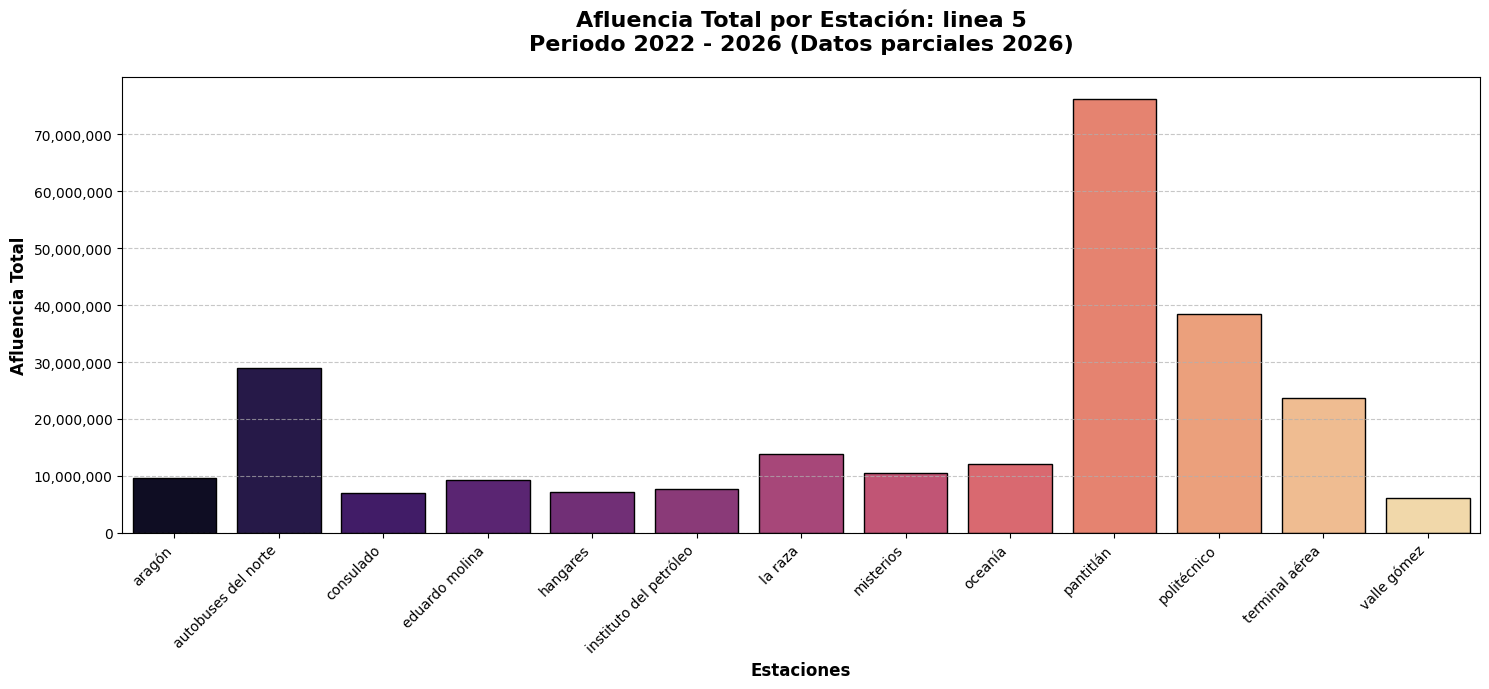

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


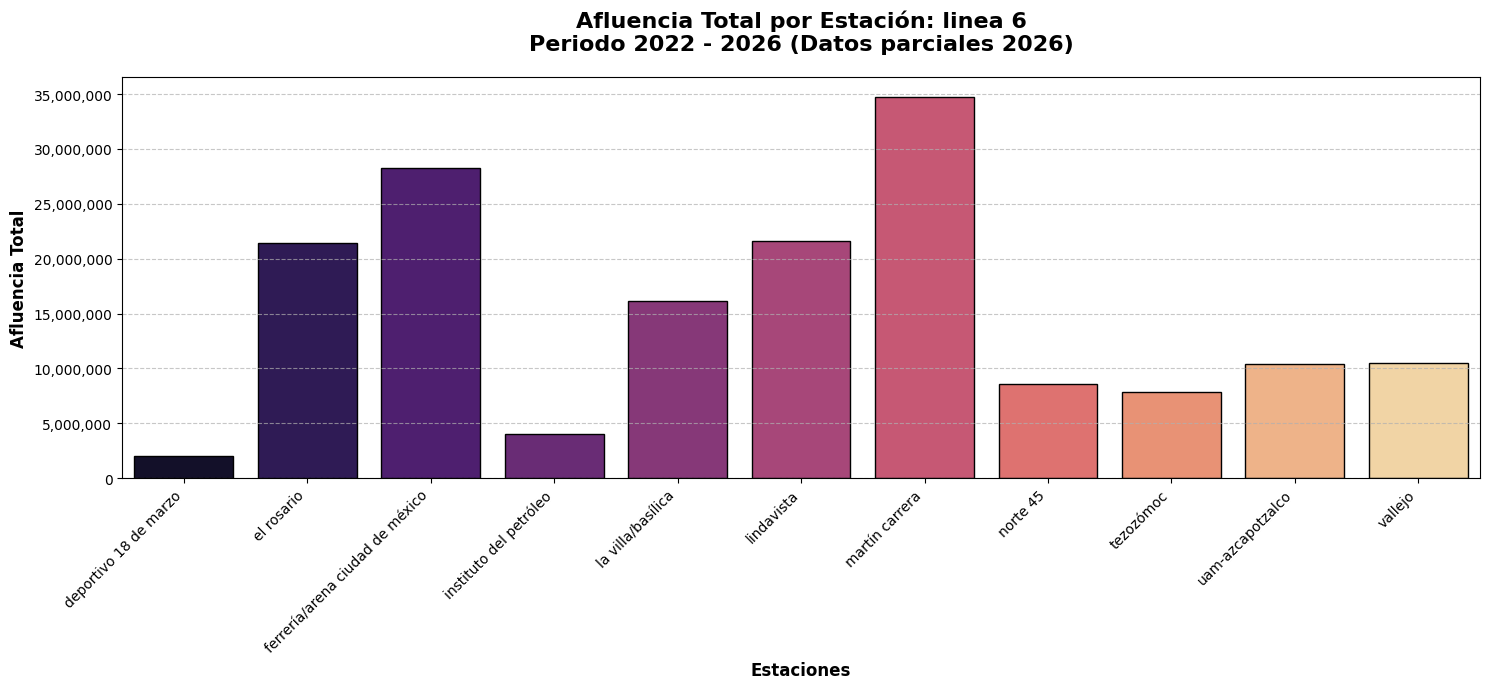

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


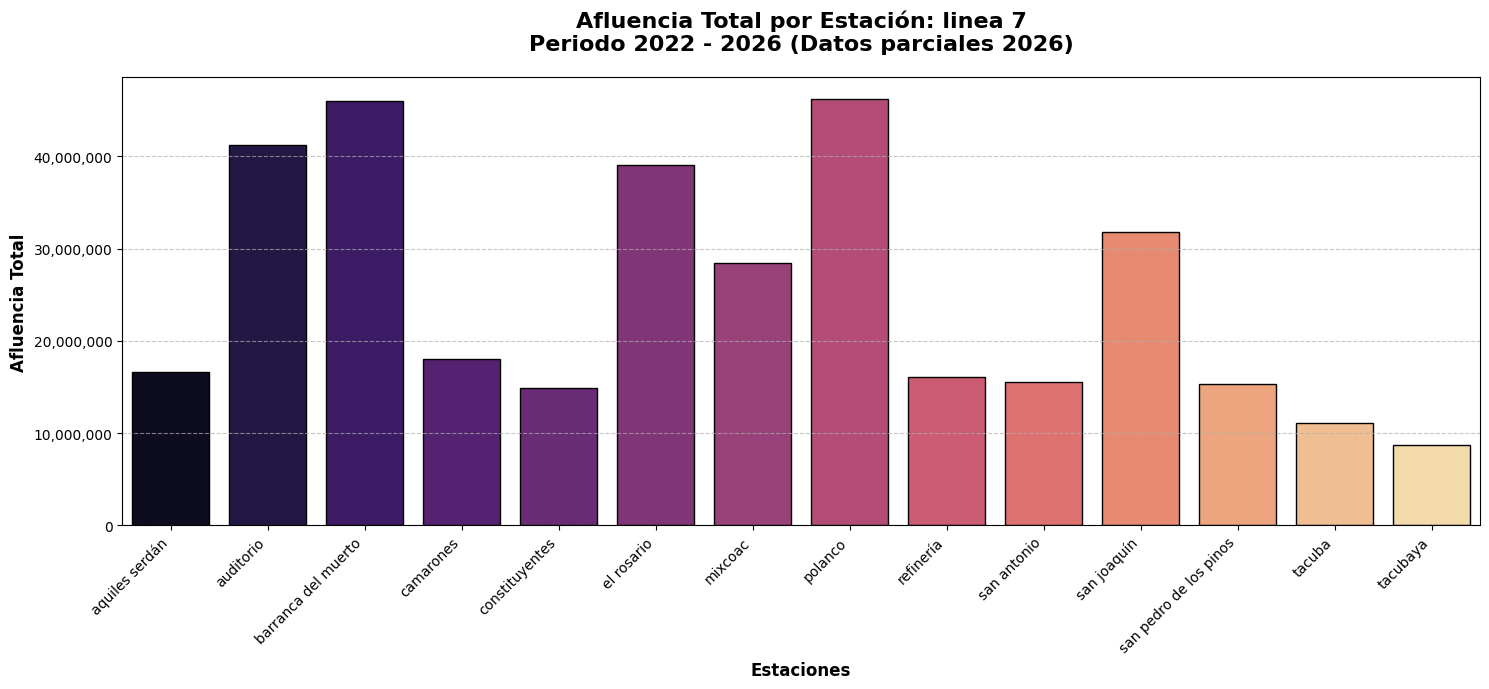

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


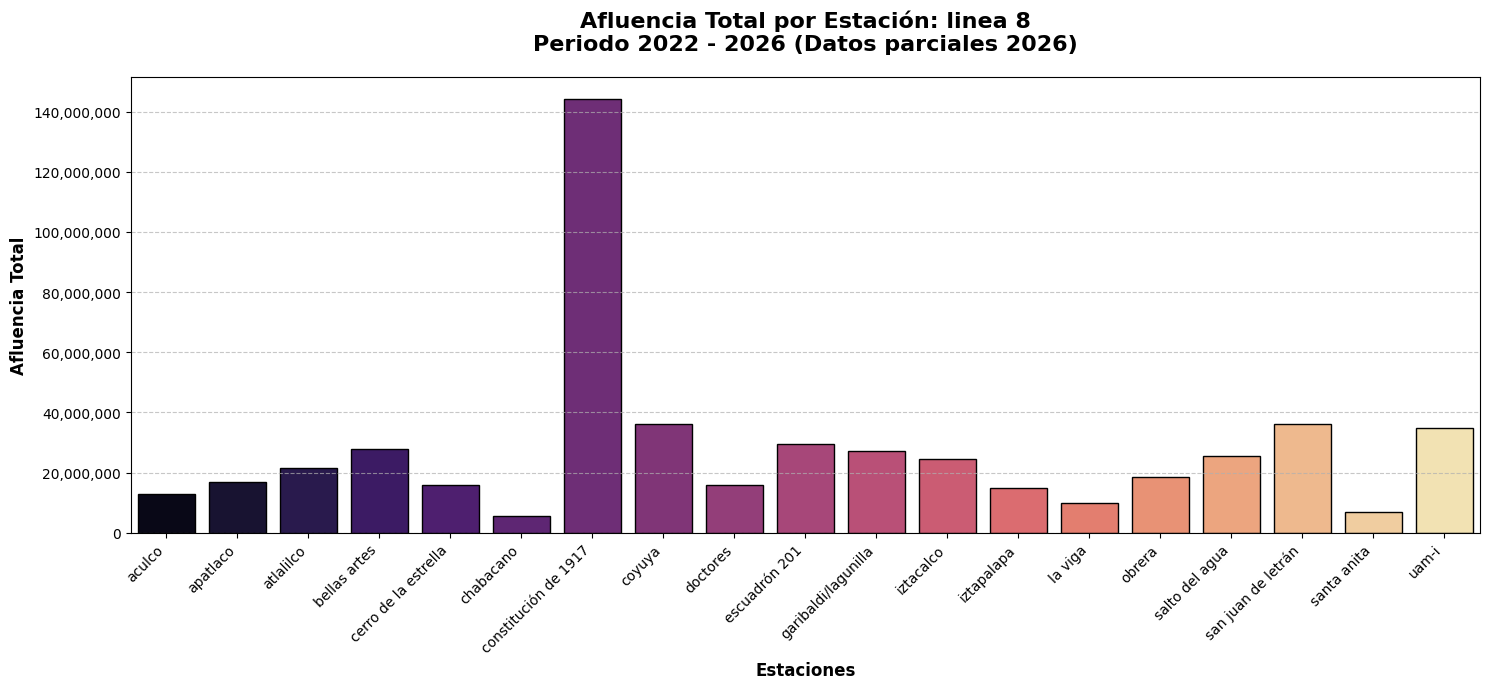

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


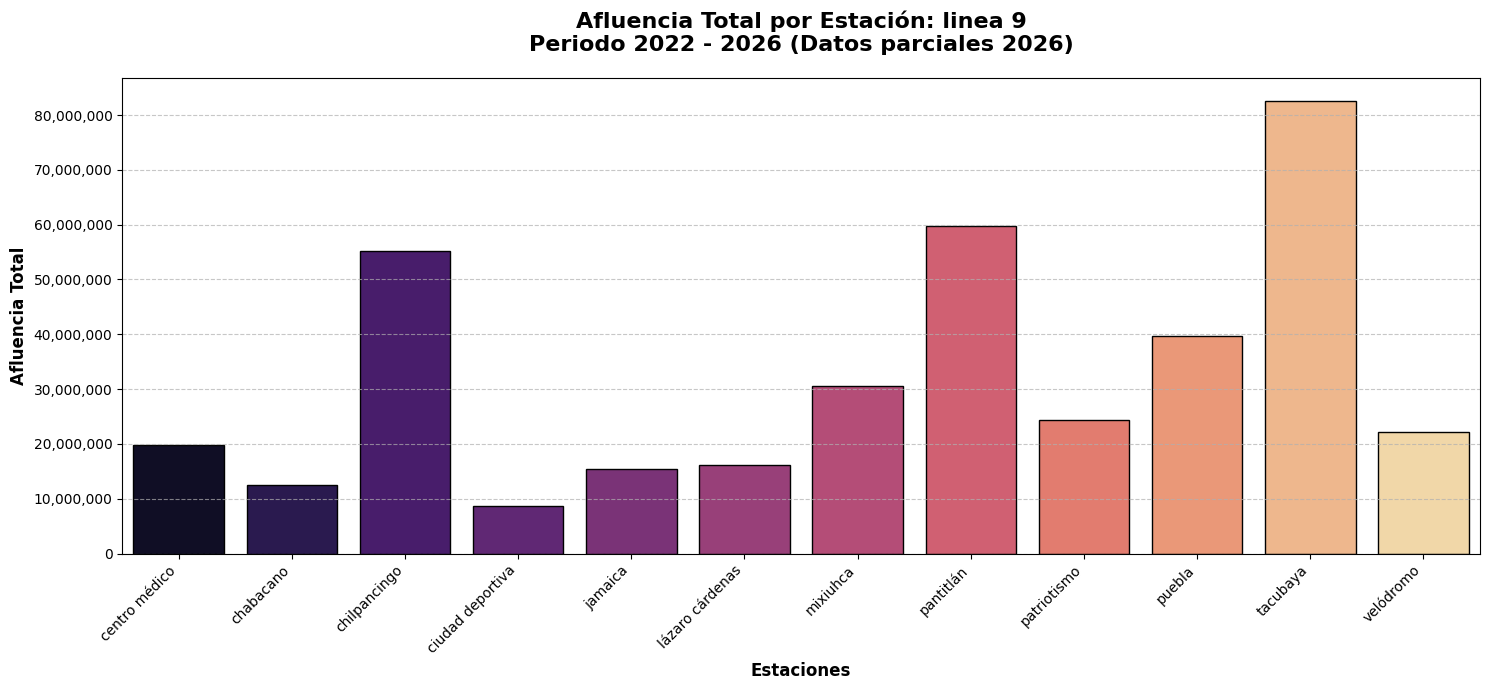

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


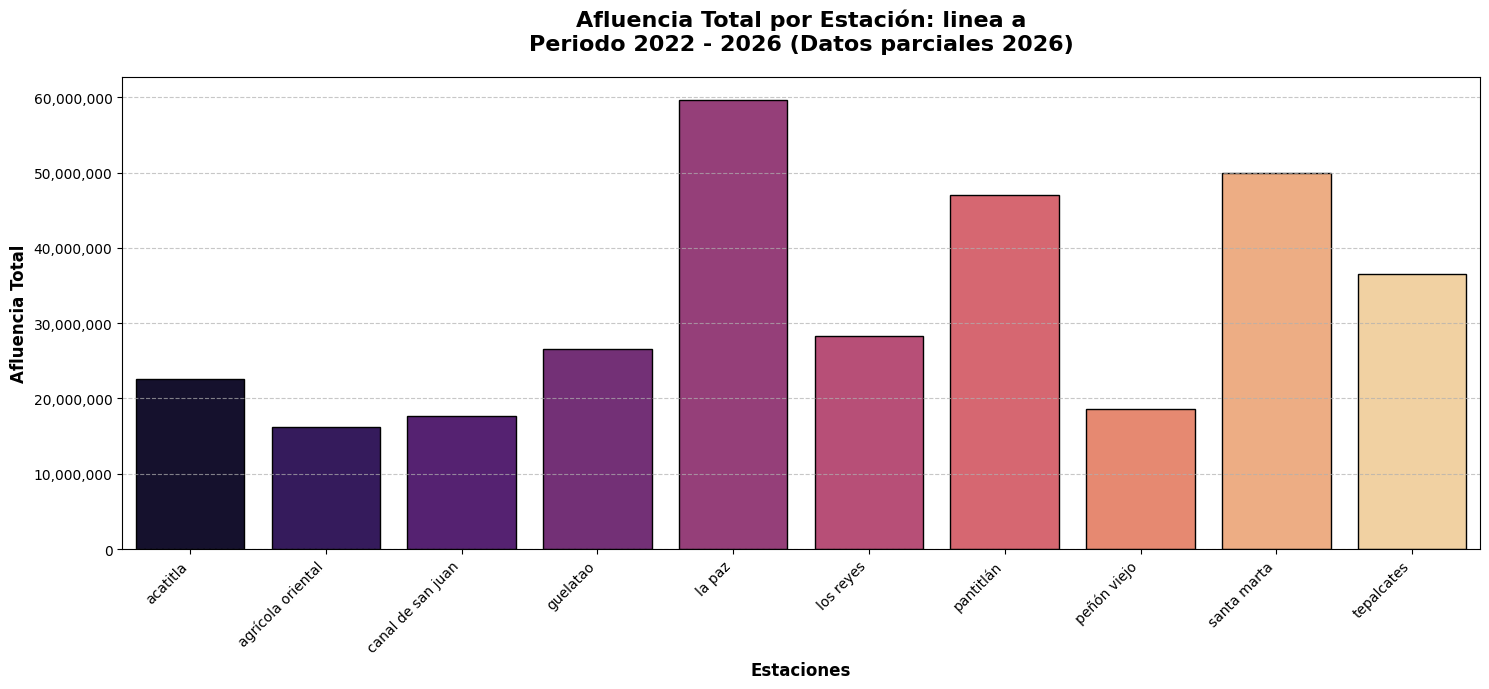

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/197225238.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


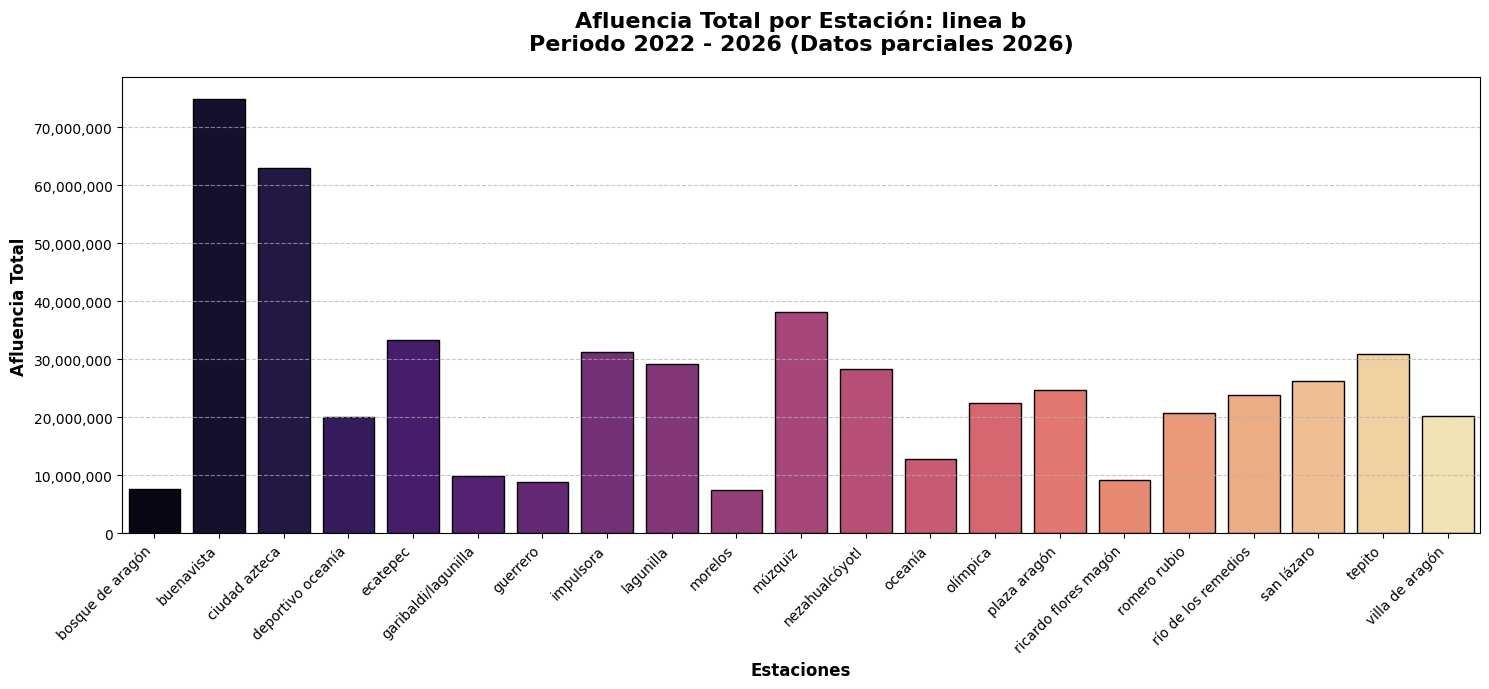

In [31]:
df_agrupado = metro.groupby(['linea', 'estacion'])['afluencia'].sum().reset_index()

# 2. Obtenemos la lista de todas las líneas únicas para iterar sobre ellas
lineas = sorted(df_agrupado['linea'].unique())

# 3. Ciclo para generar una gráfica de barras por cada línea
for linea in lineas:
    # Filtramos los datos solo para la línea actual y ordenamos alfabéticamente por estación
    data_linea = df_agrupado[df_agrupado['linea'] == linea].sort_values('estacion')
    
    plt.figure(figsize=(15, 7))
    
    # Creamos la gráfica de barras
    # Usamos un gradiente de color (palette) para que sea visualmente atractivo
    barplot = sns.barplot(
        data=data_linea, 
        x='estacion', 
        y='afluencia', 
        palette='magma',
        edgecolor='black'
    )
    
    # --- Configuración estética (basada en tu estilo previo) ---
    plt.title(f'Afluencia Total por Estación: {linea}\nPeriodo 2022 - 2026 (Datos parciales 2026)', 
              fontsize=16, fontweight='bold', pad=20)
    
    plt.xlabel('Estaciones', fontsize=12, fontweight='bold')
    plt.ylabel('Afluencia Total', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right', fontsize=10)
    
    # Opcional: Si los números son muy grandes, puedes formatear el eje Y 
    # para que se lea en millones o use comas
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.show()

En el gráfico de afluencia por tipo de pago podemos ver como practicamente en el 2025 desapareció la modalidad del boleto en toda la red del metro, por lo que esta información no es reelevante para modelos de series de tiempo porque es indiferente el metodo usado para transladarse ya que lo que nos importa es la afluencia

<Figure size 5000x5000 with 0 Axes>

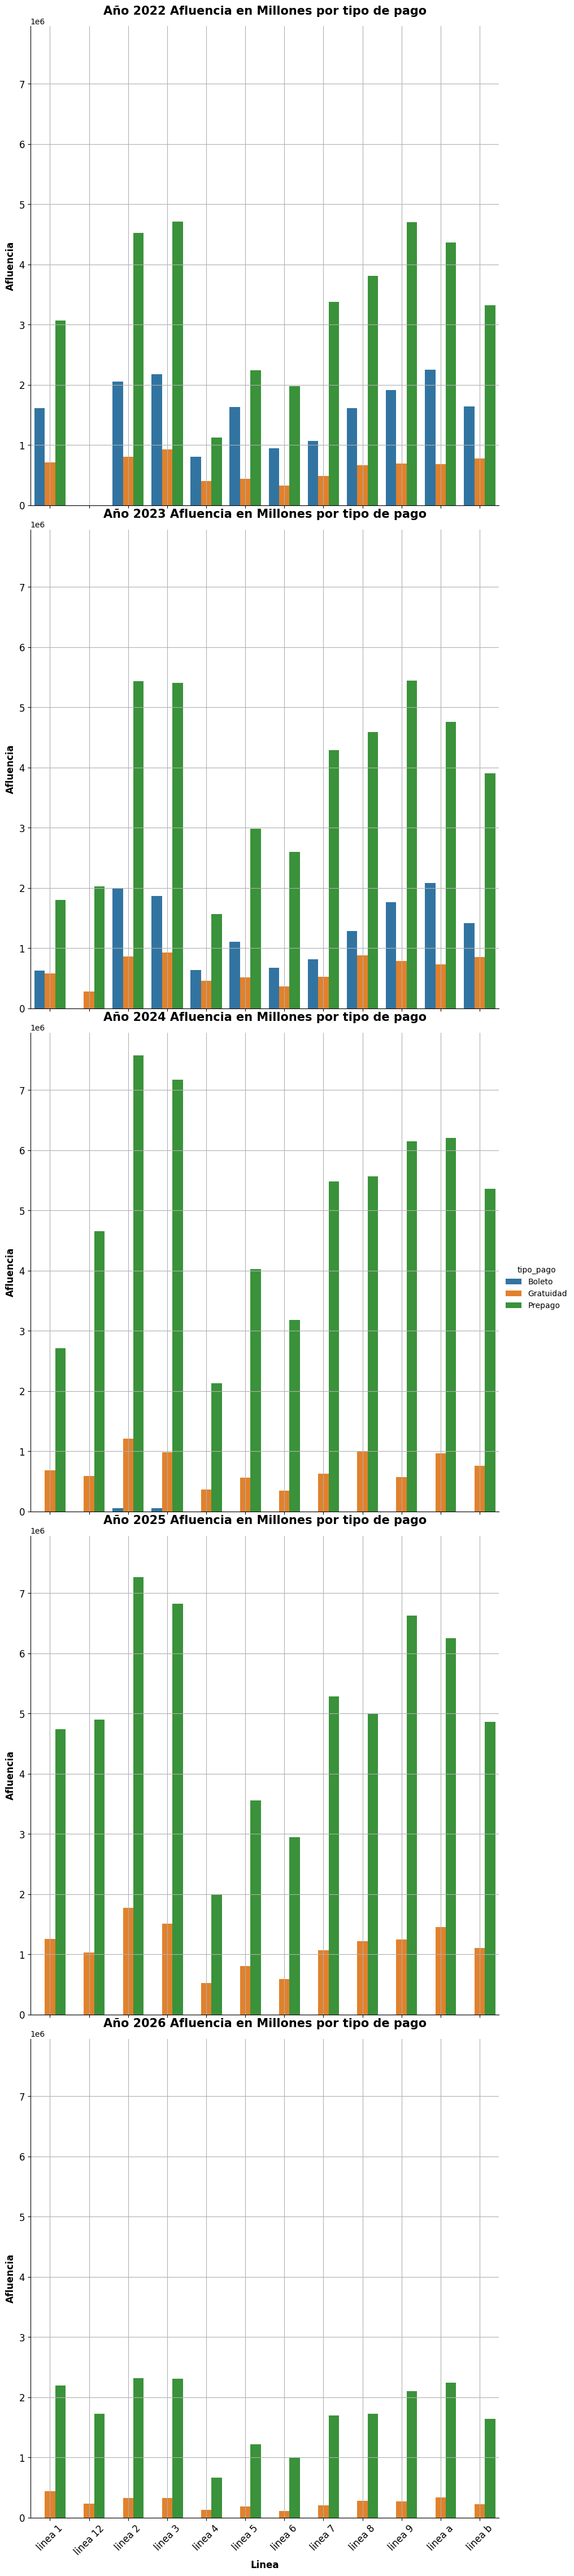

In [32]:
plt.figure(figsize=(50, 50))
ax = sns.catplot(x = 'linea',
            y = 'afluencia',
            data = af_linea, 
            kind='bar', 
            hue='tipo_pago',
            row='año',
            palette= 'tab10',
            height= 9,
            aspect=1,
            errorbar= None
            )


títulos = [ 'Año 2022', 'Año 2023', 'Año 2024', 'Año 2025', 'Año 2026']  

# Iterar y agregar títulos
for i,j in enumerate(ax.axes.flat):
    # Personalizar ticks
    j.tick_params(axis='y', labelsize=12)
    j.tick_params(axis='x', labelsize=12, rotation=45)
    j.set_ylabel('Afluencia', fontsize= 12, fontweight='bold')
    j.set_xlabel('Linea', fontsize= 12, fontweight='bold')
    j.set_title(f'{títulos[i]} Afluencia en Millones por tipo de pago', fontsize=15, fontweight='bold', pad=15)
    j.grid(True)
plt.show()

De la siguiente gráfica de distribución de la afluencia acumulada del 2022-2026 podemos notar lo siguiente:
Los outliers superiores (los puntos que llegan a los 30M) no son errores; son las estaciones "ancla" del sistema (como Pantitlán, Indios Verdes o Cuatro Caminos).

Podemos notar que la red del Metro es altamente dependiente de menos del 5% de sus estaciones. Si una de estas estaciones de "30 millones" falla, el impacto sistémico es masivo, a diferencia de las estaciones que están dentro de la "caja" (el promedio).

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3033546867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


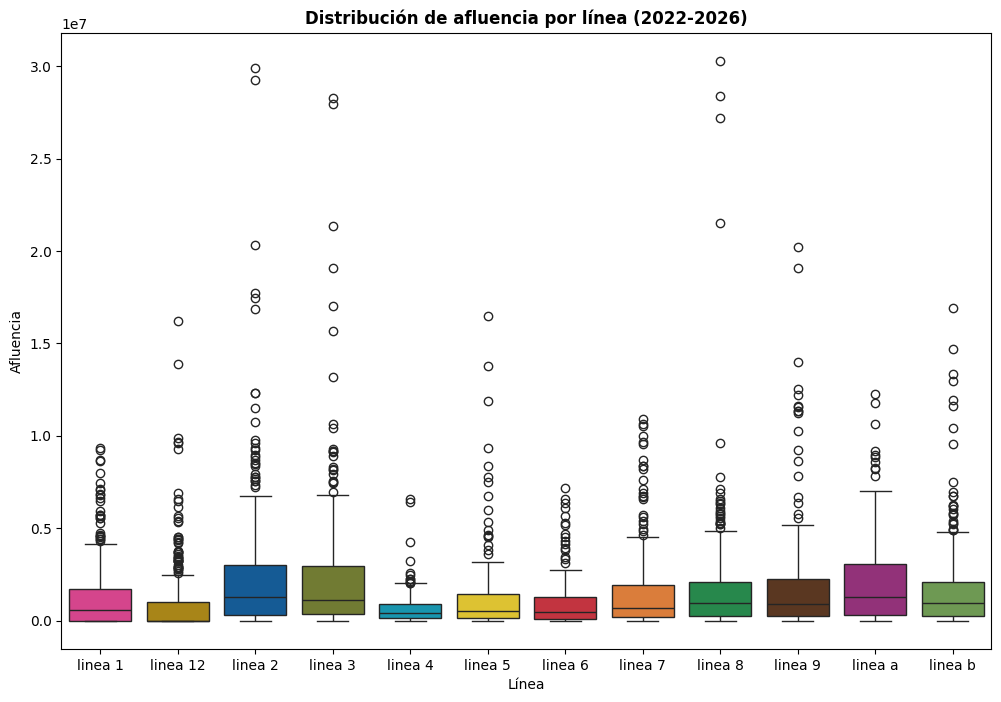

In [33]:
plt.figure(figsize=(12,8))

sns.boxplot(
    data=af_linea,
    x='linea',
    y='afluencia',
    palette=colores_linea
)

plt.title('Distribución de afluencia por línea (2022-2026)', fontweight='bold')
plt.xlabel('Línea')
plt.ylabel('Afluencia')

plt.show()

El siguiente gráfico de distribución diaria por línea muestra el comportamiento diario normal de la afluencia en cada una de las líneas del sistema del metro, esto nos será muy relevante mas adelante

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/2102467713.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


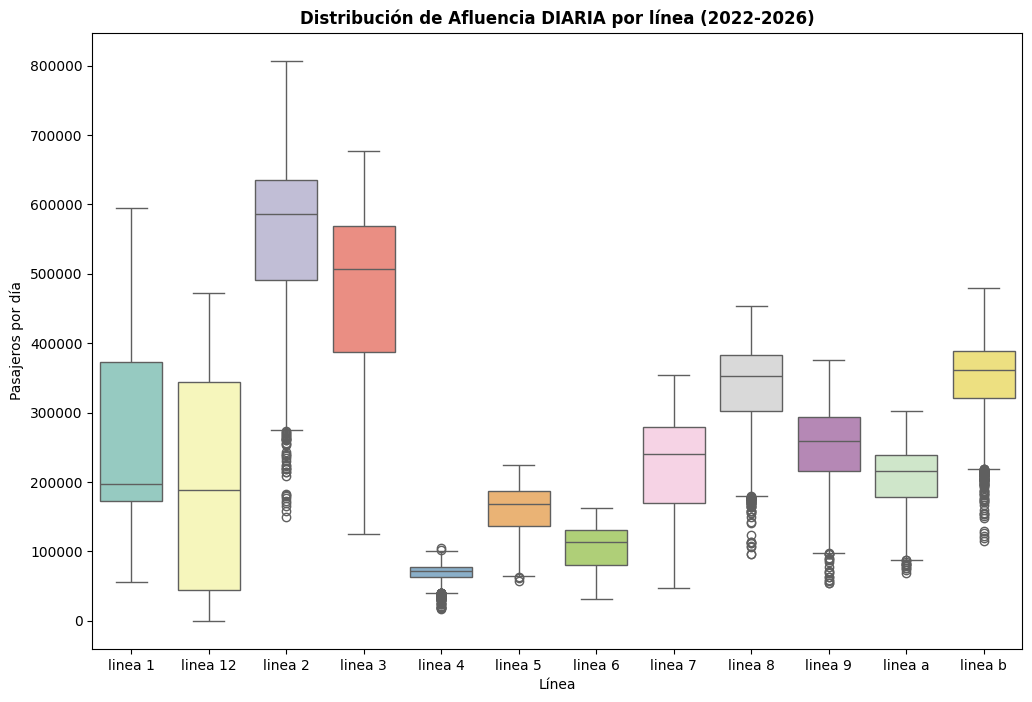

In [34]:
# 1. Agrupamos por FECHA y LINEA para tener el total diario por línea
af_diaria_linea = df_sin_index.groupby(['fecha', 'linea'])['afluencia'].sum().reset_index()

# 2. Ahora sí, generamos el boxplot con DATOS DIARIOS
plt.figure(figsize=(12,8))
sns.boxplot(
    data=af_diaria_linea,
    x='linea',
    y='afluencia',
    palette='Set3'
)

plt.title('Distribución de Afluencia DIARIA por línea (2022-2026)', fontweight='bold')
plt.xlabel('Línea')
plt.ylabel('Pasajeros por día') # La escala ahora será de miles, no millones
plt.show()

## Mapa de calor

El siguiente mapa de calor se realizó con la intención de ver meses más afluenciados y se nota que octubre y noviembre son unos de los meses con mayor afluencia, especialmente en 2025 se nota el crecimiento en la alfuencia

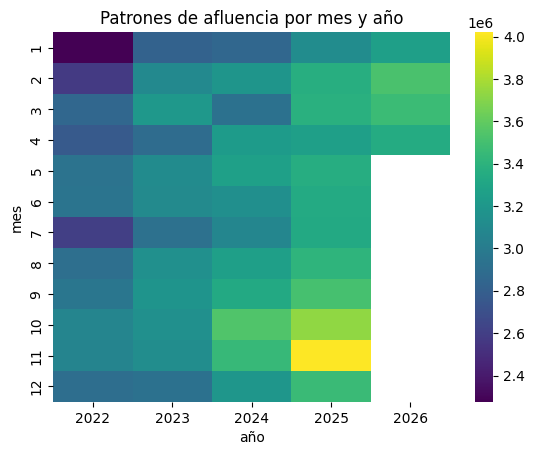

In [35]:
af_dia['mes'] = af_dia['fecha'].dt.month
af_dia['año'] = af_dia['fecha'].dt.year

tabla = af_dia.pivot_table(
    values='afluencia',
    index='mes',
    columns='año'
)

sns.heatmap(tabla, cmap='viridis')
plt.title('Patrones de afluencia por mes y año')
plt.show()

*La matriz de correlación muestran poca correlación si acaso se nota un pequeño grado de correlación entre pares de años consecutivos y esto es por la tendencia que va incrementando cada año*

anio      2022      2023      2024      2025      2026
anio                                                  
2022  1.000000  0.295543 -0.091023 -0.055705 -0.117111
2023  0.295543  1.000000  0.241766 -0.159993 -0.209203
2024 -0.091023  0.241766  1.000000 -0.128592 -0.205587
2025 -0.055705 -0.159993 -0.128592  1.000000  0.291828
2026 -0.117111 -0.209203 -0.205587  0.291828  1.000000


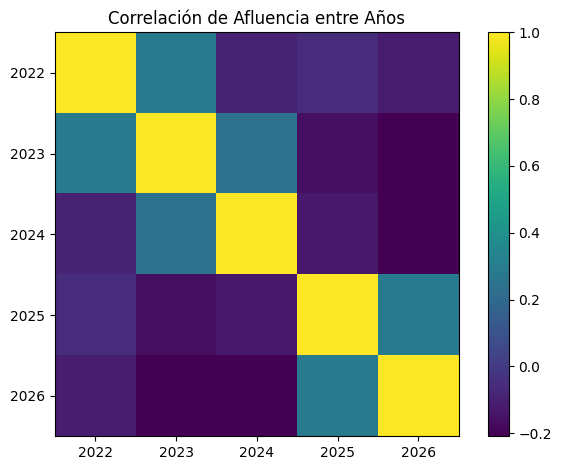

In [36]:
df = metro[metro['anio'].between(2021, 2026)]

df_diario = df.groupby(['fecha', 'anio'])['afluencia'].sum().reset_index()
df_diario['dayofyear'] = df_diario['fecha'].dt.dayofyear


df_pivot = df_diario.pivot(
    index='dayofyear',
    columns='anio',
    values='afluencia'
)
corr_matrix = df_pivot.corr()
print(corr_matrix)

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlación de Afluencia entre Años")
plt.tight_layout()
plt.show()


In [37]:
# Calcular suma total y promedio diario por estación
top10_estaciones = (af_dia_est.groupby(['linea', 'estacion'])
                    .agg(
                        suma_total=('afluencia', 'sum'),
                        promedio_diario=('afluencia', 'mean')
                    )
                    .round(2)
                    .sort_values('promedio_diario', ascending=False)
                    .head(10))

print("Top 10 estaciones - Suma total y promedio diario:")
print(top10_estaciones)

Top 10 estaciones - Suma total y promedio diario:
                              suma_total  promedio_diario
linea   estacion                                         
linea 8 constitución de 1917   144181564         91196.44
linea 3 indios verdes          134233283         84904.04
linea 2 cuatro caminos         117462481         74296.32
        tasqueña                83287989         52680.57
linea 9 tacubaya                82537962         52206.17
linea 3 universidad             77451287         48988.80
linea 5 pantitlán               76176906         48182.74
linea b buenavista              74837020         47335.24
        ciudad azteca           63034784         39870.20
linea 2 zócalo/tenochtitlan     61133714         38667.75


La siguiente gráfica muestra el top 10 promedio diario de afluencia por estaciones de cada línea, debemos tener en cuenta que está contemplado por cada estación perteneciente a una línea, no es el promedio acumulado de una sola estación que tiene transbordes y pertenece a diferentes líneas. Se toma individualmente estación que pertenece a una línea.

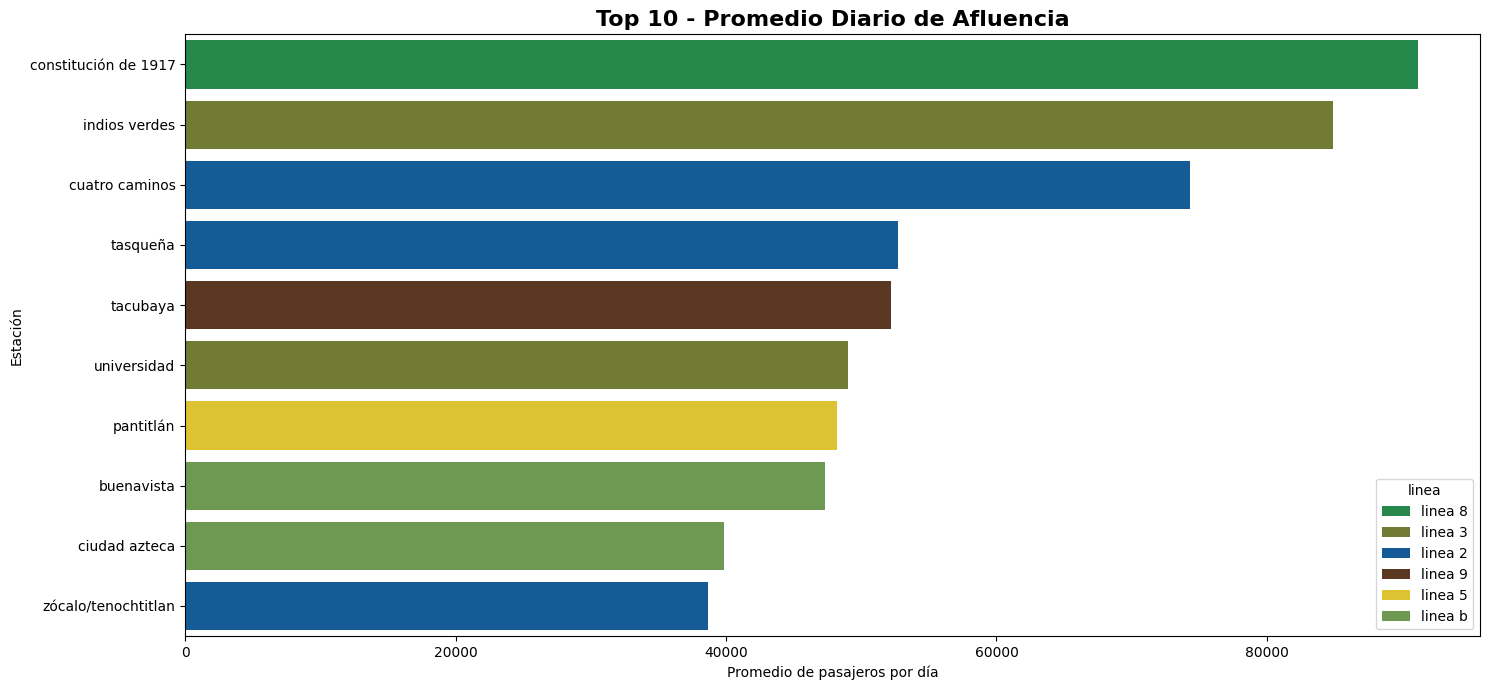

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos para visualización
top10_viz = (
    af_dia_est.groupby(['linea', 'estacion'])
    .agg(
        suma_total=('afluencia', 'sum'),
        promedio_diario=('afluencia', 'mean')
    )
    .round(2)
    .sort_values('promedio_diario', ascending=False)
    .head(10)
    .reset_index()
)

# Crear gráfico
fig, ax = plt.subplots(figsize=(15, 7))

sns.barplot(
    data=top10_viz,
    x='promedio_diario',
    y='estacion',
    hue='linea',
    dodge=False,
    palette=colores_linea,
    ax=ax
)

ax.set_title('Top 10 - Promedio Diario de Afluencia', fontsize=16, fontweight='bold')
ax.set_xlabel('Promedio de pasajeros por día')
ax.set_ylabel('Estación')

plt.tight_layout()
plt.show()

La siguiente serie de tiempo muestra la afluencia total por linea del periodo 2022-2026. A partir de la misma pudimos notar lo siguiente:
1. Obras de Infraestructura (Líneas 1 y 12)

    Línea 12 (Naranja): Se observa claramente el periodo de inactividad total en 2022 (línea en cero). A partir de inicios de 2023, se ven "escalones" de subida que corresponden a las reaperturas por tramos.

    Línea 1 (Rosa): se nota la caída drástica a mediados de 2022. Esto marca el inicio del proyecto de mantenimiento. La fluctuación posterior refleja la operación parcial y el desvío de usuarios a otras rutas.

2. Estacionalidad Marcada
    Se observa que el final de cada año (diciembre-enero), todas las líneas presentan una "V" o caída pronunciada.

    Interpretación: Es el efecto de las vacaciones de invierno y la suspensión de actividades escolares/administrativas.

3. Líneas más relevantes (Líneas 2 y 3)
    Las líneas 2 y 3 se mantienen consistentemente en la cima, rozando los 17.5M a 20M de pasajeros mensuales.

4. Líneas Estables (Líneas 4 y 6)
    Las líneas en la parte inferior de la gráfica muestran una estabilidad casi plana.


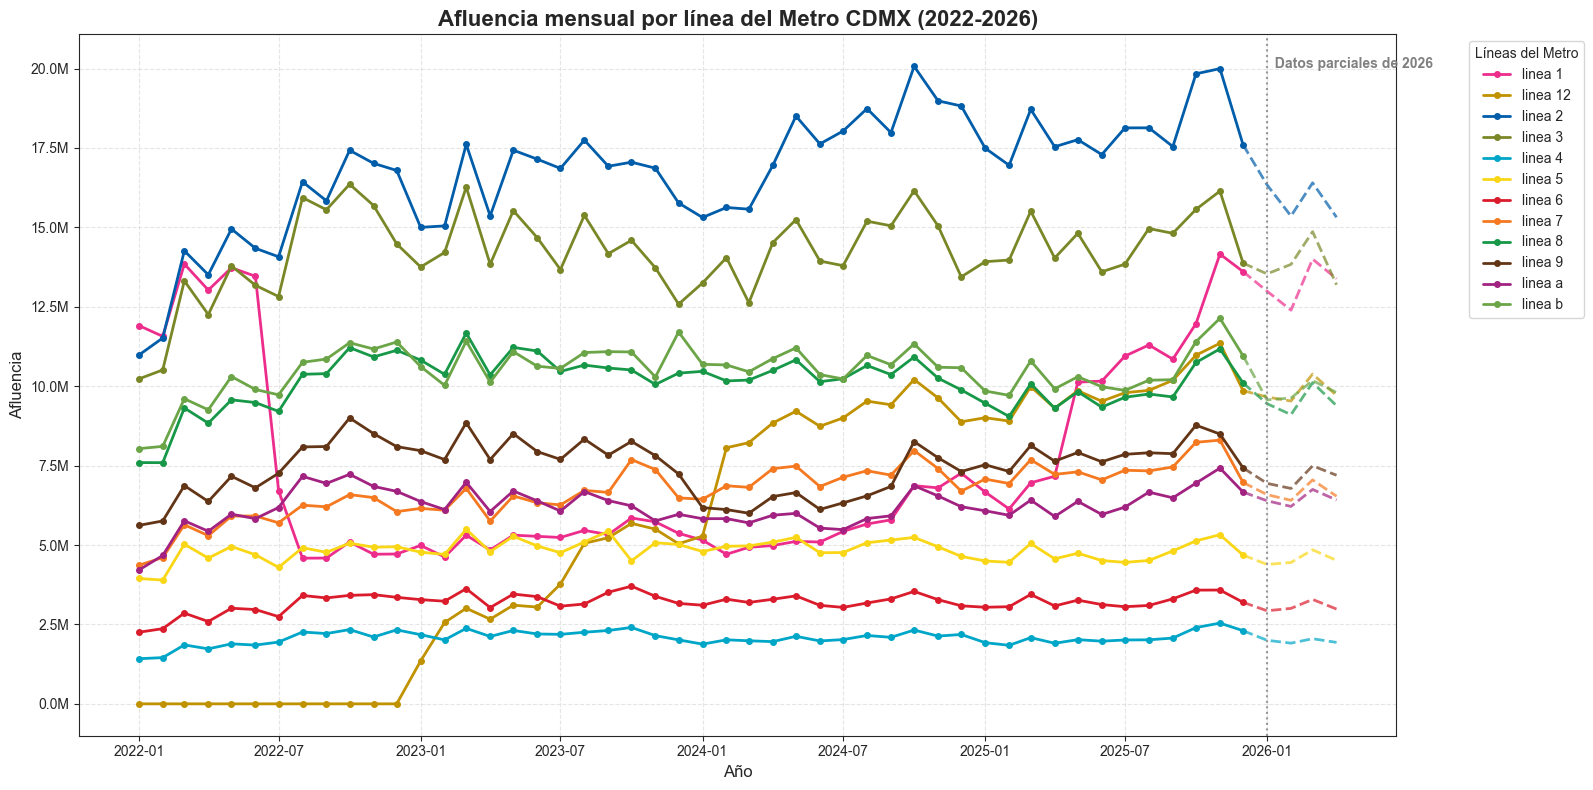

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_monthly = metro.groupby(
    [pd.Grouper(key='fecha', freq='MS'), 'linea']
)['afluencia'].sum().reset_index()

cutoff_date = pd.to_datetime('2026-01-01')

plt.figure(figsize=(16, 8))
sns.set_style("ticks")

lineas = sorted(df_monthly['linea'].unique())

for linea in lineas:
    subset = df_monthly[df_monthly['linea'] == linea]
    historical = subset[subset['fecha'] < cutoff_date]
    current_year = subset[subset['fecha'] >= cutoff_date]

    color = colores_linea.get(linea.lower(), '#CCCCCC')

    plt.plot(
        historical['fecha'],
        historical['afluencia'],
        label=linea,
        color=color,
        linewidth=2,
        marker='o',
        markersize=4
    )

    if not current_year.empty:
        gap_connector = pd.concat([historical.tail(1), current_year])
        plt.plot(
            gap_connector['fecha'],
            gap_connector['afluencia'],
            color=color,
            linestyle='--',
            linewidth=2,
            alpha=0.7
        )

plt.axvline(cutoff_date, color='gray', linestyle=':', alpha=0.8)
plt.text(
    cutoff_date,
    plt.ylim()[1] * 0.95,
    '  Datos parciales de 2026',
    color='gray',
    fontweight='bold'
)

plt.title(
    'Afluencia mensual por línea del Metro CDMX (2022-2026)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Año', fontsize=12)
plt.ylabel('Afluencia', fontsize=12)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M')
)

plt.legend(
    title='Líneas del Metro',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **FEATURE ENGINEERING**

Estadísticas moviles son importantes para comenzar el análisis de series de tiempo ya que nos permiten identificar comportamiento en la serie en ciertas ventanas de tiempo, se tomaron en cuenta la media movil, la desviación estandar movil para cada estación, 

Además se tomaron en cuenta otras medidas como el cambio porcentual ya que nos servirá para la detección de cambios significativos en la series con respecto a una ventana de tiempo, por otro lado se agregó el estadístico z-score con el fin de encontrar puntos que se salen de los valores esperados, para tomar los más alejados se tomo como umbral mayores a 3 desviaciones estándar.

Por lo que al combinar el cambio porcentual mayor al 85% y estadístico z-score > 3 deviaciones estándar estariamos tomando valores muy atípicos para poder clasificarlo como una anomalía en terminos estadísticos, además se tomará en cuenta un modelo que pueda captar no solo el valor alejado si no que tome en cuenta otras variables que podrían estar sesgando los estadísticos, como sería, días feriados o si la estación estuvo cerrada o es fin de semana

In [40]:
agg = af_dia_est.sort_values('fecha').groupby(['linea', 'estacion'])['afluencia'] # solo columna afluencia agrupada por linea y estacion

af_dia_est['media_movil'] = round((agg.rolling(window=60, min_periods=1).mean().reset_index(level=[0,1], drop=True)),2) # reset porque rolling + group by agrega dos columnas al indice
af_dia_est['std_movil'] = round((agg.rolling(window=60, min_periods=1).std().reset_index(level=[0,1], drop=True)),2)
af_dia_est['cambio_%'] = round(100*abs((af_dia_est['afluencia']-af_dia_est['media_movil'])/af_dia_est['media_movil']),2)

af_dia_est['zscore_movil'] = (
    af_dia_est['afluencia'].values - af_dia_est['media_movil'].values
) / af_dia_est['std_movil'].values

af_dia_est['anomalia_z'] = abs(af_dia_est['zscore_movil']) > 3
af_dia_est


/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/1335927417.py:7: RuntimeWarning: invalid value encountered in divide
  af_dia_est['zscore_movil'] = (


,fecha,linea,estacion,afluencia,media_movil,std_movil,cambio_%,zscore_movil,anomalia_z
0,2022-01-01,linea 1,balbuena,2715,2715.00,NaN,0.00,NaN,False
1,2022-01-01,linea 1,balderas,5973,5973.00,NaN,0.00,NaN,False
2,2022-01-01,linea 1,boulevard puerto aéreo,5633,5633.00,NaN,0.00,NaN,False
3,2022-01-01,linea 1,candelaria,17059,17059.00,NaN,0.00,NaN,False
4,2022-01-01,linea 1,chapultepec,11955,11955.00,NaN,0.00,NaN,False
...,...,...,...,...,...,...,...,...,...
308290,2026-04-30,linea b,romero rubio,16158,13356.82,1576.65,20.97,1.776666,False
308291,2026-04-30,linea b,río de los remedios,16848,14541.32,3562.48,15.86,0.647493,False
308292,2026-04-30,linea b,san lázaro,14443,12740.07,2148.42,13.37,0.792643,False
308293,2026-04-30,linea b,tepito,14961,15743.17,3532.62,4.97,-0.221414,False


In [41]:
# Definir los límites fijos
FECHA_INICIO = pd.Timestamp('2023-09-01')
FECHA_FIN = pd.Timestamp('2026-01-01')

In [42]:
af_dia_est=af_dia_est[af_dia_est['fecha']>f'{FECHA_INICIO}']
af_dia_est = af_dia_est.copy()
af_dia_est['fecha'] = pd.to_datetime(af_dia_est['fecha'])
af_dia_est.set_index('fecha', inplace=True)

In [43]:
af_dia_est.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 189540 entries, 2023-09-02 to 2026-04-30
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   linea         189540 non-null  object 
 1   estacion      189540 non-null  object 
 2   afluencia     189540 non-null  int64  
 3   media_movil   189540 non-null  float64
 4   std_movil     189540 non-null  float64
 5   cambio_%      182568 non-null  float64
 6   zscore_movil  182568 non-null  float64
 7   anomalia_z    189540 non-null  bool   
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 11.7+ MB


In [44]:
#af_dia_est.to_excel('metro_2024-2025.xlsx', index= False)

In [45]:
#af_dia_est['media_movil'] = (af_dia_est.sort_values('fecha').groupby(['linea', 'estacion'])['afluencia']
#                             .rolling(window=365, min_periods=1).mean().reset_index(level=[0,1], drop=True))
#af_dia_est

## **GRÁFICA DE FUNCIÓN DE AUTOCORRELACIÓN**

Las siguientes gráficas nos proporcionan información valiosa, ya que nos indican que todas las series no son estacionarias, que modelos AR, MA, ARMA, pueden no capturar el comportamiento por que la series no son estables, tienen estacionalidad, alta volatilidad, por lo que se tendría que hacer un análisis para hacer transformaciones para quitar la estacionalidad y ver si es posible que la serie sea estacionaria

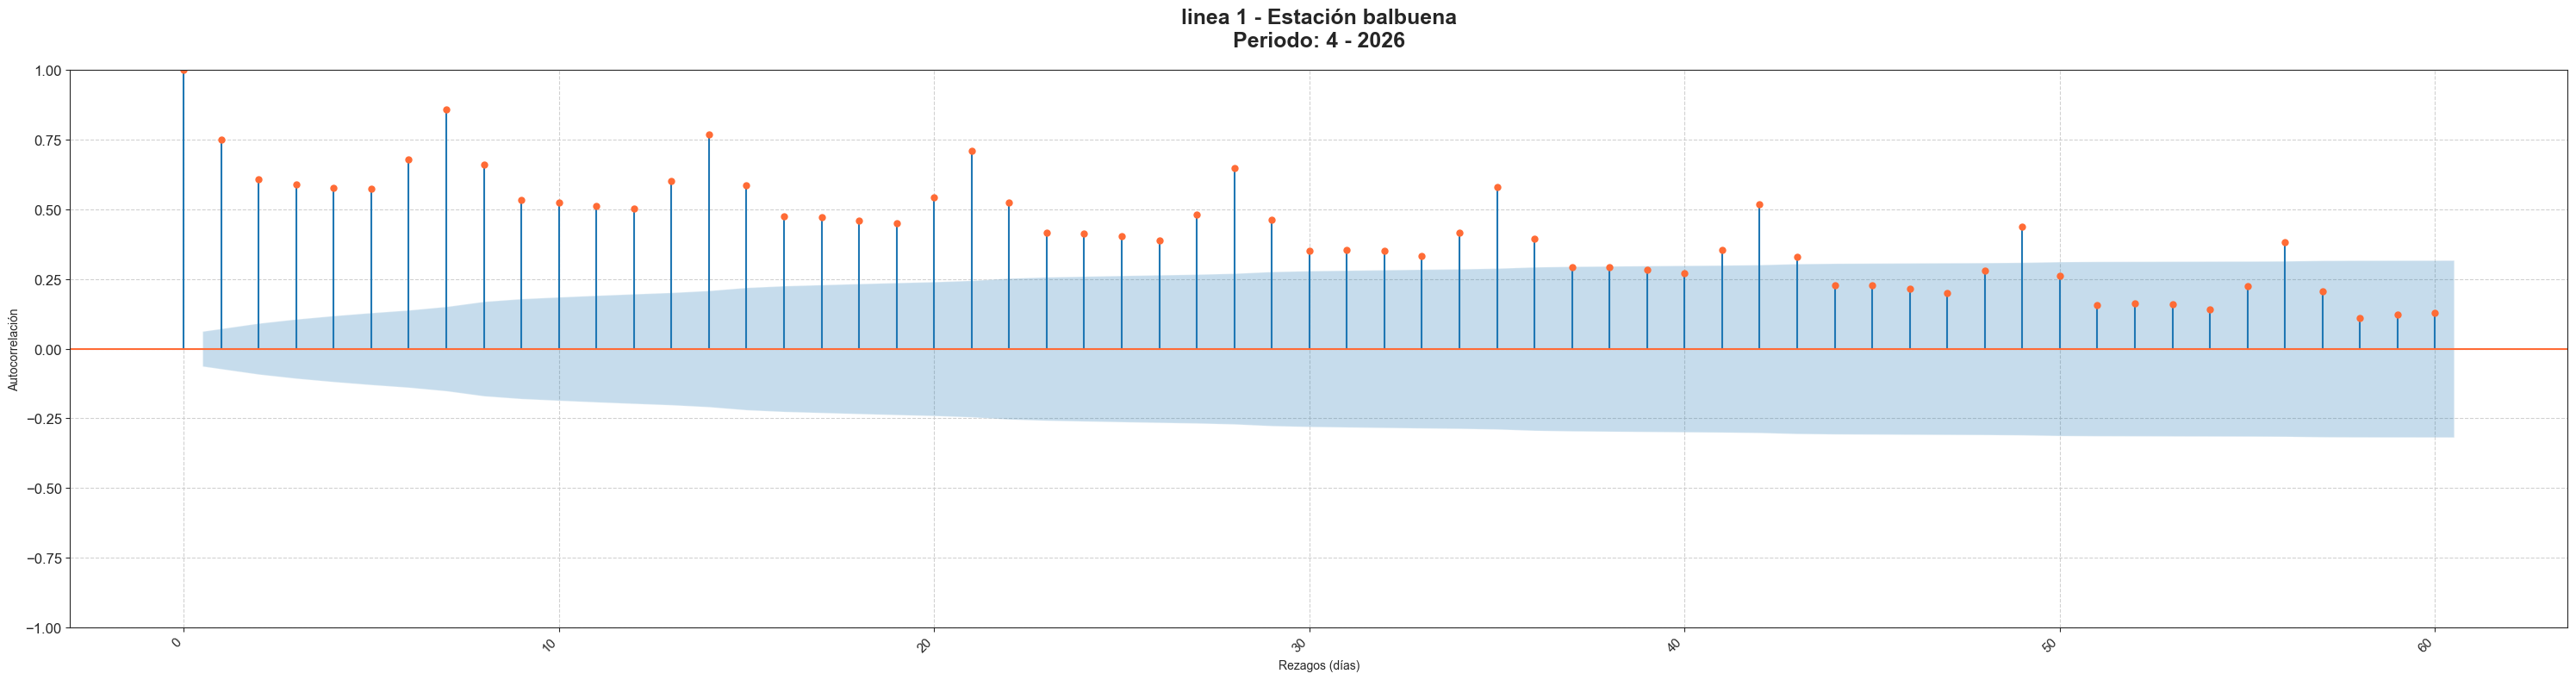

In [46]:
lineas_unicas = af_dia_est['linea'].unique()

for linea in lineas_unicas[:1]:
    datos_linea = af_dia_est[af_dia_est['linea'] == linea]
    estaciones_en_linea = datos_linea['estacion'].unique()
    
    for estacion in estaciones_en_linea[:1]:  
        datos_filtrados = datos_linea[datos_linea['estacion'] == estacion].sort_values('fecha')
        
        fig, ax = plt.subplots(figsize=(30, 8))
        
        sm.graphics.tsa.plot_acf(datos_filtrados['afluencia'].dropna(), lags=60, ax=ax, color = '#ff6b35')
        # lag 365 compara 2025-2024, 730 compara 2025-2023, 1095: 2025-2022

        ax.set_xlabel('Rezagos (días)')
        ax.set_ylabel('Autocorrelación')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        plt.yticks(fontsize=12)
        plt.title(f'{linea} - Estación {estacion}\nPeriodo: {i} - {FECHA_FIN.year}', 
                  fontsize=18, fontweight='bold', pad=20)
        
        ax.grid(True, alpha=0.9, linestyle='--')
        plt.tight_layout()
        plt.show()

# **Función de Autocorrelación Parcial**

Al igual que las otras gráficas de autocorrelación confirman que la series no son estacionarias por lo que aplicar modelos sin diferenciar o transformaciones no podrían modelar los datos.

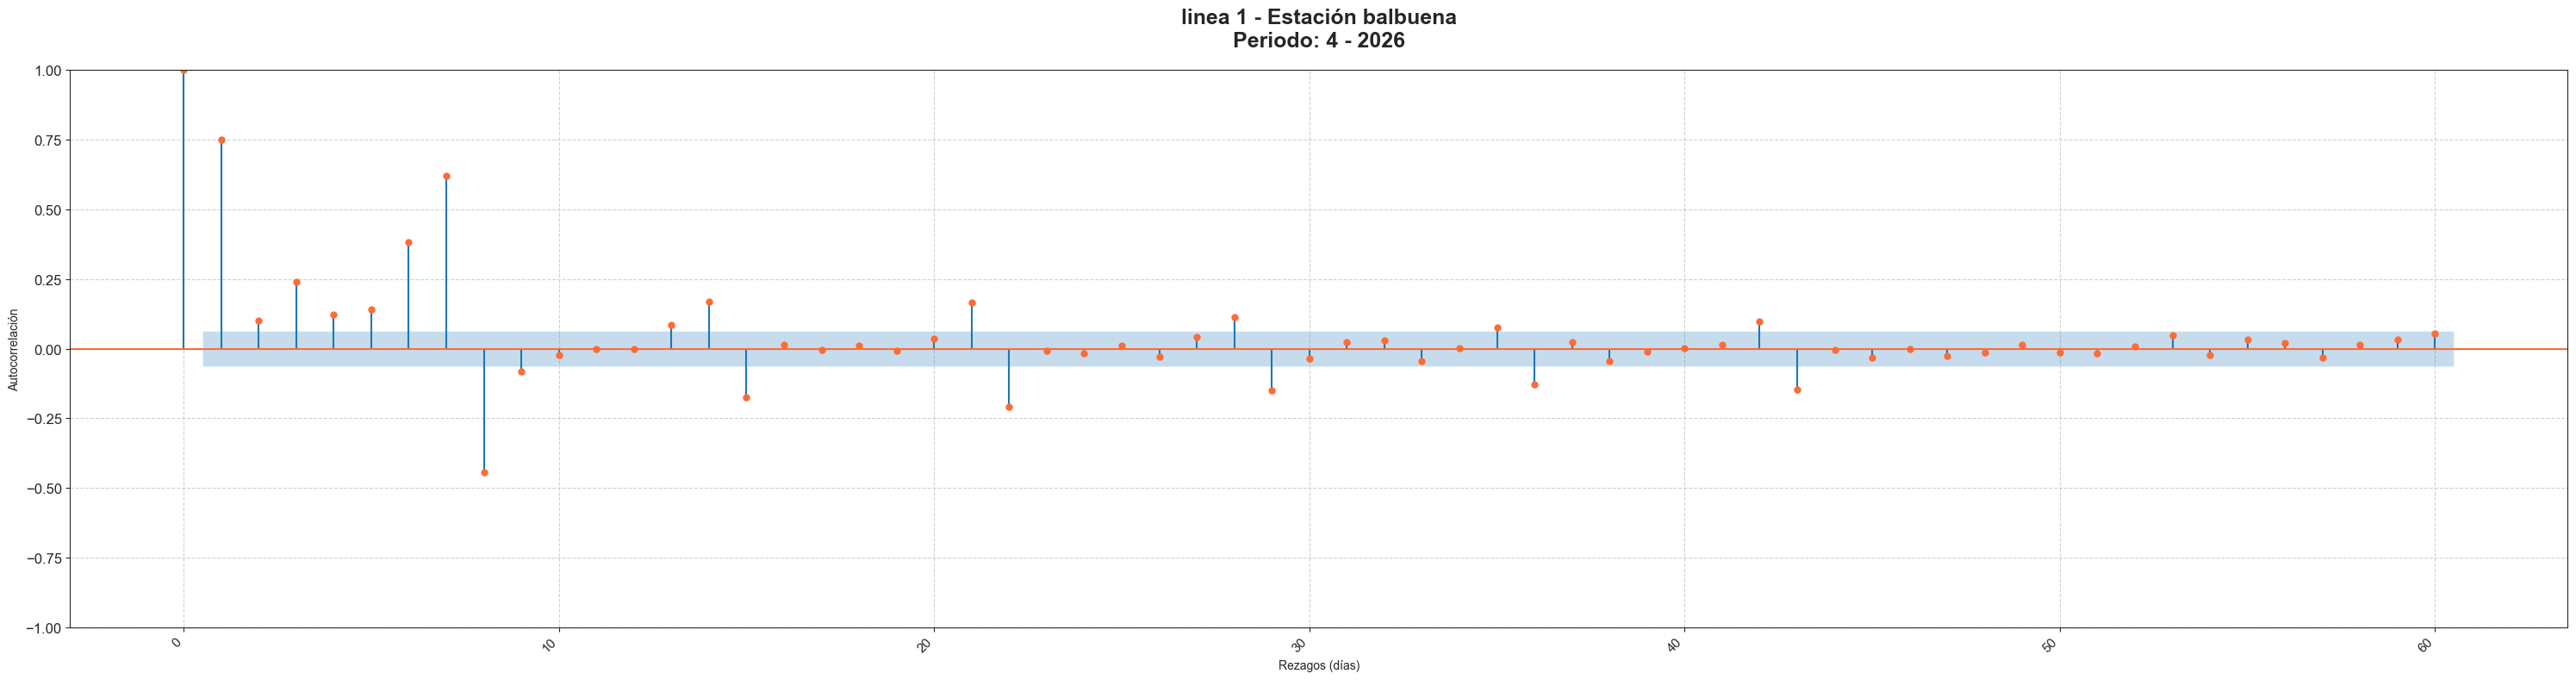

In [47]:
lineas_unicas = af_dia_est['linea'].unique()

for linea in lineas_unicas[:1]:
    datos_linea = af_dia_est[af_dia_est['linea'] == linea]
    estaciones_en_linea = datos_linea['estacion'].unique()
    
    for estacion in estaciones_en_linea[:1]:  
        datos_filtrados = datos_linea[datos_linea['estacion'] == estacion].sort_values('fecha')
        
        fig, ax = plt.subplots(figsize=(30, 8))
        
        sm.graphics.tsa.plot_pacf(datos_filtrados['afluencia'].dropna(), lags=60, ax=ax, color = '#ff6b35', method='ywm')
        # lag 365 compara 2025-2024, 730 compara 2025-2023, 1095: 2025-2022

        ax.set_xlabel('Rezagos (días)')
        ax.set_ylabel('Autocorrelación')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        plt.yticks(fontsize=12)
        plt.title(f'{linea} - Estación {estacion}\nPeriodo: {i} - {FECHA_FIN.year}', 
                  fontsize=18, fontweight='bold', pad=20)
        
        ax.grid(True, alpha=0.9, linestyle='--')
        plt.tight_layout()
        plt.show()

## **VISUALIZACIÓN DE LAS SERIES DE TIEMPO CON ANOMALÍAS**

A continuación se observan las 195 series de tiempo, donde los puntos rojos representan cambios mayores al 85% en la serie y los puntos morados representan valores que se alejan 3 desviaciones estandar

Se obtuvieron los siguientes resultados tras la visualización de las series:


Juanacatlán, tacubaya y observatorio al no tienen suficientes datos.

Toda la linea 1 presenta valores 0 por que estuvo en mantenimiento.

Estaciones de la linea 12 presentan 0.

Linea 9: pantitlan, puebla, ciudad deportiva también presentan 0.

Como se mencionó en la eliminación de variables, se dejo una escala de tiempo apartir de
septiembre de 2023 porque para las lineas 12 y 1 se cortaba por lo que no serviría para el modelado.

**Estaciones con mayor número de valores atípicos:**

Linea 1: candelaria, merced

Linea 2: Allende, bellas artes, pino Suárez, zócalo, hidalgo

Linea 4: canal del norte, candelaria, fray Servando, Morelos, santa Anita

Linea 5: consulado 

Linea 6: la villa

Linea 7: constituyentes 

Linea 8: apatlalco, bellas artes, Iztapalapa, la viga

Linea 9: ciudad deportiva, Jamaica, velódromo, los reyes

Linea b: san lazaro

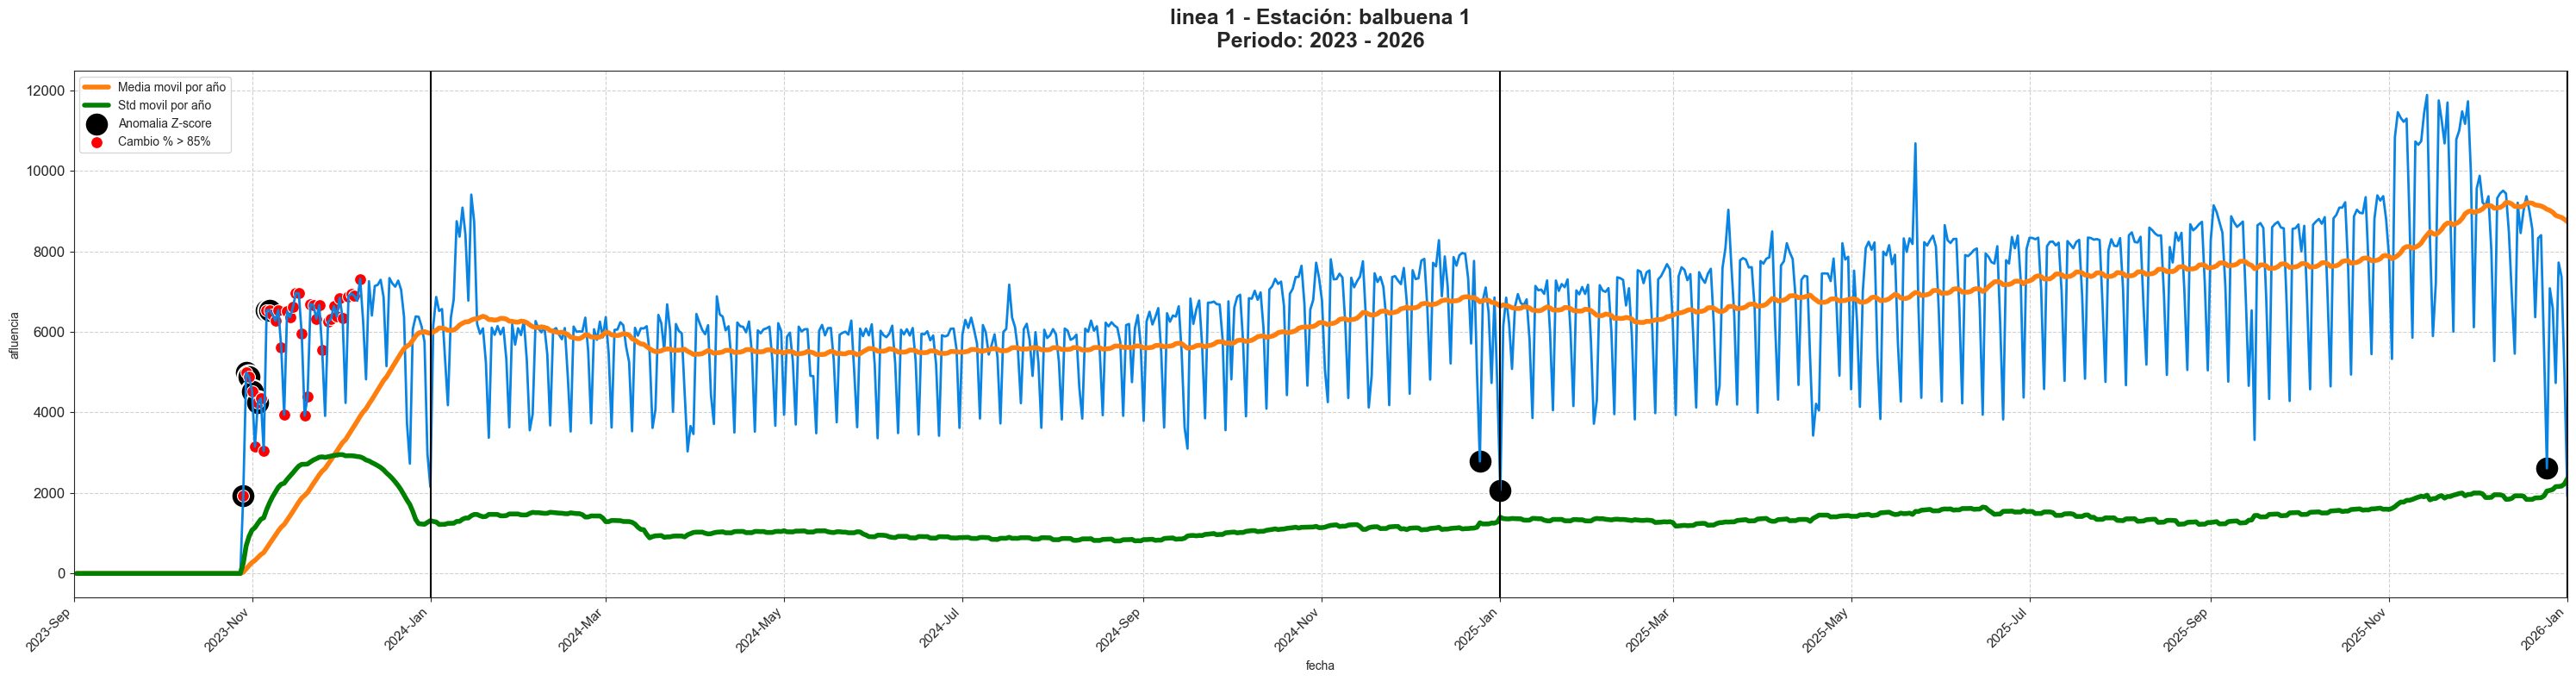

       afluencia  media_movil  std_movil  cambio_%  zscore_movil
count     972.00       972.00     972.00    915.00        915.00
mean     6367.54      6120.98    1336.13     44.17          0.16
std      2309.70      2067.14     542.11    267.93          1.13
min         0.00         0.00       0.00      0.02         -3.27
25%      5447.00      5574.04    1035.87      8.46         -0.30
50%      6576.50      6508.85    1333.36     14.16          0.50
75%      7977.25      7457.50    1593.32     25.16          0.79
max     11884.00      9213.98    2951.80   5900.00          7.62


In [48]:
n = 0
lineas_unicas = af_dia_est['linea'].unique()

for linea in lineas_unicas[:1]:
    datos_linea = af_dia_est[af_dia_est['linea'] == linea]
    estaciones_en_linea = datos_linea['estacion'].unique()
    
    for estacion in estaciones_en_linea[:1]:  # Hasta 14 estaciones por linea
        n = n+1
        datos_filtrados = datos_linea[datos_linea['estacion'] == estacion].sort_index()        
        if len(datos_filtrados) == 0:
            continue
        
        fig, ax = plt.subplots(figsize=(30, 8))
        
        sns.lineplot(data=datos_filtrados,
                     x=datos_filtrados.index,
                     y='afluencia',
                     ax=ax,
                     linewidth=2,
                     color='#0984e3')
        
        sns.lineplot(data=datos_filtrados,
                    x=datos_filtrados.index,
                    y='media_movil',
                    ax=ax,
                    linewidth=4,
                    color='#ff7f0e',
                    label = 'Media movil por año')
        
        sns.lineplot(data=datos_filtrados,
                     x = datos_filtrados.index,
                     y = 'std_movil',
                     ax=ax,
                     linewidth= 4,
                     color = 'green',
                     label = 'Std movil por año')
        
        sns.scatterplot(data=datos_filtrados[datos_filtrados['anomalia_z']],
                x=datos_filtrados[datos_filtrados['anomalia_z']].index,
                y='afluencia',
                color='black',
                label='Anomalia Z-score',
                s=400,
                )
        
        sns.scatterplot(data=datos_filtrados[datos_filtrados['cambio_%'] > 85],
                x=datos_filtrados[datos_filtrados['cambio_%'] > 85].index,
                y='afluencia',
                color='r',
                label='Cambio % > 85%',
                s=100)

        ax.set_xlim(FECHA_INICIO, FECHA_FIN)

        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))

        for year in range(FECHA_INICIO.year, FECHA_FIN.year + 1):
            ax.axvline(pd.Timestamp(f'{year}-01-01'),
                       color='black',
                       linestyle='-',
                       linewidth=1.5)

        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        plt.yticks(fontsize=12)

        plt.title(f'{linea} - Estación: {estacion} {n}\n'
                  f'Periodo: {FECHA_INICIO.year} - {FECHA_FIN.year}',
                  fontsize=18,
                  fontweight='bold',
                  pad=20)

        ax.grid(True, alpha=0.9, linestyle='--')
        plt.tight_layout()
        plt.show()

        print(round(datos_filtrados[datos_filtrados.index > FECHA_INICIO].describe(),2))

# **DATASET FILTRADO PARA CLASIFICACIÓN DE ANOMALÍAS**

In [49]:
af_dia_est['estacion_cerrada'] = (af_dia_est['afluencia'] == 0).astype(int)

In [50]:
af_anom = af_dia_est[(af_dia_est['anomalia_z']==True) & (af_dia_est['cambio_%']>85)]
print(af_anom)

              linea               estacion  afluencia  media_movil  std_movil  \
fecha                                                                           
2023-09-05  linea 5            politécnico      46271     22900.43    6806.37   
2023-09-05  linea b        villa de aragón      22366     11445.80    3448.28   
2023-09-06  linea 5            politécnico      46929     23349.80    7467.35   
2023-09-12  linea 6  deportivo 18 de marzo       2438      1284.45     327.95   
2023-09-14  linea 2                allende      44785     22597.85    5035.78   
...             ...                    ...        ...          ...        ...   
2026-03-08  linea 9              chabacano      17253      8499.23    2367.71   
2026-04-02  linea 9              chabacano      22351     10045.00    2613.63   
2026-04-03  linea 8             iztapalapa      23763     10497.97    2695.54   
2026-04-15  linea 9       ciudad deportiva      11897      5994.58    1959.56   
2026-04-16  linea 9       ci

## **Excel con fechas anomalías estadísticas**

In [51]:
#af_anom.to_excel('anomalias_2023-2026.xlsx', index= True)

# **PREPROCESAMIENTO**

## **DESCOMPOSICIÓN DE LAS SERIES**

+ **Descomposición clásica** *Expresa la serie (y(t)) como una combinación de 3 componentes*

    **Metodos de descomposición**
    * Descomposición aditiva: y(t) = S(t) + T(t) + R(t) -> (Cuando la magitud del componente estacional se mantiene relativamente constantea pesar de la tendencia)
    * Descomposición multiplocativa: y(t) = S(t) * T(t) * R(t) -> (Cuando la magitud del componente estacional cambia proporcionalmente con la tendencia) **Este parece ser el caso de las series de tiempo del metro**

Se puede observar un compportamiento estacional semanal para cada linea, la multiplicativa no puede tener 0 o valores negativos, por el momento se tienen valores 0 en 2023 para la linea 1, asi que si se usa el año 2024 se tiene un **promedio residual** usando la multiplicativa de 0.9 para la mayoría de las lineas, pero en el caso de la aditiva en algunas presenta valores de hasta -30 muy lejanas a 0, por lo que se debe tratar los valores nulos o acortar la serie a 2024 o eliminar estaciones que presenten demasiados 0. Por el momento la **multiplicativa** arroja los mejores resultados.

### **STL**

Se usó la descomposicón con STL porque es un metodo más robusto, porque estima la estacionalidad usando local regression la cual toma en cuenta la periodisidad de la serie, esto es importante porque las series presentan periodisidad, ademas de que puede determinar las variaciones a largo plazo, los residuos los obtiene de tomar la serie original y restarle la periodisidad.

Cada serie parece mostrar distintos patrones de tendencia, estacionalidad y residuales con mucha varianza por lo que no son residuales que presenten homocedasticidad, para eso se saco el promedio de los residuales y no son tan cercanos a 0 por lo que se deben aplicar mas pruebas estadisticas para definir el modelo o decidir si se harán transformaciones o diferenciaciones, pero al ser 195 series resulta complicado evaluar una por una por lo que los resultados nos encaminana a un modelo global si se quiere hacer pronósticos.

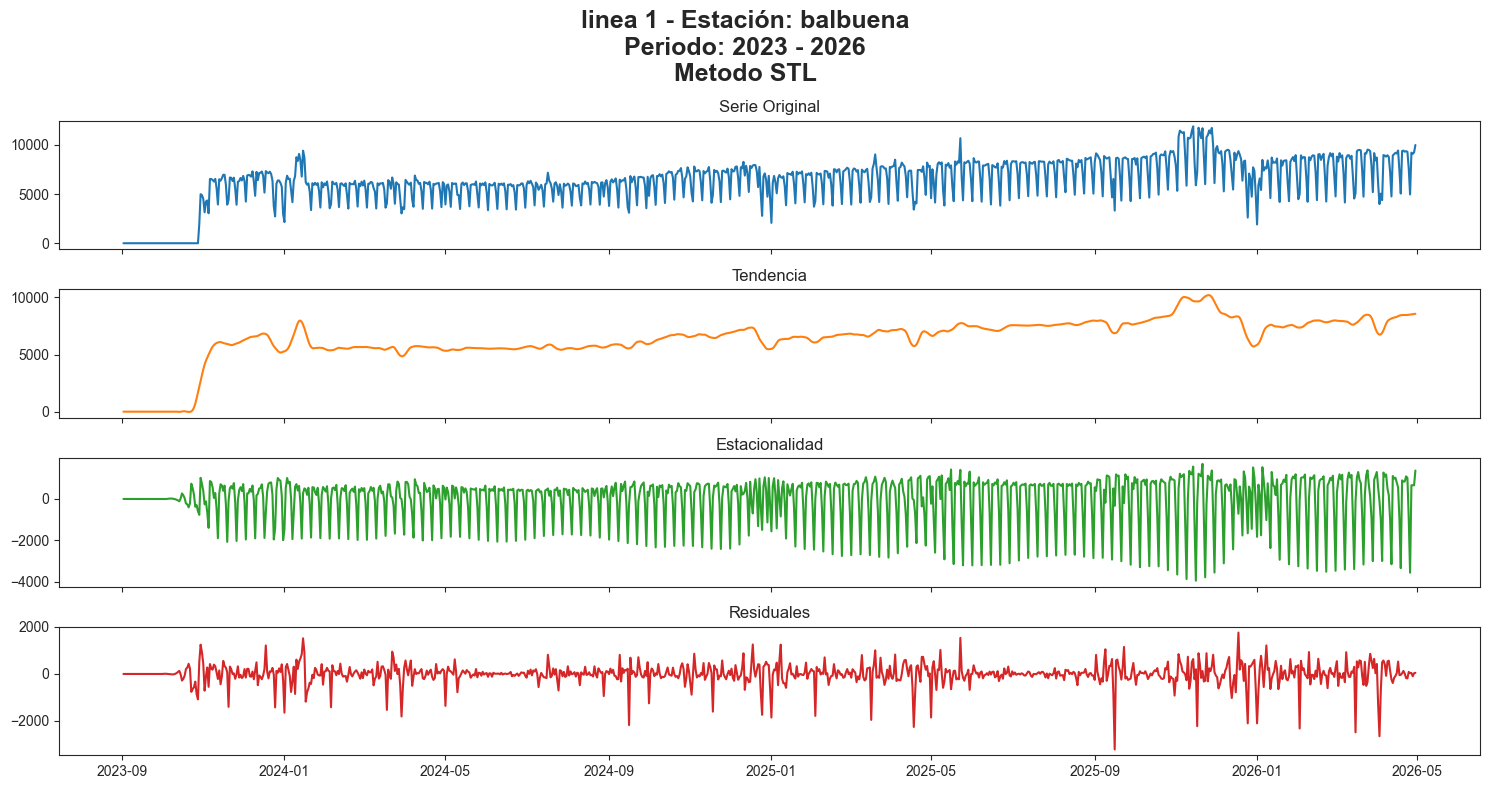

Promedio residuales de descomposición aditiva: -0.07355932161382125


In [52]:
lineas_unicas = af_dia_est['linea'].unique()

for linea in lineas_unicas[:1]:
    datos_linea = af_dia_est[af_dia_est['linea'] == linea]
    estaciones_en_linea = datos_linea['estacion'].unique()
    
    for estacion in estaciones_en_linea[:1]:
        datos_filtrados = (datos_linea[datos_linea['estacion'] == estacion].sort_index())
        
        if datos_filtrados.empty:
            continue
        
        desc_STL = STL(datos_filtrados['afluencia']).fit()
        
        fig, ax = plt.subplots(4,1, figsize=(15,8), sharex=True)

        ax[0].plot(datos_filtrados.index, datos_filtrados['afluencia'], color='#1f77b4')
        ax[0].set_title('Serie Original')

        ax[1].plot(datos_filtrados.index, desc_STL.trend, color='#ff7f0e')
        ax[1].set_title('Tendencia')

        ax[2].plot(datos_filtrados.index, desc_STL.seasonal, color='#2ca02c')
        ax[2].set_title('Estacionalidad')

        ax[3].plot(datos_filtrados.index, desc_STL.resid, color='#d62728')
        ax[3].set_title('Residuales')

        plt.suptitle(f'{linea} - Estación: {estacion}\n'
                     f'Periodo: {FECHA_INICIO.year} - {FECHA_FIN.year}\n'
                     'Metodo STL',
                     fontsize=18,
                     fontweight='bold')

        plt.tight_layout()
        plt.show()

        print(f'Promedio residuales de descomposición aditiva: {desc_STL.resid.mean()}')

Al siguiente dataset se llenara con NaN para hacer las primeras pruebas de modelos, aunque falten pruebas

In [53]:
af_dia_est['afluencia'] = af_dia_est['afluencia'].replace(0, np.nan)

# **PREPROCESAMIENTO PARA MODELO**

In [54]:
faltantes = af_dia_est.groupby(['linea','estacion'])['afluencia'].apply(lambda x: x.isna().sum())

In [55]:
print(faltantes.sort_values(ascending=False))

linea    estacion       
linea 1  juanacatlán        737
         observatorio       737
         tacubaya           732
         chapultepec        530
         cuauhtémoc         530
                           ... 
linea 4  canal del norte      0
         consulado            0
         fray servando        0
         jamaica              0
linea b  villa de aragón      0
Name: afluencia, Length: 195, dtype: int64


In [56]:
min_obs = 500

conteo_validos = af_dia_est.groupby(['linea','estacion'])['afluencia'].count()

estaciones_validas = conteo_validos[conteo_validos >= min_obs].index

In [57]:
af_modelo = af_dia_est.set_index(['linea','estacion'], append=True)

af_modelo = af_modelo.loc[
    af_modelo.index.droplevel(0).isin(estaciones_validas)
]

af_modelo = af_modelo.reset_index(['linea','estacion'])

In [58]:
len(estaciones_validas)

188

In [59]:
af_modelo

,linea,estacion,afluencia,media_movil,std_movil,cambio_%,zscore_movil,anomalia_z,estacion_cerrada
fecha,,,,,,,,,
2023-09-02,linea 1,balbuena,NaN,0.00,0.00,NaN,NaN,False,1
2023-09-02,linea 1,balderas,28807.0,28599.35,6536.50,0.73,0.031768,False,0
2023-09-02,linea 1,boulevard puerto aéreo,NaN,0.00,0.00,NaN,NaN,False,1
2023-09-02,linea 1,candelaria,NaN,0.00,0.00,NaN,NaN,False,1
2023-09-02,linea 1,gómez farias,NaN,0.00,0.00,NaN,NaN,False,1
...,...,...,...,...,...,...,...,...,...
2026-04-30,linea b,romero rubio,16158.0,13356.82,1576.65,20.97,1.776666,False,0
2026-04-30,linea b,río de los remedios,16848.0,14541.32,3562.48,15.86,0.647493,False,0
2026-04-30,linea b,san lázaro,14443.0,12740.07,2148.42,13.37,0.792643,False,0


# **MODELADO**

## Modelos SARIMAX

In [60]:
af_modelo.isna().sum()

linea                  0
estacion               0
afluencia           3586
media_movil            0
std_movil              0
cambio_%            3059
zscore_movil        3059
anomalia_z             0
estacion_cerrada       0
dtype: int64

In [61]:
datos = af_modelo[
    (af_modelo['linea']=='linea 1') &
    (af_modelo['estacion']=='balbuena')
]

serie = datos['afluencia'].dropna().sort_index()  

In [62]:
serie = datos['afluencia'].dropna() 
serie = serie.sort_index()

In [63]:
print(len(serie))

915


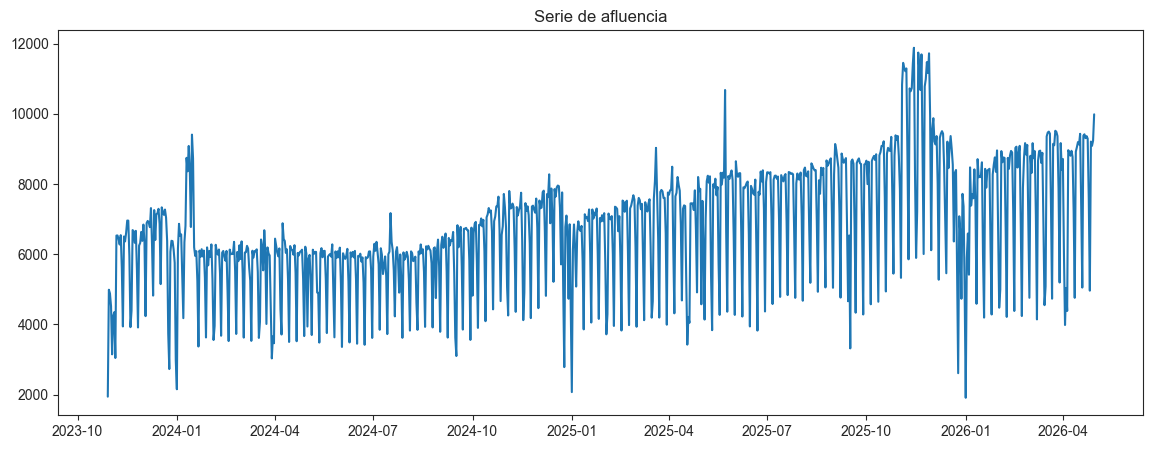

In [64]:
plt.figure(figsize=(14,5))
plt.plot(serie)
plt.title('Serie de afluencia')
plt.show()

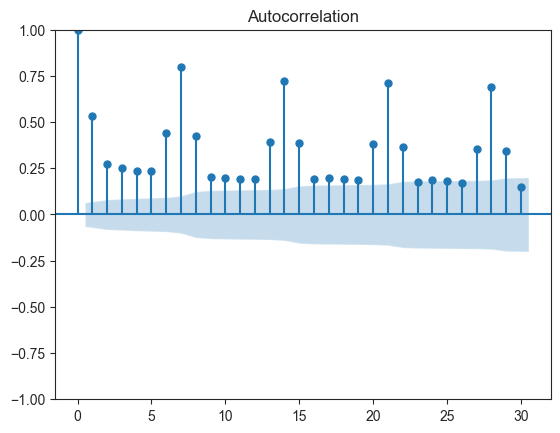

In [65]:
plot_acf(serie, lags=30)
plt.show()

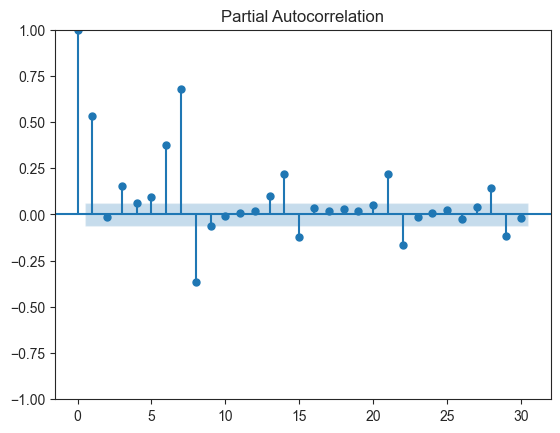

In [66]:
plot_pacf(serie, lags=30)
plt.show()

In [67]:
resultado = adfuller(serie)

print("p-value:", resultado[1])

p-value: 0.377163067763964


In [68]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(
    serie,
    order=(1,1,1),
    seasonal_order=(0,1,1,7)
)

resultado = modelo.fit()

print(resultado.summary())

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         afluencia   No. Observations:                  915
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -7313.209
Date:                           Sat, 16 May 2026   AIC                          14634.418
Time:                                   12:34:27   BIC                          14653.658
Sample:                               10-29-2023   HQIC                         14641.765
                                    - 04-30-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4701      0.024     19.405      0.000       0.423       0.518
ma.L1         -0.9126      0.015    -60.359

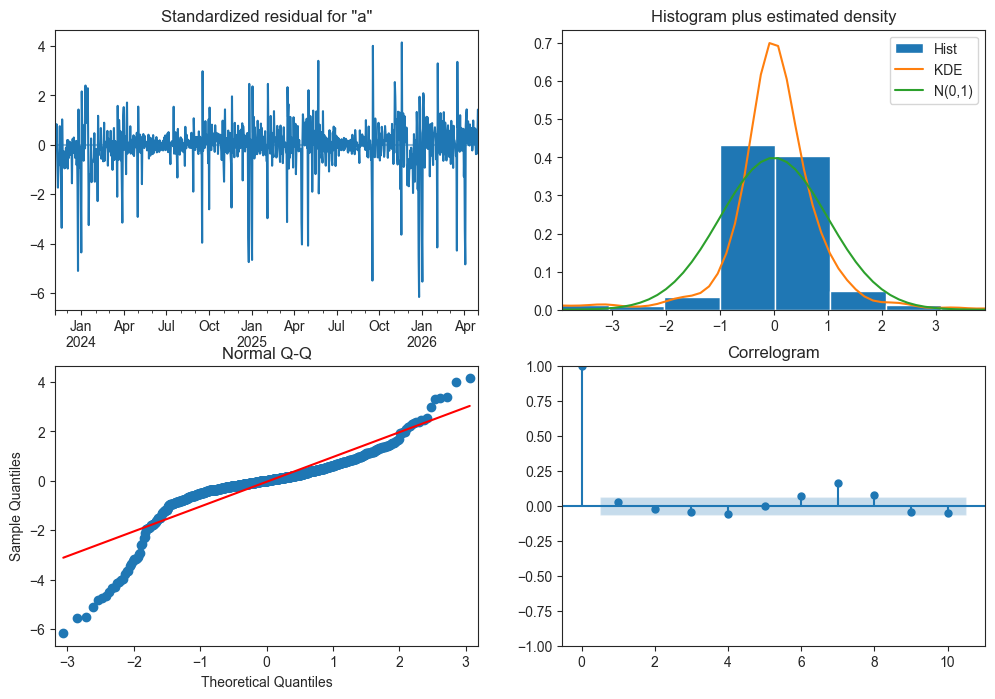

In [69]:
resultado.plot_diagnostics(figsize=(12,8))
plt.show()

In [70]:
modelo_auto = auto_arima(
    serie,
    seasonal=True,
    m=7,                 # estacionalidad semanal
    trace=True,          # muestra las pruebas
    stepwise=True,
    suppress_warnings=True
)

print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.07 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=16153.402, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=15203.931, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=15488.321, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=16151.428, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=16110.696, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=15132.383, Time=0.52 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=15230.230, Time=0.99 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=14924.053, Time=0.75 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=15632.414, Time=0.18 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=15235.830, Time=0.91 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=15475.319, Time=0.39 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=15422.969, Time=1.13 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(2,1,0)(1,0,1)[7] interce

In [71]:
print(modelo_auto.order)
print(modelo_auto.seasonal_order)

(1, 1, 0)
(1, 0, 1, 7)


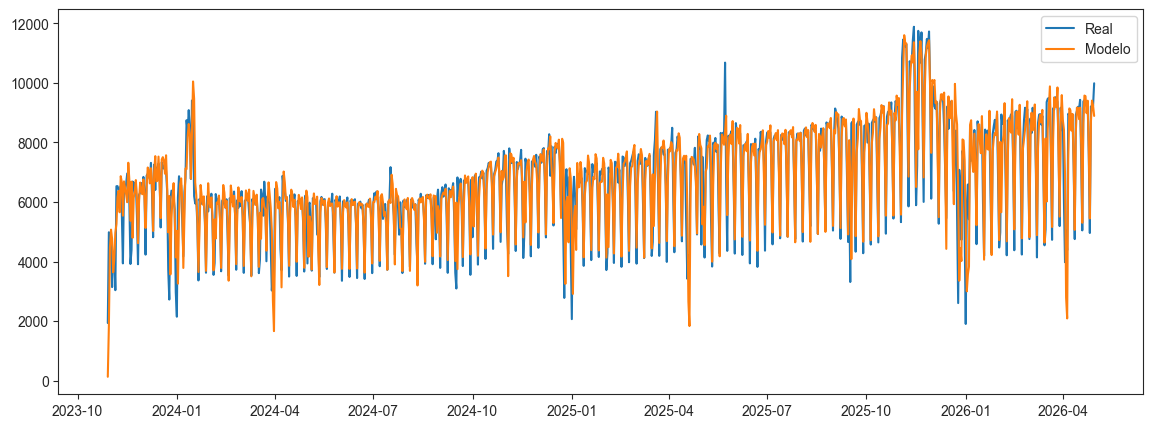

In [72]:
pred = modelo_auto.predict_in_sample()

plt.figure(figsize=(14,5))
plt.plot(serie, label="Real")
plt.plot(pred, label="Modelo")
plt.legend()
plt.show()

In [73]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(serie, pred)
print(mae)

517.047016436494


In [74]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(serie, pred))
print(rmse)

850.3613799081497


In [75]:
residuos = serie - pred
residuos

fecha
2023-10-29    1804.971308
2023-10-30    3160.215462
2023-10-31     409.336289
2023-11-01    -554.721196
2023-11-02   -1615.279442
                 ...     
2026-04-26    -488.302777
2026-04-27     520.298781
2026-04-28    -318.306512
2026-04-29       0.205388
2026-04-30    1095.381012
Length: 915, dtype: float64

Se puede aplicar una diferenciación estacional, además de incluir modelos estacionales AR(P) o MA(Q) 

In [76]:
from pmdarima import auto_arima

resultados = {}

for i, (estacion, grupo) in enumerate(af_modelo.groupby("estacion")):

    if i == 2:
        break

    print("Entrenando:", estacion)

    serie = grupo["afluencia"].dropna()

    modelo = auto_arima(
        serie,
        seasonal=True,
        m=7,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        max_p=2,
        max_q=2,
        max_P=1,
        max_Q=1,
        max_d=1,
        max_D=1
    )

    resultados[estacion] = modelo.order, modelo.seasonal_order

Entrenando: acatitla
Entrenando: aculco


# MODELADO SARIMA VS PROPHET CON DIVISION DE ENTRENAMIENTO Y PRUEBA

In [125]:
af_modelo.isna().sum()
datos = af_modelo[
    (af_modelo['linea']=='linea 2') &
    (af_modelo['estacion']=='cuatro caminos')
]

serie = datos['afluencia'].dropna().sort_index() 

serie = datos['afluencia'].dropna() 
serie = serie.sort_index()

In [126]:
print(len(serie))

972


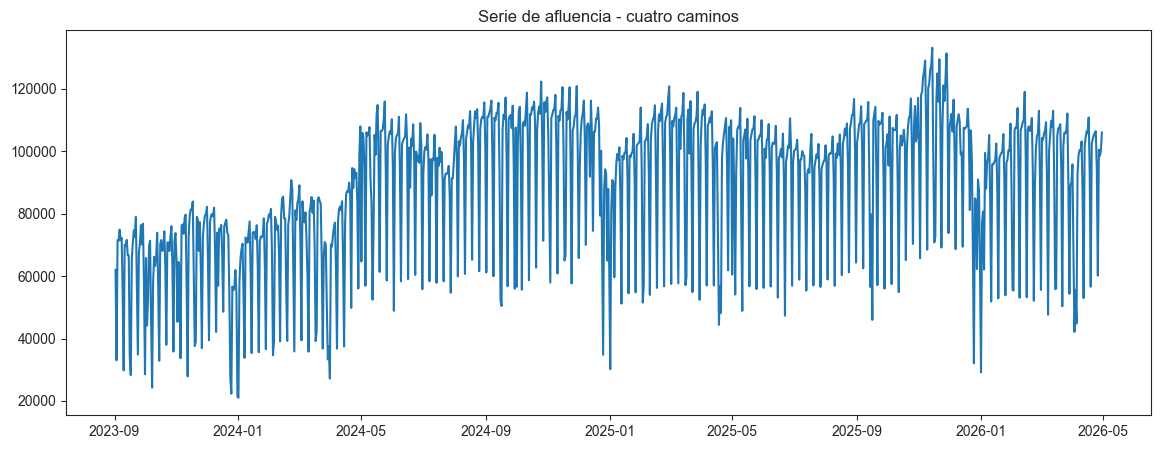

In [127]:
plt.figure(figsize=(14,5))
plt.plot(serie)
plt.title('Serie de afluencia - cuatro caminos')
plt.show()

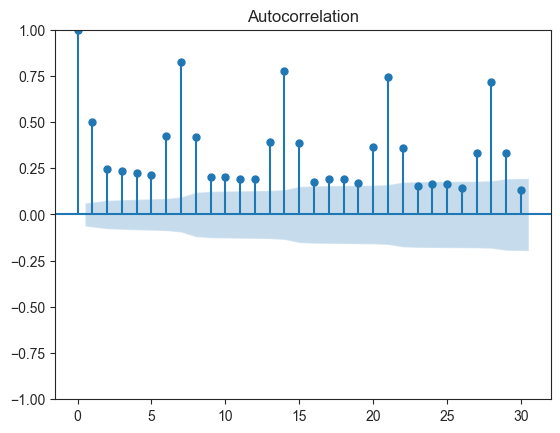

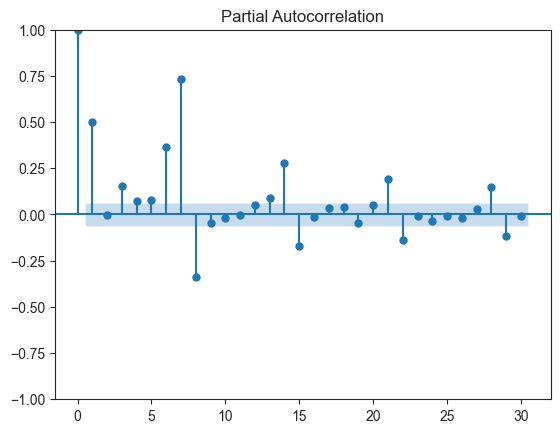

In [128]:
plot_acf(serie, lags=30)
plot_pacf(serie, lags=30)

plt.show()

Número máximo de rezagos (regla de Schwert): 21

--- ADF Con constante y tendencia ---
  Estadístico ADF    : -2.7452
  p-valor            : 0.2178
  Rezagos usados     : 21
  Valores críticos   : 1%: -3.968  5%: -3.415  10%: -3.130
  Conclusión (5%)    : No se rechaza H0: posible raíz unitaria


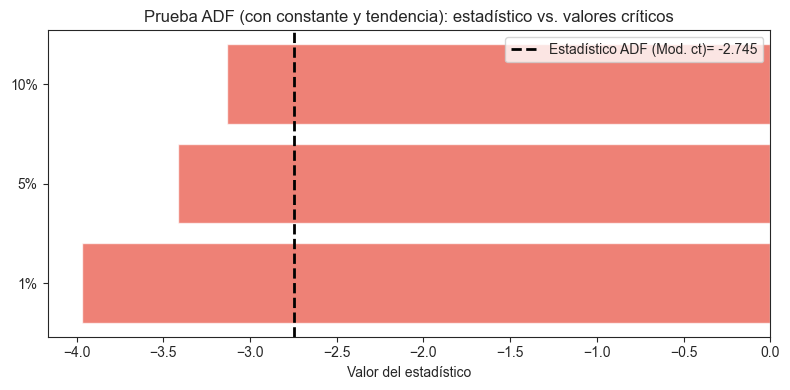

In [129]:
n_obs = len(serie)
p_max = int(12*(n_obs/100)**0.25) # regla de Schwert
print(f"Número máximo de rezagos (regla de Schwert): {p_max}")

adf_ct = adfuller(serie, maxlag=p_max, autolag='aic', regression='ct')

for label, res in [("Con constante y tendencia",adf_ct)]:
    print(f"\n--- ADF {label} ---")
    print(f"  Estadístico ADF    : {res[0]:.4f}")
    print(f"  p-valor            : {res[1]:.4f}")
    print(f"  Rezagos usados     : {res[2]}")
    print(f"  Valores críticos   : " +
          "  ".join([f"{k}: {v:.3f}" for k, v in res[4].items()]))
    concl = "Se rechaza H0: serie estacionaria" if res[1] < 0.05 else "No se rechaza H0: posible raíz unitaria"
    print(f"  Conclusión (5%)    : {concl}")

# Gráfico: estadístico vs valores críticos
fig, ax = plt.subplots(figsize=(8, 4))
criticos = adf_ct[4]
niveles  = list(criticos.keys())
valores  = list(criticos.values())
colores  = ['#2ecc71' if adf_ct[0] < v else '#e74c3c' for v in valores]
ax.barh(niveles, valores, color=colores, alpha=0.7)
ax.axvline(adf_ct[0], color='black', linewidth=2, linestyle='--',
           label=f'Estadístico ADF (Mod. ct)= {adf_ct[0]:.3f}')
ax.set_xlabel('Valor del estadístico')
ax.set_title('Prueba ADF (con constante y tendencia): estadístico vs. valores críticos')
ax.legend()
plt.tight_layout()
plt.show()

La prueba Dickey-Fuller aumentada con constante y tendencia arrojó un estadístico de -2.6045 y un p-valor de 0.2778. Dado que el p-valor es superior a 0.05 y el estadístico no supera el valor crítico al 5% (-3.415), no se rechaza la hipótesis nula de raíz unitaria. En consecuencia, se concluye que la serie no es estacionaria en niveles.

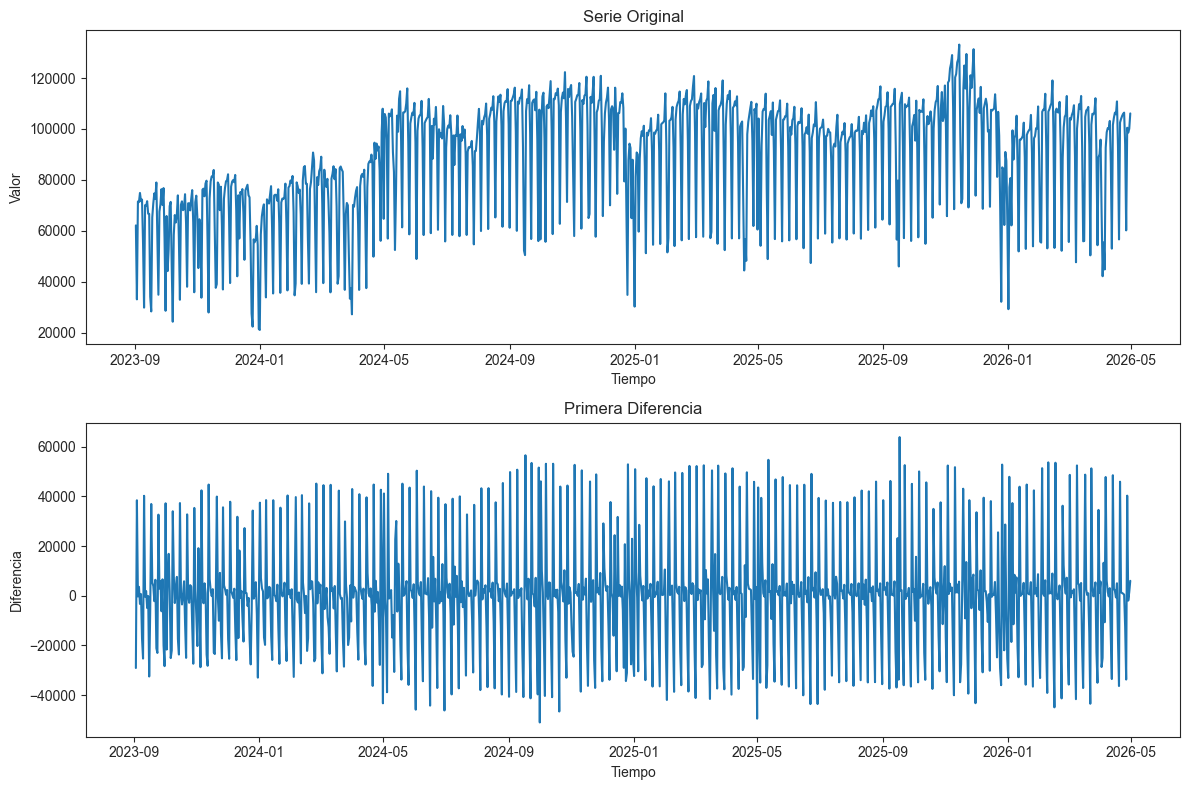

In [131]:
# 1. Primera diferencia
serie_diff = serie.diff().dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Serie original
axes[0].plot(serie)
axes[0].set_title('Serie Original')
axes[0].set_xlabel('Tiempo')
axes[0].set_ylabel('Valor')

# Serie diferenciada
axes[1].plot(serie_diff)
axes[1].set_title('Primera Diferencia')
axes[1].set_xlabel('Tiempo')
axes[1].set_ylabel('Diferencia')

plt.tight_layout()
plt.show()

Número máximo de rezagos (Schwert): 21

--- ADF: Primera Diferencia ---
Estadístico ADF  : -9.5109
p-valor          : 0.0000
Rezagos usados   : 20
Valores críticos : 1%: -2.5681 | 5%: -1.9413 | 10%: -1.6165
Conclusión       : La serie es estacionaria.


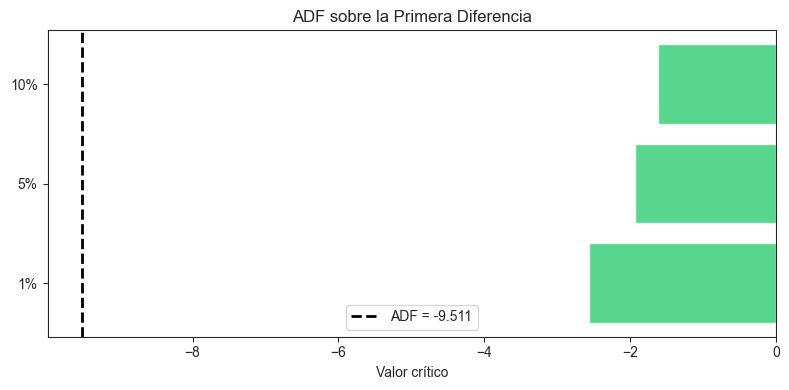

In [132]:
n_obs = len(serie_diff)
p_max = int(12 * (n_obs / 100) ** 0.25)

print(f"Número máximo de rezagos (Schwert): {p_max}")

adf_diff = adfuller(
    serie_diff,
    maxlag=p_max,
    autolag='AIC',
    regression='n'
)

print("\n--- ADF: Primera Diferencia ---")
print(f"Estadístico ADF  : {adf_diff[0]:.4f}")
print(f"p-valor          : {adf_diff[1]:.4f}")
print(f"Rezagos usados   : {adf_diff[2]}")
print(
    "Valores críticos : " +
    " | ".join(
        [f"{k}: {v:.4f}" for k, v in adf_diff[4].items()]
    )
)

if adf_diff[1] < 0.05:
    print("Conclusión       : La serie es estacionaria.")
else:
    print("Conclusión       : La serie aún no es estacionaria.")

fig, ax = plt.subplots(figsize=(8, 4))

criticos = adf_diff[4]
niveles = list(criticos.keys())
valores = list(criticos.values())

colores = [
    '#2ecc71' if adf_diff[0] < v else '#e74c3c'
    for v in valores
]

ax.barh(niveles, valores, color=colores, alpha=0.8)
ax.axvline(
    adf_diff[0],
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'ADF = {adf_diff[0]:.3f}'
)

ax.set_xlabel('Valor crítico')
ax.set_title('ADF sobre la Primera Diferencia')
ax.legend()

plt.tight_layout()
plt.show()

se determina que el orden de diferenciación no estacional es:

d=1

Este es uno de los parámetros clave del modelo SARIMAX:

p: orden autorregresivo
d: diferenciación
q: media móvil

Y, si hay estacionalidad:

P, D, Q, s

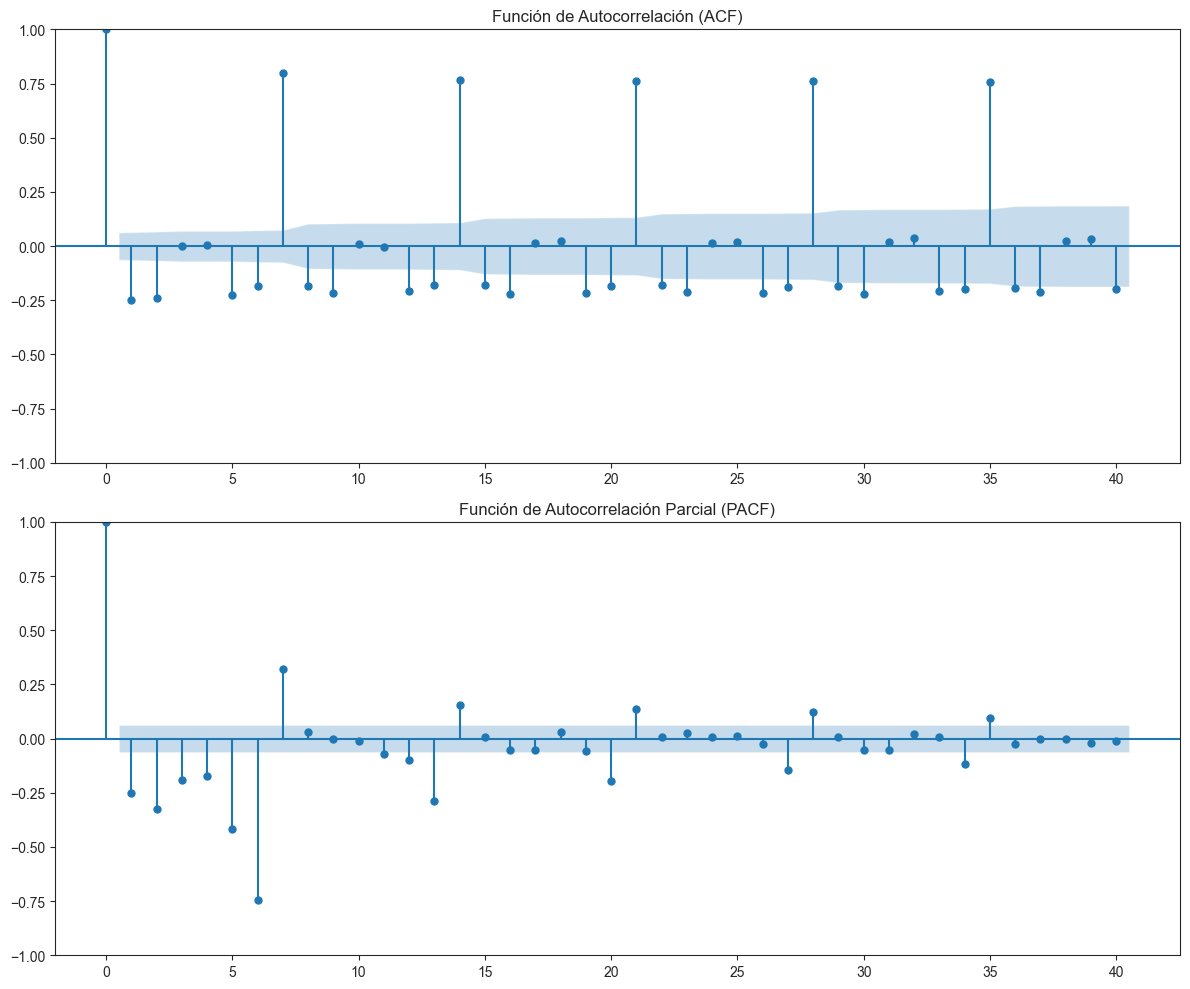

In [133]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

plot_acf(
    serie_diff,
    lags=40,
    ax=axes[0]
)
axes[0].set_title('Función de Autocorrelación (ACF)')

plot_pacf(
    serie_diff,
    lags=40,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

En los primeros rezagos:

La ACF muestra un pico negativo en lag 1.
La PACF también presenta un pico significativo en lag 1.

Esto sugiere que debes probar modelos pequeños, como:

AR(1)
MA(1)
ARMA(1,1)
Componente estacional

Los picos en múltiplos de 7 son muy notorios:

La ACF sugiere un componente MA estacional.
La PACF muestra también cierta persistencia estacional.

Un excelente punto de partida es:

P = 1
Q = 1
Modelo inicial recomendado

SARIMA(1,1,1)×(1,0,1)
7
	​


Este suele funcionar muy bien con patrones semanales.

In [134]:
# ============================================
# AutoARIMA para selección automática
# ============================================

from pmdarima import auto_arima

modelo_auto = auto_arima(
    serie,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=1,                  # Ya determinado con ADF
    seasonal=True,
    m=7,                  # Estacionalidad semanal
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    D=None,               # Determinar automáticamente
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print(modelo_auto.summary())
print(f"\nMejor modelo encontrado: {modelo_auto.order} x {modelo_auto.seasonal_order}")
print(f"AIC: {modelo_auto.aic():.2f}")
print(f"BIC: {modelo_auto.bic():.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=22259.229, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=21575.418, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=21592.045, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22257.233, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=22197.653, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=21536.193, Time=0.18 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=21455.316, Time=0.91 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=21329.559, Time=0.63 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=21812.001, Time=0.07 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=21351.136, Time=0.94 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=21704.512, Time=0.13 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=21467.374, Time=1.20 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=21425.071, Time=0.65 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=21394.463, Time=0.22 sec
 ARIMA(1,1,1)(1,0,1

In [135]:
# División 80-20
train_size = int(len(serie) * 0.85)

train = serie[:train_size]
test = serie[train_size:]

print(f"Train: {len(train)}")
print(f"Test: {len(test)}")

Train: 826
Test: 146


    train_log,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),   # <- D=1 para estacionalidad semanal
    enforce_stationarity=False,
    enforce_invertibility=False

In [177]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(
    train,
    order=(1,1,0),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarimax = modelo_sarimax.fit(disp=False)

pred_sarimax = resultado_sarimax.forecast(steps=len(test))

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



In [178]:
# Pronóstico para el horizonte del conjunto de prueba
forecast = resultado_sarimax.get_forecast(steps=len(test))

predicciones = forecast.predicted_mean
intervalos = forecast.conf_int()

In [179]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

mae = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 19,256.52
RMSE: 23,076.33
MAPE: 23.85%


## PROPHET

In [160]:
# Prophet necesita formato ds/y
df_prophet = pd.DataFrame({
    'ds': serie.index,
    'y': serie.values
})

# División temporal idéntica
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

# Entrena
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.03
)
modelo_prophet.add_country_holidays(country_name='MX')

modelo_prophet.fit(train_prophet)

# Predecir SOLO test
future = test_prophet[['ds']]

forecast = modelo_prophet.predict(future)

pred_prophet = forecast['yhat'].values

13:16:40 - cmdstanpy - INFO - Chain [1] start processing
13:16:40 - cmdstanpy - INFO - Chain [1] done processing


In [186]:
def metricas_series_tiempo(y_real, y_pred):
    # MAE
    # Error absoluto promedio
    mae = mean_absolute_error(y_real, y_pred)

    # MSE
    # Error cuadrático medio
    mse = mean_squared_error(y_real, y_pred)

    # RMSE
    # Penaliza errores grandes
    rmse = np.sqrt(mse)

    # MAPE
    # Error porcentual medio
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    # SMAPE
    # Más estable que MAPE
    smape = np.mean(2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred))) * 100

    medae = median_absolute_error(y_real, y_pred)

    # R cuadrada
    r2 = r2_score(y_real, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "SMAPE": smape,
        "R2": r2,
        "MedAE": medae
        }

metricas_sarimax = metricas_series_tiempo(test, pred_sarimax)
metricas_prophet = metricas_series_tiempo(test, pred_prophet)

print("\n========== SARIMAX ==========\n")

for k, v in metricas_sarimax.items():
    if k in ["MAPE", "SMAPE"]:
        print(f"{k:<10}: {v:.2f}%")
    else:
        print(f"{k:<10}: {v:.2f}")



print("\n========== PROPHET ==========\n")

for k, v in metricas_prophet.items():
    if k in ["MAPE", "SMAPE"]:
        print(f"{k:<10}: {v:.2f}%")
    else:
        print(f"{k:<10}: {v:.2f}")


========== SARIMAX ==========

MAE       : 19256.52
MSE       : 532516821.42
RMSE      : 23076.33
MAPE      : 23.85%
SMAPE     : 24.56%
R2        : -0.29
MedAE     : 18475.88

========== PROPHET ==========

MAE       : 5468.94
MSE       : 87235951.79
RMSE      : 9340.02
MAPE      : 7.74%
SMAPE     : 6.89%
R2        : 0.79
MedAE     : 3374.76


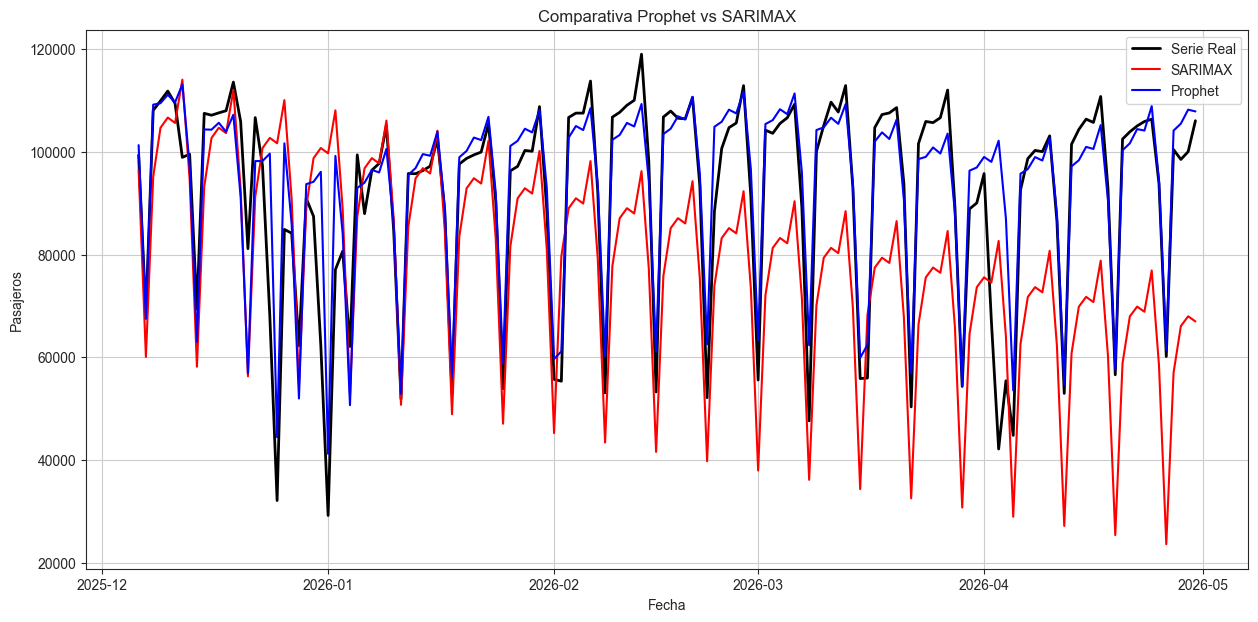

In [180]:
plt.figure(figsize=(15,7))

plt.plot(test.index,
    test.values,
    label='Serie Real',
    color='black',
    linewidth=2)

plt.plot(test.index,
    pred_sarimax,
    label='SARIMAX',
    color='red')

plt.plot(test.index,
    pred_prophet,
    label='Prophet',
    color='blue')

plt.title('Comparativa Prophet vs SARIMAX')
plt.ylabel('Pasajeros')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True)
plt.show()

# **Detección de anomalías**

In [167]:
# Guardar predicciones dentro de test_prophet
test_prophet['yhat'] = forecast['yhat'].values

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/394839645.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3201787290.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3201787290.py:41: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



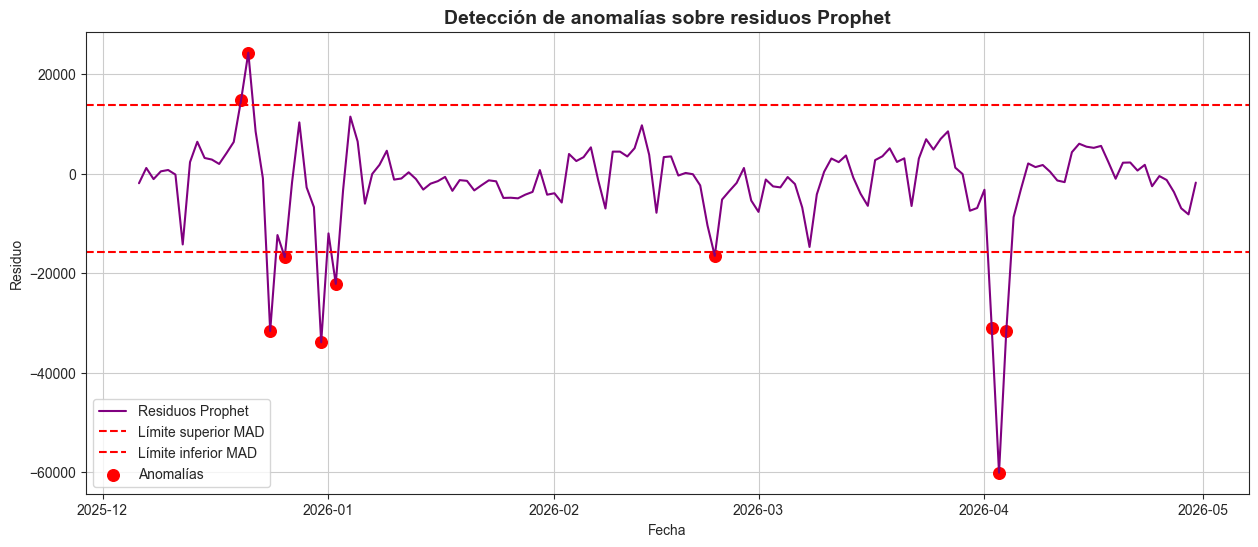

Total anomalías detectadas: 10


In [181]:
# RESIDUOS DE PROPHET

test_prophet['residuo'] = (test_prophet['y'] - test_prophet['yhat'])

# MAD ROBUSTO SOBRE RESIDUOS
mediana_residuos = np.median(test_prophet['residuo'])

mad_residuos = np.median(np.abs(test_prophet['residuo'] - mediana_residuos))

sigma_residuos = mad_residuos * 1.4826
factor_prophet = 3

limite_superior = (mediana_residuos + factor_prophet * sigma_residuos)

limite_inferior = (mediana_residuos - factor_prophet * sigma_residuos)

# DETECCIÓN DE ANOMALÍAS

test_prophet['anomalia'] = ((test_prophet['residuo'] > limite_superior) | (test_prophet['residuo'] < limite_inferior))

# GRÁFICA RESIDUOS + MAD
plt.figure(figsize=(15,6))

plt.plot(test_prophet['ds'],
    test_prophet['residuo'],
    label='Residuos Prophet',
    color='purple')

plt.axhline(limite_superior,
    color='red',
    linestyle='--',
    label='Límite superior MAD')

plt.axhline(limite_inferior,
    color='red',
    linestyle='--',
    label='Límite inferior MAD')

plt.scatter(test_prophet.loc[test_prophet['anomalia'], 'ds'],
    test_prophet.loc[test_prophet['anomalia'], 'residuo'],
    color='red',
    s=70,
    label='Anomalías')

plt.title('Detección de anomalías sobre residuos Prophet', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.legend()
plt.grid(True)
plt.show()


print(f"Total anomalías detectadas: {test_prophet['anomalia'].sum()}")

La idea sería:

Prophet modela: tendencia, estacionalidad semanal,patrones temporales.
Luego analizas los residuos:

residuo=yreal −ypredicho
	​

Sobre esos residuos aplicas MAD robusto.

Eso es muchísimo mejor que aplicar MAD directamente sobre la serie original, porque la serie del metro no es estacionaria:

tiene tendencia, días de semana vs domingo,
variaciones normales del sistema. Entonces, si aplicas MAD directamente a la serie:

muchos domingos parecen “anómalos” aunque son normales, cambios estacionales normales generan falsos positivos.

En cambio, sobre residuos:

Prophet ya explica el comportamiento esperado y MAD detecta únicamente desviaciones inesperadas.

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3857378410.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3857378410.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3857378410.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

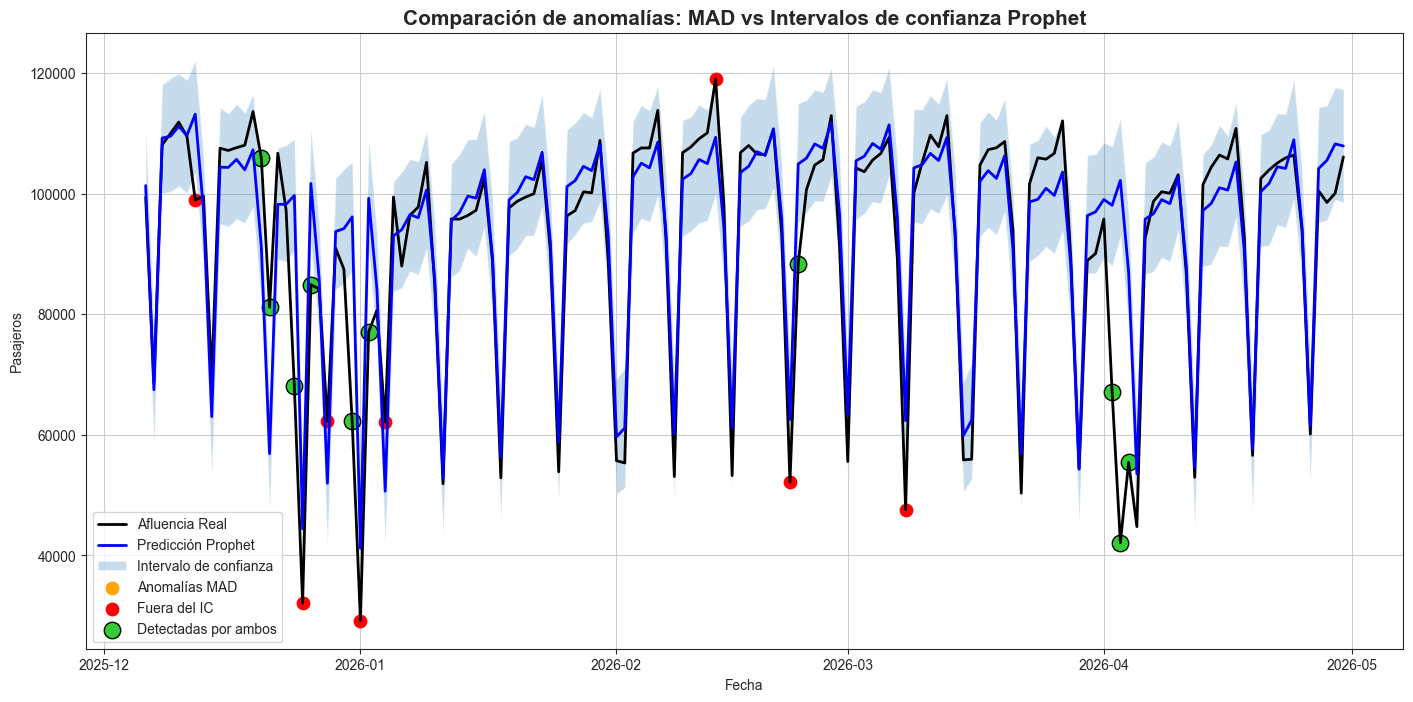


--- RESUMEN DE DETECCIÓN ---

Anomalías MAD: 10
Anomalías IC Prophet: 18
Coincidencias entre ambos: 10


In [182]:
# ANOMALÍAS POR MAD EN RESIDUOS

test_prophet['anomalia_mad'] = (
    (test_prophet['residuo'] > limite_superior) |
    (test_prophet['residuo'] < limite_inferior))

test_prophet['anomalia_ic'] = (
    (test_prophet['y'] < test_prophet['yhat_lower']) |
    (test_prophet['y'] > test_prophet['yhat_upper']))

test_prophet['anomalia_ambos'] = (
    test_prophet['anomalia_mad'] &
    test_prophet['anomalia_ic'])

plt.figure(figsize=(17,8))
# Serie real
plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Afluencia Real',
    color='black',
    linewidth=2
)

# Predicción Prophet
plt.plot(
    test_prophet['ds'],
    test_prophet['yhat'],
    label='Predicción Prophet',
    color='blue',
    linewidth=2
)

plt.fill_between(
    test_prophet['ds'],
    test_prophet['yhat_lower'],
    test_prophet['yhat_upper'],
    alpha=0.25,
    label='Intervalo de confianza'
)

plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_mad'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_mad'],
        'y'
    ],
    color='orange',
    s=80,
    label='Anomalías MAD'
)


plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_ic'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_ic'],
        'y'
    ],
    color='red',
    s=80,
    label='Fuera del IC'
)


plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_ambos'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_ambos'],
        'y'
    ],
    color='limegreen',
    edgecolors='black',
    s=140,
    label='Detectadas por ambos'
)

plt.title(
    'Comparación de anomalías: MAD vs Intervalos de confianza Prophet',
    fontsize=15,
    fontweight='bold'
)
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.show()


print("\n--- RESUMEN DE DETECCIÓN ---\n")
print(f"Anomalías MAD: {test_prophet['anomalia_mad'].sum()}")
print(f"Anomalías IC Prophet: {test_prophet['anomalia_ic'].sum()}")
print(f"Coincidencias entre ambos: {test_prophet['anomalia_ambos'].sum()}")

## Modelo global

In [77]:
af_modelo2 = af_modelo.copy()

In [78]:
af_modelo2

,linea,estacion,afluencia,media_movil,std_movil,cambio_%,zscore_movil,anomalia_z,estacion_cerrada
fecha,,,,,,,,,
2023-09-02,linea 1,balbuena,NaN,0.00,0.00,NaN,NaN,False,1
2023-09-02,linea 1,balderas,28807.0,28599.35,6536.50,0.73,0.031768,False,0
2023-09-02,linea 1,boulevard puerto aéreo,NaN,0.00,0.00,NaN,NaN,False,1
2023-09-02,linea 1,candelaria,NaN,0.00,0.00,NaN,NaN,False,1
2023-09-02,linea 1,gómez farias,NaN,0.00,0.00,NaN,NaN,False,1
...,...,...,...,...,...,...,...,...,...
2026-04-30,linea b,romero rubio,16158.0,13356.82,1576.65,20.97,1.776666,False,0
2026-04-30,linea b,río de los remedios,16848.0,14541.32,3562.48,15.86,0.647493,False,0
2026-04-30,linea b,san lázaro,14443.0,12740.07,2148.42,13.37,0.792643,False,0


In [79]:
af_modelo2["dia_semana"] = af_modelo2.index.dayofweek
af_modelo2["mes"] = af_modelo2.index.month

In [80]:
af_modelo2

,linea,estacion,afluencia,media_movil,std_movil,cambio_%,zscore_movil,anomalia_z,estacion_cerrada,dia_semana,mes
fecha,,,,,,,,,,,
2023-09-02,linea 1,balbuena,NaN,0.00,0.00,NaN,NaN,False,1,5,9
2023-09-02,linea 1,balderas,28807.0,28599.35,6536.50,0.73,0.031768,False,0,5,9
2023-09-02,linea 1,boulevard puerto aéreo,NaN,0.00,0.00,NaN,NaN,False,1,5,9
2023-09-02,linea 1,candelaria,NaN,0.00,0.00,NaN,NaN,False,1,5,9
2023-09-02,linea 1,gómez farias,NaN,0.00,0.00,NaN,NaN,False,1,5,9
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-30,linea b,romero rubio,16158.0,13356.82,1576.65,20.97,1.776666,False,0,3,4
2026-04-30,linea b,río de los remedios,16848.0,14541.32,3562.48,15.86,0.647493,False,0,3,4
2026-04-30,linea b,san lázaro,14443.0,12740.07,2148.42,13.37,0.792643,False,0,3,4


In [81]:
# Crear lags por estación
af_modelo2["lag1"] = af_modelo2.groupby("estacion")["afluencia"].shift(1)
af_modelo2["lag7"] = af_modelo2.groupby("estacion")["afluencia"].shift(7)

In [82]:
af_modelo2

,linea,estacion,afluencia,media_movil,std_movil,cambio_%,zscore_movil,anomalia_z,estacion_cerrada,dia_semana,mes,lag1,lag7
fecha,,,,,,,,,,,,,
2023-09-02,linea 1,balbuena,NaN,0.00,0.00,NaN,NaN,False,1,5,9,NaN,NaN
2023-09-02,linea 1,balderas,28807.0,28599.35,6536.50,0.73,0.031768,False,0,5,9,NaN,NaN
2023-09-02,linea 1,boulevard puerto aéreo,NaN,0.00,0.00,NaN,NaN,False,1,5,9,NaN,NaN
2023-09-02,linea 1,candelaria,NaN,0.00,0.00,NaN,NaN,False,1,5,9,NaN,NaN
2023-09-02,linea 1,gómez farias,NaN,0.00,0.00,NaN,NaN,False,1,5,9,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-30,linea b,romero rubio,16158.0,13356.82,1576.65,20.97,1.776666,False,0,3,4,14031.0,14337.0
2026-04-30,linea b,río de los remedios,16848.0,14541.32,3562.48,15.86,0.647493,False,0,3,4,18137.0,17533.0
2026-04-30,linea b,san lázaro,14443.0,12740.07,2148.42,13.37,0.792643,False,0,3,4,23802.0,25614.0


In [83]:
af_modelo2 = af_modelo2.dropna(subset=["afluencia", "lag1", "lag7"])
af_modelo2

,linea,estacion,afluencia,media_movil,std_movil,cambio_%,zscore_movil,anomalia_z,estacion_cerrada,dia_semana,mes,lag1,lag7
fecha,,,,,,,,,,,,,
2023-09-04,linea 8,chabacano,4836.0,3959.03,925.22,22.15,0.947850,False,0,0,9,22935.0,25804.0
2023-09-04,linea 9,chabacano,8749.0,8561.22,1949.49,2.19,0.096323,False,0,0,9,4836.0,5081.0
2023-09-04,linea 9,pantitlán,54473.0,49300.42,10419.71,10.49,0.496423,False,0,0,9,61172.0,32214.0
2023-09-05,linea 2,chabacano,27132.0,23199.87,5054.19,16.95,0.777994,False,0,1,9,8749.0,9960.0
2023-09-05,linea 2,ermita,14862.0,12857.90,2744.73,15.59,0.730163,False,0,1,9,8070.0,4872.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-30,linea b,romero rubio,16158.0,13356.82,1576.65,20.97,1.776666,False,0,3,4,14031.0,14337.0
2026-04-30,linea b,río de los remedios,16848.0,14541.32,3562.48,15.86,0.647493,False,0,3,4,18137.0,17533.0
2026-04-30,linea b,san lázaro,14443.0,12740.07,2148.42,13.37,0.792643,False,0,3,4,23802.0,25614.0


In [84]:
X = af_modelo2[
[
"dia_semana",
"mes",
"lag1",
"lag7",
"estacion_cerrada"
]
]

In [85]:
y = af_modelo2["afluencia"]

Lo malo es que el modelo necesita las mismas entradas con las que esta entrando entonces si se quiere hacer una predicción se necesitaria calcular lo que falta pero si no se tiene la información de los días anteriores no se puede sacar el lag1p 7 por lo que se necesitaría tener la información actualizada y almacenada

In [86]:
X["estacion"] = af_modelo2["estacion"].astype("category").cat.codes

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/725157908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["estacion"] = af_modelo2["estacion"].astype("category").cat.codes


In [87]:
X["linea"] = af_modelo2["linea"].astype("category").cat.codes

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/2598118718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["linea"] = af_modelo2["linea"].astype("category").cat.codes


In [88]:
split = int(len(af_modelo2)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [89]:
import lightgbm as lgb
import lightgbm as lgb

modelo = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 699
[LightGBM] [Info] Number of data points in the train set: 141099, number of used features: 6
[LightGBM] [Info] Start training from score 17382.111638


In [90]:
import platform
print(platform.architecture())


('64bit', '')


In [91]:
pred = modelo.predict(X_test)

In [92]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print(mae)

2448.598799135932


# Bloque de Código de Análisis del Modelo Prophet 

Prioridad Alta (Roja): Ambos modelos (anomalia_z y anomalia_prophet) detectan la falla. Es casi seguro que hubo un incidente grave.

Prioridad Media (Amarilla): Solo Prophet detecta la falla. Puede ser una anomalía sutil o estacional.

Prioridad Baja (Azul): Solo el Z-score detecta la falla. Probablemente sea ruido local o un evento muy corto.

Uso de prophet con los datos historicos sin marcar el tipo de anomalia

In [93]:
#!pip install prophet

In [94]:
from prophet import Prophet

def detectar_anomalias_inicial_prophet(df_estacion):
    df_temp = df_estacion.copy()
    if 'fecha' not in df_temp.columns:
        df_temp = df_temp.reset_index()
    
    df_prophet = df_temp[['fecha', 'afluencia']].rename(columns={'fecha': 'ds', 'afluencia': 'y'})
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.add_country_holidays(country_name='MX')
    
    model.fit(df_prophet)
    forecast = model.predict(df_prophet)
    
    # --- No filtramos columnas, unimos todo el forecast ---
    resultados = forecast.merge(df_prophet, on='ds')
    
    # Seguimos marcando anomalías
    resultados['anomalia_prophet'] = (resultados['y'] < resultados['yhat_lower']) | (resultados['y'] > resultados['yhat_upper'])
    
    return resultados, model

In [95]:
import numpy as np
import pandas as pd

# 1. Se parte nuevamente del dataset limpio (agrupado por día)
df_limpio = dataset_original_copy.groupby(['fecha', 'linea', 'estacion'])['afluencia'].sum().reset_index()
#copia de seguridad del dataset limpio
df_limpio_copy = dataset_original_copy.groupby(['fecha', 'linea', 'estacion'])['afluencia'].sum().reset_index()
# 2. Agrupamos lógicamente para cálculos móviles
agg = df_limpio.groupby(['linea', 'estacion'])['afluencia']

# 3. Calculo Media y Desviación Estándar Móvil (Ventana 7 días, con shift para no ver el futuro)
df_limpio['media_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
df_limpio['std_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).std().shift(1))

# 4. Recalculo de Z-Score Clásico
df_limpio['zscore_movil'] = (df_limpio['afluencia'] - df_limpio['media_movil']) / df_limpio['std_movil']

# 5. Generamos la bandera booleana de anomalía (enfocada en caídas)
df_limpio['anomalia_z'] = df_limpio['zscore_movil'] < -3

# --- Calcular MAD ---
def rolling_mad(x):
    mediana = np.median(x)
    return np.median(np.abs(x - mediana))

df_limpio['mediana_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).median().shift(1))
df_limpio['mad_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).apply(rolling_mad).shift(1))
df_limpio['zscore_robusto'] = (df_limpio['afluencia'] - df_limpio['mediana_movil']) / (df_limpio['mad_movil'] * 1.4826)
# ---------------------------------------------------------
# 2. Filtro de Cuatro Caminos sobre este nuevo dataframe limpio
df_story = df_limpio[df_limpio['estacion'] == 'cuatro caminos'].copy()

# Ejecución de la función corregida
resultados_cuatro_caminos, modelo_cuatro_caminos = detectar_anomalias_inicial_prophet(df_story)


12:35:22 - cmdstanpy - INFO - Chain [1] start processing
12:35:22 - cmdstanpy - INFO - Chain [1] done processing


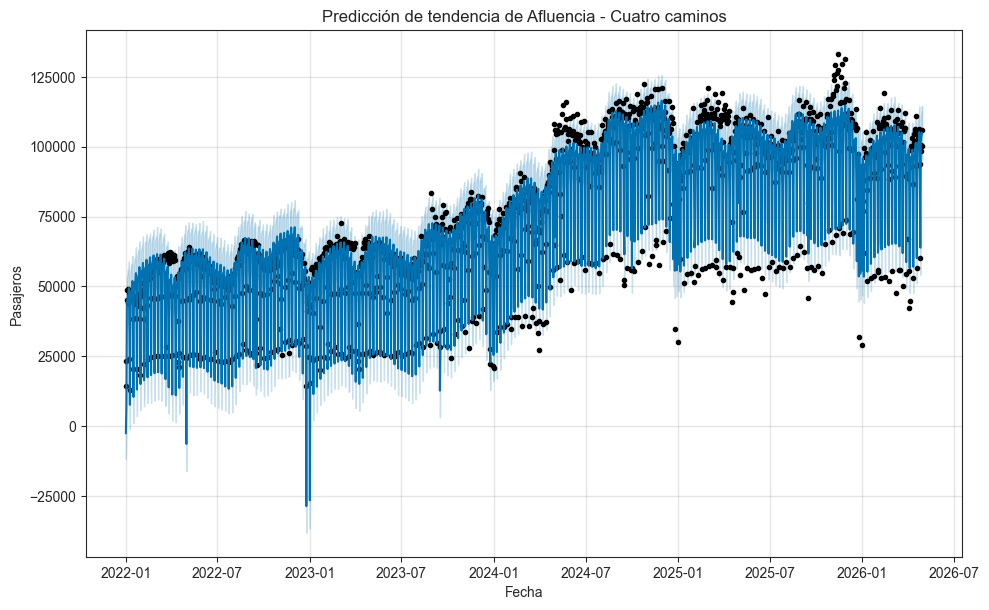

In [96]:
# 'model' es el modelo entrenado y 'forecast' es el resultado de model.predict()
fig1 = modelo_cuatro_caminos.plot(resultados_cuatro_caminos)
plt.title("Predicción de tendencia de Afluencia - Cuatro caminos")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.show()

Las siguientes gráficas corresponden a la tendencia, días festivos oficiales (particularidad de Prophet), estacionalidad semana y estacionalidad mácroscopica a nivel anual

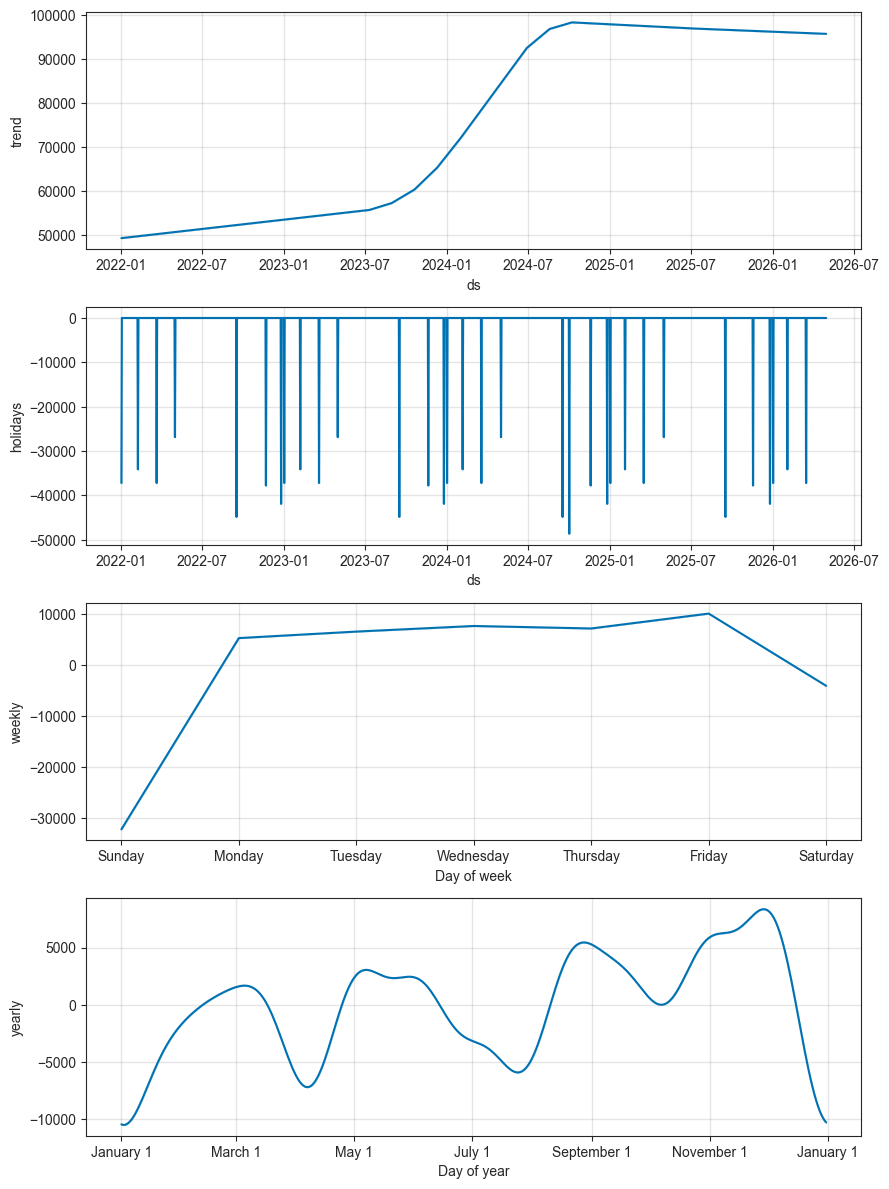

In [97]:
fig2 = modelo_cuatro_caminos.plot_components(resultados_cuatro_caminos)
plt.show()

Las siguientes gráficas muestran las métricas de rendimiento de los modelos.

Grafico 1
Los puntos negros que representan los datos reales muestran como para los fines de semana la afluencia cae demasiado y entre semana se recupera la afluencia, esta es la estacionalidad semanal que depende de la rutina social
La línea roja que representa a zscore la cuál decae por debajo de los datos reales dado la sensibilidad a los outliers
La línea verde (MAD) se acerca más a los datos reales de afluencia entre semana, pero se ajusta tanto a la afluencia semanal que no detecta la caida de los fines de semana

Gráfico 2
El segundo gráfico muestra como prophet detecta la estacionalidad semanal y se aproxima más a los datos reales
También se confirma que MAD se ajusta a la afluencia entre semana y no detecta las caidas de los fines de semana

Gráfico 3
El gráfico representa la comparación de metricas de rendimiento entre zscore, MAD y prophet.
Al evaluar los modelos sobre la afluencia diaria consolidada, Prophet demostró una superioridad predictiva absoluta con un MAPE del 8.68%. Los estimadores móviles (Media y Mediana) sufrieron penalizaciones severas en su métrica RMSE (superando los 15,000) debido a su incapacidad para anticipar las caídas determinísticas de los fines de semana. Esto valida que la estacionalidad, y no solo la inercia reciente, es el factor dominante en la red.

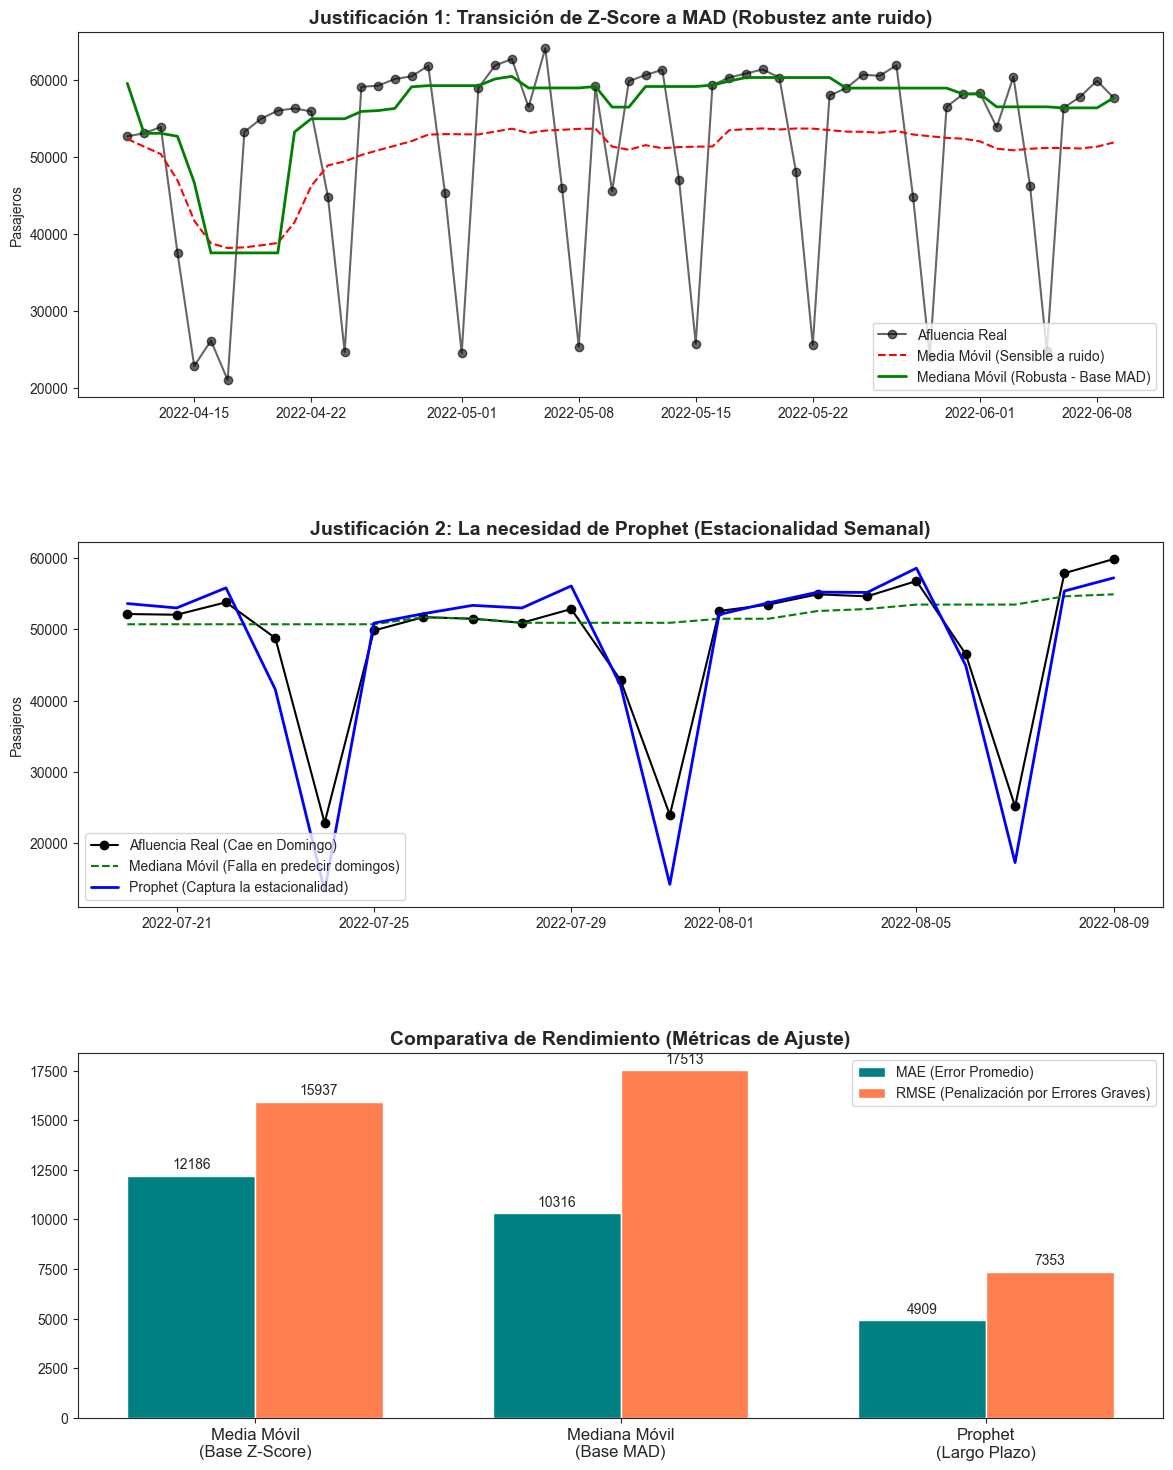

--- RESUMEN DE MÉTRICAS PARA EL DOCUMENTO DE TT ---
Modelo          | MAE (Pasajeros) | RMSE            | MAPE (%)
Media Móvil     |        12186.97 |        15937.12 | 22.79%
Mediana Móvil   |        10316.28 |        17513.97 | 22.42%
Prophet         |         4909.38 |         7353.93 | 8.78%


In [98]:
# 1. Preparar el DataFrame (Se usan los resultados previos de cuatro caminos)
df_story = resultados_cuatro_caminos[['ds', 'y', 'yhat']].copy()
df_story = df_story.rename(columns={'ds': 'fecha', 'y': 'afluencia_real', 'yhat': 'prediccion_prophet'})

# Calcular Media Móvil (Base del Z-Score) y Mediana Móvil (Base del MAD)
# Se establece ventana de 7 días
window = 7
df_story['media_movil'] = df_story['afluencia_real'].rolling(window=window, min_periods=1).mean()
df_story['mediana_movil'] = df_story['afluencia_real'].rolling(window=window, min_periods=1).median()

# Limpiar nulos iniciales si los hay
df_story = df_story.dropna()

# 2. Calcular Métricas de Rendimiento
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_media, rmse_media, mape_media = calculate_metrics(df_story['afluencia_real'], df_story['media_movil'])
mae_mediana, rmse_mediana, mape_mediana = calculate_metrics(df_story['afluencia_real'], df_story['mediana_movil'])
mae_prophet, rmse_prophet, mape_prophet = calculate_metrics(df_story['afluencia_real'], df_story['prediccion_prophet'])

# 3. CREACIÓN DEL PANEL GRÁFICO
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
plt.subplots_adjust(hspace=0.4)

# --- GRÁFICA A: El problema de la inercia y los outliers ---
# zoom a un periodo específico de 2 meses para que se note
zoom_df = df_story.iloc[100:160] 

axes[0].plot(zoom_df['fecha'], zoom_df['afluencia_real'], label='Afluencia Real', color='black', marker='o', alpha=0.6)
axes[0].plot(zoom_df['fecha'], zoom_df['media_movil'], label='Media Móvil (Sensible a ruido)', color='red', linestyle='--')
axes[0].plot(zoom_df['fecha'], zoom_df['mediana_movil'], label='Mediana Móvil (Robusta - Base MAD)', color='green', linewidth=2)
axes[0].set_title('Justificación 1: Transición de Z-Score a MAD (Robustez ante ruido)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Pasajeros')
axes[0].legend()

# --- la estacionalidad ---
# Zoom a 3 semanas para ver los fines de semana claros
zoom_semanas = df_story.iloc[200:221]

axes[1].plot(zoom_semanas['fecha'], zoom_semanas['afluencia_real'], label='Afluencia Real (Cae en Domingo)', color='black', marker='o')
axes[1].plot(zoom_semanas['fecha'], zoom_semanas['mediana_movil'], label='Mediana Móvil (Falla en predecir domingos)', color='green', linestyle='--')
axes[1].plot(zoom_semanas['fecha'], zoom_semanas['prediccion_prophet'], label='Prophet (Captura la estacionalidad)', color='blue', linewidth=2)
axes[1].set_title('Justificación 2: La necesidad de Prophet (Estacionalidad Semanal)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pasajeros')
axes[1].legend()

# --- Resultados de tecnicas Matemáticas ---
modelos = ['Media Móvil\n(Base Z-Score)', 'Mediana Móvil\n(Base MAD)', 'Prophet\n(Largo Plazo)']
mae_scores = [mae_media, mae_mediana, mae_prophet]
rmse_scores = [rmse_media, rmse_mediana, rmse_prophet]

x = np.arange(len(modelos))
width = 0.35

rects1 = axes[2].bar(x - width/2, mae_scores, width, label='MAE (Error Promedio)', color='teal')
rects2 = axes[2].bar(x + width/2, rmse_scores, width, label='RMSE (Penalización por Errores Graves)', color='coral')

axes[2].set_title('Comparativa de Rendimiento (Métricas de Ajuste)', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos, fontsize=12)
axes[2].legend()

# Añadir valores sobre las barras
for rect in rects1 + rects2:
    height = rect.get_height()
    axes[2].annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()

# Imprimir tabla resumen
print("--- RESUMEN DE MÉTRICAS PARA EL DOCUMENTO DE TT ---")
print(f"Modelo          | MAE (Pasajeros) | RMSE            | MAPE (%)")
print(f"Media Móvil     | {mae_media:15.2f} | {rmse_media:15.2f} | {mape_media:.2f}%")
print(f"Mediana Móvil   | {mae_mediana:15.2f} | {rmse_mediana:15.2f} | {mape_mediana:.2f}%")
print(f"Prophet         | {mae_prophet:15.2f} | {rmse_prophet:15.2f} | {mape_prophet:.2f}%")

Exportación de las anomalias de la estación cuatro caminos a csv

In [99]:
# 1. Filtrar solo las filas que Prophet marcó como anomalía
df_anomalias = resultados_cuatro_caminos[resultados_cuatro_caminos['anomalia_prophet'] == True].copy()

# 2. Calcular métricas de impacto para la auditoría
# Impacto absoluto: cuántos pasajeros se "perdieron" o "ganaron" vs lo esperado
df_anomalias['diferencia_pasajeros'] = round(df_anomalias['y'] - df_anomalias['yhat'], 0)

# Impacto porcentual: qué tan grave fue la desviación
df_anomalias['impacto_pct'] = round((df_anomalias['diferencia_pasajeros'] / df_anomalias['yhat']) * 100, 2)

# 3. Clasificar por dirección (Caída o Incremento)
df_anomalias['tipo_evento'] = df_anomalias['diferencia_pasajeros'].apply(
    lambda x: 'Caída de Afluencia (Posible Falla)' if x < 0 else 'Incremento Atípico (Evento)'
)

# 4. Seleccionar y limpiar columnas para el reporte final
reporte_auditoria = df_anomalias[[
    'ds', 'y', 'yhat', 'diferencia_pasajeros', 'impacto_pct', 'tipo_evento'
]].rename(columns={
    'ds': 'fecha',
    'y': 'afluencia_real',
    'yhat': 'afluencia_esperada'
})

# 5. Ordenar por las caídas más severas (prioridad de auditoría)
reporte_auditoria = reporte_auditoria.sort_values(by='impacto_pct')

# 6. Exportar a CSV para el integrante encargado del cruce de datos
reporte_auditoria.to_csv('anomalias_detectadas_cuatro_caminos.csv', index=False)

print(f"Se han extraído {len(reporte_auditoria)} anomalías.")
print(reporte_auditoria.head())

Se han extraído 205 anomalías.
         fecha  afluencia_real  afluencia_esperada  diferencia_pasajeros  \
0   2022-01-01           14346        -2546.431875               16892.0   
120 2022-05-01           24526        -6312.408478               30838.0   
365 2023-01-01           15457       -26445.060873               41902.0   
358 2022-12-25           14393       -28555.439021               42948.0   
818 2024-03-29           33302        84882.014096              -51580.0   

     impacto_pct                         tipo_evento  
0        -663.36         Incremento Atípico (Evento)  
120      -488.53         Incremento Atípico (Evento)  
365      -158.45         Incremento Atípico (Evento)  
358      -150.40         Incremento Atípico (Evento)  
818       -60.77  Caída de Afluencia (Posible Falla)  


A continuación se procesan todas las estaciones, genera las predicciones de prophet y MAD creando una clasificación de las anomalías:

CRÍTICA (Consenso Absoluto)
¿Qué significa?: MAD detectó que hoy hubo un desplome severo de gente comparado con los últimos 7 días Y Prophet confirmó que ese desplome es matemáticamente imposible para esta época del año.
Interpretación Operativa: Es un Incidente Mayor casi seguro. Hubo un cierre de estación, un corte de energía prolongado o un tren descarrilado.

ALTA (Desviación Estacional)
¿Qué significa?: MAD dijo "todo normal" (la afluencia se parece a la de ayer), PERO Prophet detectó que los números están muy por debajo de lo que dicta la historia.
Interpretación Operativa: Es un Fallo Crónico o Degradación de Servicio. Por ejemplo: si una escalera eléctrica gigante lleva rota toda la semana, la gente empieza a evitar esa estación paulatinamente. MAD no lo nota porque la caída es lenta, pero Prophet sabe que ahí debería haber un 20% más de pasajeros.

MEDIA (Shock Local / Ruido)
¿Qué significa?: MAD detectó una caída brusca respecto a ayer, PERO Prophet dice que "es normal, siempre pasa en estas fechas".
Interpretación Operativa: Suele ser comportamiento natural de la ciudad. Por ejemplo, el jueves de Semana Santa. MAD ve que ayer miércoles estaba lleno y hoy vacío, por lo que entra en pánico. Prophet sabe que es festividad y desestima la alerta.

# **MODELO PARA LAS 195 SERIES DE TIEMPO**

In [187]:
def motor_auditoria_consenso_mad_bidireccional(df_input):
    resultados_master = []
    grupos = df_input.groupby(['linea', 'estacion'])
    total = len(grupos)
    
    print(f"Iniciando auditoría masiva bidireccional para {total} estaciones...")

    for i, ((linea, estacion), df_grupo) in enumerate(grupos, 1):
        try:
            df_p = df_grupo.copy()
            if 'fecha' not in df_p.columns: df_p = df_p.reset_index()
            df_prophet = df_p[['fecha', 'afluencia']].rename(columns={'fecha': 'ds', 'afluencia': 'y'})

            m = Prophet(yearly_seasonality=True, weekly_seasonality=True, changepoint_prior_scale=0.03)
            m.add_country_holidays(country_name='MX')
            m.fit(df_prophet)
            
            forecast = m.predict(df_prophet)
            
            df_merge = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
                df_p[['fecha', 'afluencia', 'zscore_robusto']], 
                left_on='ds', right_on='fecha'
            )
            
            # --- Detección en ambas direcciones (Alza y Baja) ---
            df_merge['det_prophet'] = (df_merge['afluencia'] < df_merge['yhat_lower']) | (df_merge['afluencia'] > df_merge['yhat_upper'])
            df_merge['det_mad'] = (df_merge['zscore_robusto'] < -3) | (df_merge['zscore_robusto'] > 3)
            
            # Reglas de Consenso
            conditions = [
                (df_merge['det_prophet'] & df_merge['det_mad']), 
                (df_merge['det_prophet'] & ~df_merge['det_mad']),
                (~df_merge['det_prophet'] & df_merge['det_mad']) 
            ]
            prioridades = ['CRÍTICA (Consenso)', 'ALTA (Solo Prophet)', 'MEDIA (Solo MAD)']
            df_merge['prioridad_auditoria'] = np.select(conditions, prioridades, default='Normal')
            
            df_merge['linea'] = linea
            df_merge['estacion'] = estacion
            df_merge['impacto_pasajeros'] = round(df_merge['afluencia'] - df_merge['yhat'], 0)
            
            # --- Etiquetado de la dirección de la anomalía ---
            df_merge['direccion_anomalia'] = np.where(df_merge['impacto_pasajeros'] > 0, 'Alza (Pico atípico)', 'Baja (Caída atípica)')
            
            # Guardar solo anomalías
            anomalias = df_merge[df_merge['prioridad_auditoria'] != 'Normal'].copy()
            resultados_master.append(anomalias)
            
            if i % 10 == 0: print(f"Progreso: {i}/{total} estaciones procesadas.")
            
        except Exception as e:
            print(f"Error en {estacion} ({linea}): {e}")
            continue

    df_final = pd.concat(resultados_master, ignore_index=True)
    return df_final

# Ejecución
master_auditoria = motor_auditoria_consenso_mad_bidireccional(df_limpio)

master_auditoria.to_csv('master_auditoria_consenso_MAD.csv', index=False)
master_auditoria.to_excel('master_auditoria_consenso_MAD.xlsx', index=False)

Iniciando auditoría masiva bidireccional para 196 estaciones...


23:43:32 - cmdstanpy - INFO - Chain [1] start processing
23:43:32 - cmdstanpy - INFO - Chain [1] done processing
23:43:32 - cmdstanpy - INFO - Chain [1] start processing
23:43:32 - cmdstanpy - INFO - Chain [1] done processing
23:43:32 - cmdstanpy - INFO - Chain [1] start processing
23:43:33 - cmdstanpy - INFO - Chain [1] done processing
23:43:33 - cmdstanpy - INFO - Chain [1] start processing
23:43:33 - cmdstanpy - INFO - Chain [1] done processing
23:43:33 - cmdstanpy - INFO - Chain [1] start processing
23:43:33 - cmdstanpy - INFO - Chain [1] done processing
23:43:34 - cmdstanpy - INFO - Chain [1] start processing
23:43:34 - cmdstanpy - INFO - Chain [1] done processing
23:43:34 - cmdstanpy - INFO - Chain [1] start processing
23:43:34 - cmdstanpy - INFO - Chain [1] done processing
23:43:34 - cmdstanpy - INFO - Chain [1] start processing
23:43:34 - cmdstanpy - INFO - Chain [1] done processing
23:43:34 - cmdstanpy - INFO - Chain [1] start processing
23:43:34 - cmdstanpy - INFO - Chain [1]

Progreso: 10/196 estaciones procesadas.


23:43:35 - cmdstanpy - INFO - Chain [1] done processing
23:43:35 - cmdstanpy - INFO - Chain [1] start processing
23:43:35 - cmdstanpy - INFO - Chain [1] done processing
23:43:36 - cmdstanpy - INFO - Chain [1] start processing
23:43:36 - cmdstanpy - INFO - Chain [1] done processing
23:43:36 - cmdstanpy - INFO - Chain [1] start processing
23:43:36 - cmdstanpy - INFO - Chain [1] done processing
23:43:36 - cmdstanpy - INFO - Chain [1] start processing
23:43:36 - cmdstanpy - INFO - Chain [1] done processing
23:43:36 - cmdstanpy - INFO - Chain [1] start processing
23:43:37 - cmdstanpy - INFO - Chain [1] done processing
23:43:37 - cmdstanpy - INFO - Chain [1] start processing
23:43:37 - cmdstanpy - INFO - Chain [1] done processing
23:43:37 - cmdstanpy - INFO - Chain [1] start processing
23:43:37 - cmdstanpy - INFO - Chain [1] done processing
23:43:37 - cmdstanpy - INFO - Chain [1] start processing
23:43:38 - cmdstanpy - INFO - Chain [1] done processing
23:43:38 - cmdstanpy - INFO - Chain [1] 

Progreso: 20/196 estaciones procesadas.


...

23:44:22 - cmdstanpy - INFO - Chain [1] start processing
23:44:23 - cmdstanpy - INFO - Chain [1] done processing
23:44:23 - cmdstanpy - INFO - Chain [1] start processing
23:44:23 - cmdstanpy - INFO - Chain [1] done processing
23:44:23 - cmdstanpy - INFO - Chain [1] start processing
23:44:23 - cmdstanpy - INFO - Chain [1] done processing
23:44:23 - cmdstanpy - INFO - Chain [1] start processing
23:44:23 - cmdstanpy - INFO - Chain [1] done processing
23:44:24 - cmdstanpy - INFO - Chain [1] start processing
23:44:24 - cmdstanpy - INFO - Chain [1] done processing
23:44:24 - cmdstanpy - INFO - Chain [1] start processing
23:44:24 - cmdstanpy - INFO - Chain [1] done processing
23:44:24 - cmdstanpy - INFO - Chain [1] start processing
23:44:24 - cmdstanpy - INFO - Chain [1] done processing
23:44:24 - cmdstanpy - INFO - Chain [1] start processing
23:44:25 - cmdstanpy - INFO - Chain [1] done processing
23:44:25 - cmdstanpy - INFO - Chain [1] start processing
23:44:25 - cmdstanpy - INFO - Chain [1]

Progreso: 180/196 estaciones procesadas.


23:44:25 - cmdstanpy - INFO - Chain [1] start processing
23:44:25 - cmdstanpy - INFO - Chain [1] done processing
23:44:26 - cmdstanpy - INFO - Chain [1] start processing
23:44:26 - cmdstanpy - INFO - Chain [1] done processing
23:44:26 - cmdstanpy - INFO - Chain [1] start processing
23:44:26 - cmdstanpy - INFO - Chain [1] done processing
23:44:26 - cmdstanpy - INFO - Chain [1] start processing
23:44:26 - cmdstanpy - INFO - Chain [1] done processing
23:44:27 - cmdstanpy - INFO - Chain [1] start processing
23:44:27 - cmdstanpy - INFO - Chain [1] done processing
23:44:27 - cmdstanpy - INFO - Chain [1] start processing
23:44:27 - cmdstanpy - INFO - Chain [1] done processing
23:44:27 - cmdstanpy - INFO - Chain [1] start processing
23:44:27 - cmdstanpy - INFO - Chain [1] done processing
23:44:28 - cmdstanpy - INFO - Chain [1] start processing
23:44:28 - cmdstanpy - INFO - Chain [1] done processing
23:44:28 - cmdstanpy - INFO - Chain [1] start processing
23:44:28 - cmdstanpy - INFO - Chain [1]

Progreso: 190/196 estaciones procesadas.


23:44:28 - cmdstanpy - INFO - Chain [1] start processing
23:44:29 - cmdstanpy - INFO - Chain [1] done processing
23:44:29 - cmdstanpy - INFO - Chain [1] start processing
23:44:29 - cmdstanpy - INFO - Chain [1] done processing
23:44:29 - cmdstanpy - INFO - Chain [1] start processing
23:44:29 - cmdstanpy - INFO - Chain [1] done processing
23:44:29 - cmdstanpy - INFO - Chain [1] start processing
23:44:29 - cmdstanpy - INFO - Chain [1] done processing
23:44:30 - cmdstanpy - INFO - Chain [1] start processing
23:44:30 - cmdstanpy - INFO - Chain [1] done processing


# RESULTADOS: PROPHET + Z-SCORE ROBUSTO

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/868587453.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




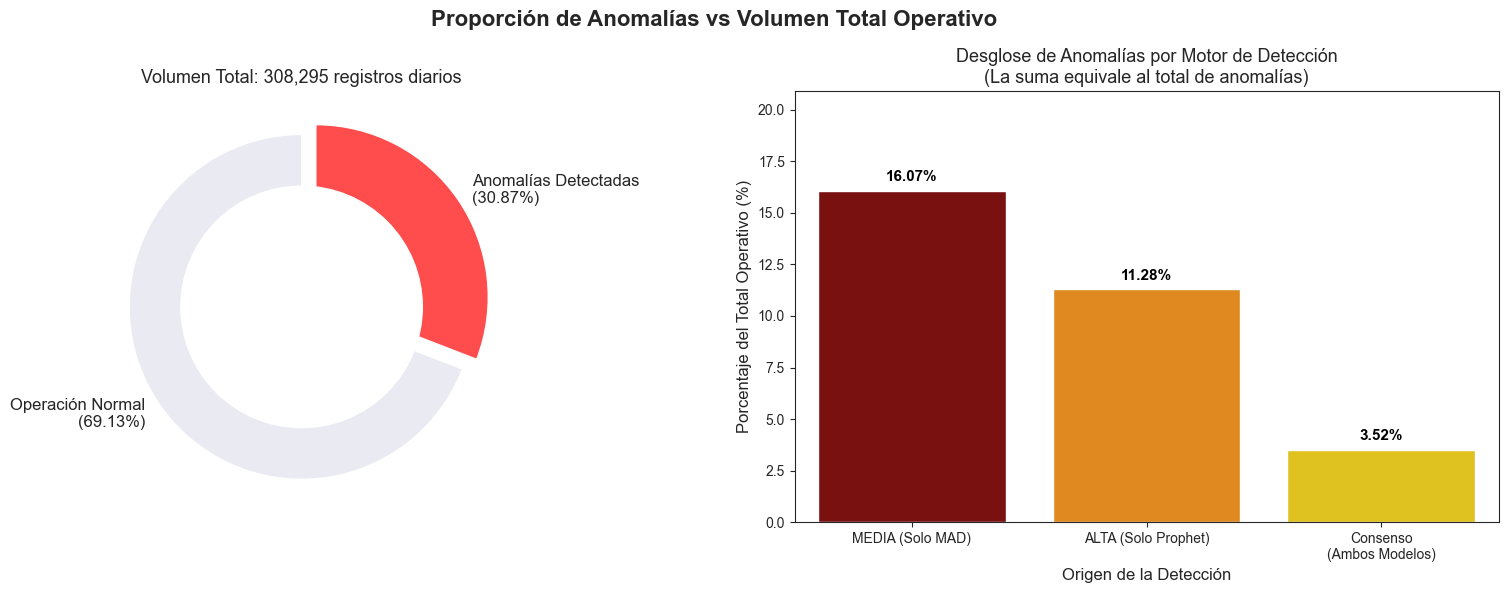

In [188]:
def graficar_balance_anomalias(df_total, df_anomalias):
    # ---------------------------------------------------------
    # Evitar el doble conteo
    # un mismo evento (fecha-línea-estacion) no sume dos veces
    # ---------------------------------------------------------
    df_anomalias_unicas = df_anomalias.drop_duplicates(subset=['fecha', 'linea', 'estacion']).copy()
    
    # 1. Cálculos de proporciones exactas
    total_registros = len(df_total)
    total_anomalos = len(df_anomalias_unicas)
    total_normales = total_registros - total_anomalos
    
    pct_normal = (total_normales / total_registros) * 100
    pct_anomalo = (total_anomalos / total_registros) * 100
    
    # Desglose de prioridades respecto al TOTAL de los datos
    conteo_prioridad = df_anomalias_unicas['prioridad_auditoria'].value_counts()
    
    # Renombrar índices para evidenciar que son mutuamente excluyentes

    mapeo_nombres = {
        'CRÍTICA (Consenso)': 'Consenso\n(Ambos Modelos)',
        'ALTA (Prophet)': 'Exclusivo\n(Solo Prophet)',
        'MEDIA (Z-Score)': 'Exclusivo\n(Solo MAD)'
    }
    conteo_prioridad.index = conteo_prioridad.index.map(lambda x: mapeo_nombres.get(x, x))
    
    pct_prioridades = (conteo_prioridad / total_registros) * 100
    
    # 2. Configuración del panel visual
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Proporción de Anomalías vs Volumen Total Operativo', fontsize=16, fontweight='bold')
    
    # --- El panorama general (Donut Chart) ---
    labels_macro = [f'Operación Normal\n({pct_normal:.2f}%)', f'Anomalías Detectadas\n({pct_anomalo:.2f}%)']
    sizes_macro = [total_normales, total_anomalos]
    colors_macro = ['#EAEAF2', '#FF4C4C']
    explode = (0, 0.1)  # Destacar las anomalías
    
    ax1.pie(sizes_macro, explode=explode, labels=labels_macro, colors=colors_macro, 
            autopct='', shadow=False, startangle=90, textprops={'fontsize': 12})
    
    # Convertir a gráfica de dona
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax1.add_patch(centre_circle)
    ax1.set_title(f'Volumen Total: {total_registros:,} registros diarios', fontsize=13)
    
    # --- Desglose de Criticidad (Bar Chart) ---
    sns.barplot(x=pct_prioridades.index, y=pct_prioridades.values, ax=ax2, 
                palette=['#8B0000', '#FF8C00', '#FFD700'])
    
    ax2.set_title('Desglose de Anomalías por Motor de Detección\n(La suma equivale al total de anomalías)', fontsize=13)
    ax2.set_ylabel('Porcentaje del Total Operativo (%)', fontsize=12)
    ax2.set_xlabel('Origen de la Detección', fontsize=12)
    
    # etiquetas de datos sobre las barras
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                     textcoords='offset points')
        
    # eje Y para porcentajes pequeños
    ax2.set_ylim(0, max(pct_prioridades.values) * 1.3)
    
    plt.tight_layout()
    plt.show()

# Ejecución de la gráfica 
graficar_balance_anomalias(df_limpio_copy, master_auditoria)

Código para obtención de la muestra calculada necesaria para un 95% de confianza y un 5% de margen de error:
$$n = \frac{N \cdot Z^2 \cdot p \cdot (1-p)}{(N-1) \cdot e^2 + Z^2 \cdot p \cdot (1-p)}$$
Donde:

$N$ = Tamaño de la población ($11,117$)

$Z$ = Nivel de confianza del 95% ($1.96$)

$e$ = Margen de error del 5% ($0.05$)$p$ = Probabilidad de ocurrencia ($0.5$, para maximizar el tamaño de muestra y ser conservadores)

Si sustituimos los valores:

$$n = \frac{11117 \cdot (1.96)^2 \cdot 0.5 \cdot 0.5}{(11116) \cdot (0.05)^2 + (1.96)^2 \cdot 0.5 \cdot 0.5} \approx 372$$

Técnica: Muestreo Estratificado Proporcional

Esta técnica divide los registros de anomalías críticas (donde prophet y MAD covergen) en "estratos" (subgrupos lógicos) y toma una muestra proporcional al peso de cada grupo. Si la Línea 1 tiene el 20% de las anomalías totales, la técnica se asegurará de que el 20% de tu muestra de 372 registros pertenezca exactamente a la Línea 1.

Los estratos más lógicos para nuestros datos son "Línea" y "Dirección" de la anomalía (Alza/Baja).

El siguiente código tiene como finalidad confirmar la replicabilidad de la extracción de la muestra, aunque la muestra utilizada para el resto del proyecto se extrajo del mismo algoritmo, fue una muestra unica extraida el 24 de abril del 2026

In [102]:
# 1. Filtrado de solo anomalías Críticas
df_criticas = master_auditoria[master_auditoria['prioridad_auditoria'] == 'CRÍTICA (Consenso)'].copy()
df_criticas.columns = df_criticas.columns.str.strip().str.lower()

#  la fila 1 siempre sera la misma en cualquier computadora
df_criticas = df_criticas.sort_values(by=['fecha', 'linea', 'estacion']).reset_index(drop=True)
# ---------------------------------------------------------

# 2. Definimos el tamaño de muestra que nos dio la fórmula estadística
tamaño_muestra = 372

# 3. Calculo de la fracción (el porcentaje de los 11,117 registros)
fraccion = tamaño_muestra / len(df_criticas)

# 4. Muestreo Estratificado Proporcional por Línea y Dirección de Anomalía
muestra_auditoria = df_criticas.groupby(
    ['linea', 'direccion_anomalia'], 
    group_keys=False
).sample(frac=fraccion, random_state=42)

# 5. CSV para la investigación manual
muestra_auditoria.to_csv('muestra_estratificada_auditoria_manual.csv', index=False)
muestra_auditoria.to_excel('muestra_estratificada_auditoria_manual.xlsx', index=False)

print(f"Población total de anomalías críticas: {len(df_criticas)}")
print(f"Tamaño de la muestra extraída: {len(muestra_auditoria)}")
print("Columnas preservadas exitosamente:", muestra_auditoria.columns.tolist())

Población total de anomalías críticas: 11134
Tamaño de la muestra extraída: 373
Columnas preservadas exitosamente: ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'fecha', 'afluencia', 'zscore_robusto', 'det_prophet', 'det_mad', 'prioridad_auditoria', 'linea', 'estacion', 'impacto_pasajeros', 'direccion_anomalia']


El siguiente código de comparativa muestra los gráficos de comparación del comportamiento del total de anomalías detectadas por nuestro modelo contra el comportamiento de la muestra replicable


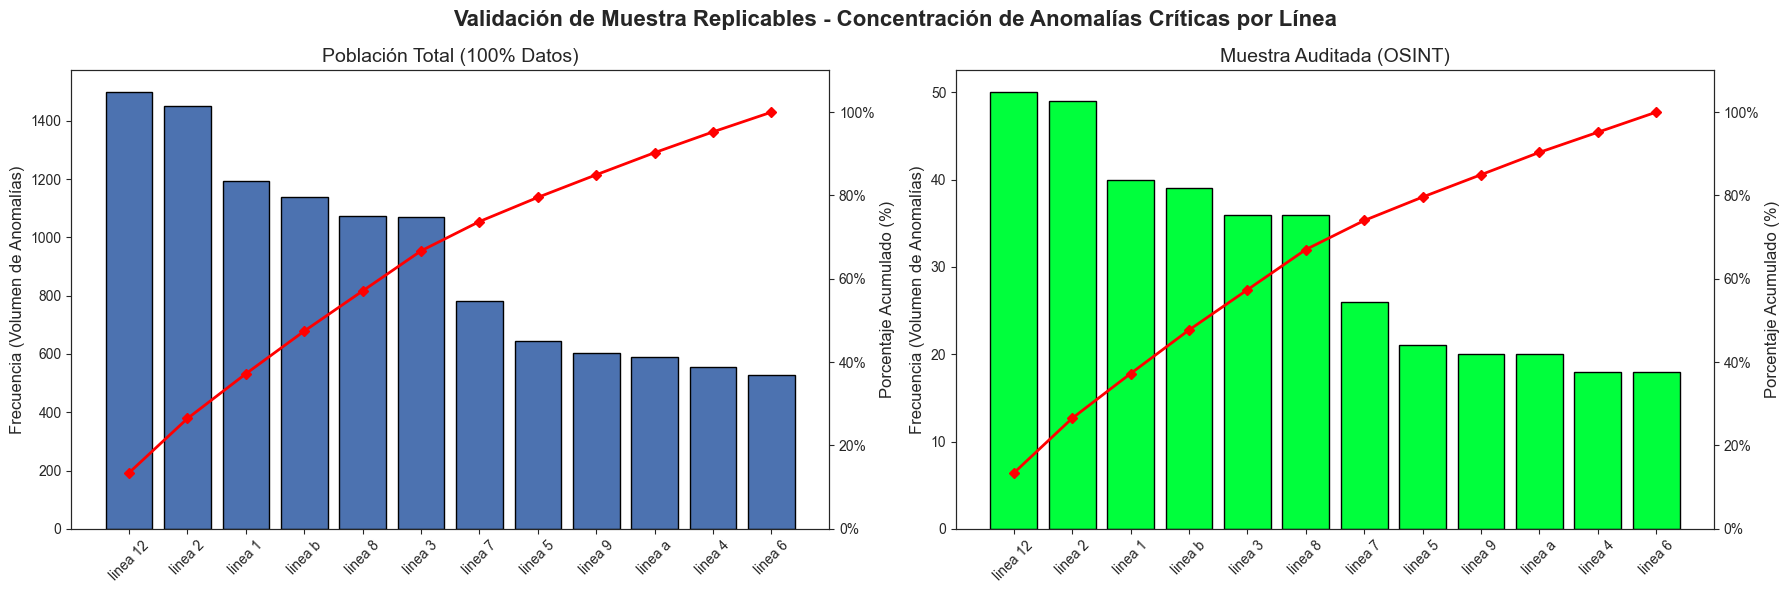

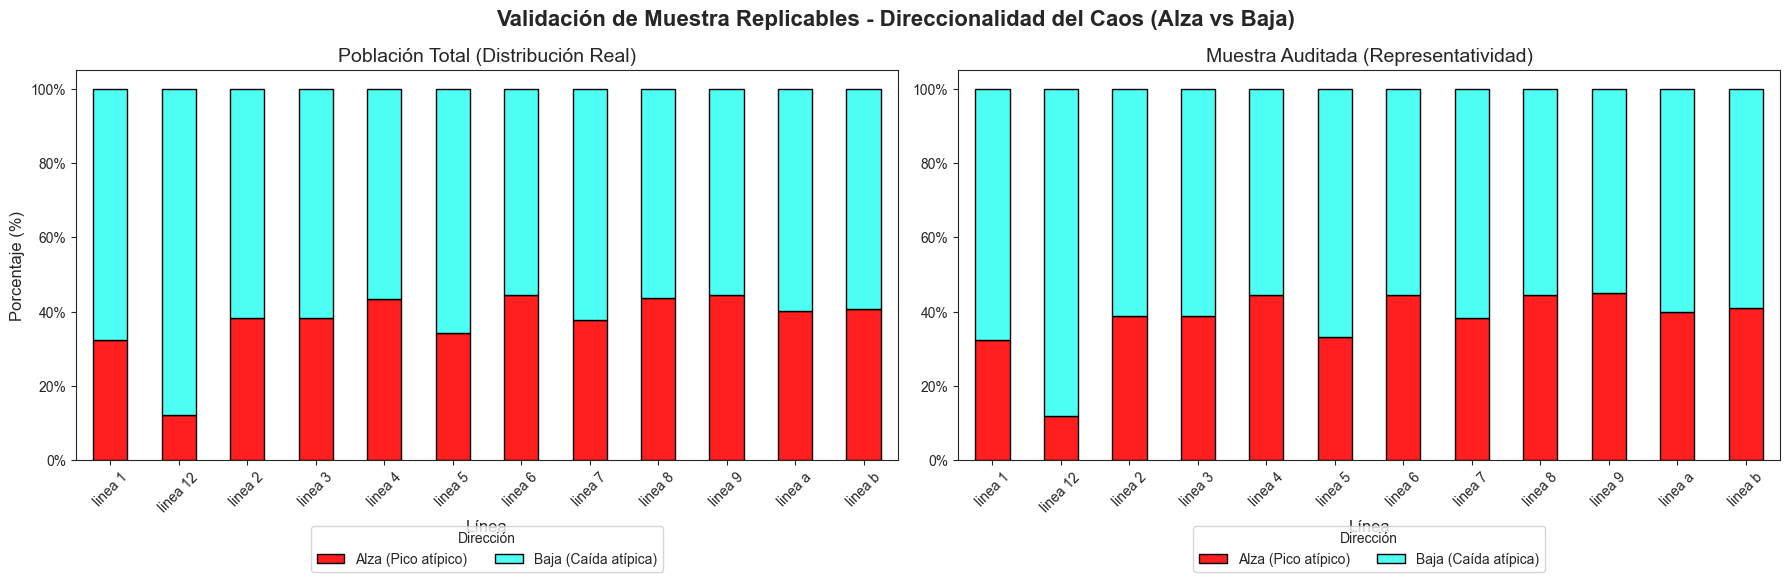

In [107]:
# 0. CARGA Y PREPARACIÓN DE DATOS
# Cargar el archivo de la población total de anomalías
df_poblacion = pd.read_csv('master_auditoria_consenso_MAD.csv') 
# Filtrar solo las anomalías críticas de la población total
df_pob_critica = df_poblacion[df_poblacion['prioridad_auditoria'].str.contains('CRÍTICA', na=False)].copy()

# Cargar el archivo de la muestra auditada manualmente
df_muestra = pd.read_csv('muestra_estratificada_auditoria_manual.csv')

# Normalizar los nombres de columnas para que coincidan (minúsculas)
df_muestra.columns = df_muestra.columns.str.strip().str.lower()
df_pob_critica.columns = df_pob_critica.columns.str.strip().str.lower()

# DIAGRAMA DE PARETO DUAL (Concentración por Línea)
def calcular_pareto(df, columna):
    """Calcula frecuencias y porcentaje acumulado para Pareto"""
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = [columna, 'frecuencia']
    conteo['pct'] = (conteo['frecuencia'] / conteo['frecuencia'].sum()) * 100
    conteo['acumulado'] = conteo['pct'].cumsum()
    return conteo

pareto_pob = calcular_pareto(df_pob_critica, 'linea')
pareto_muestra = calcular_pareto(df_muestra, 'linea')

# Crear figura para Pareto Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra Replicables - Concentración de Anomalías Críticas por Línea', fontsize=16, fontweight='bold')

# Función para graficar un Pareto
def plot_pareto(ax, data, title, color_bar):
    ax.bar(data['linea'], data['frecuencia'], color=color_bar, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Frecuencia (Volumen de Anomalías)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Eje secundario para el porcentaje acumulado
    ax_pct = ax.twinx()
    ax_pct.plot(data['linea'], data['acumulado'], color='red', marker='D', ms=5, linewidth=2)
    ax_pct.yaxis.set_major_formatter(PercentFormatter())
    ax_pct.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax_pct.set_ylim(0, 110)

plot_pareto(ax1, pareto_pob, f'Población Total (100% Datos)', '#4C72B0')
plot_pareto(ax2, pareto_muestra, f'Muestra Auditada (OSINT)', "#00FF3C")

plt.tight_layout()
plt.show()

# BALANCE DE DIRECCIONALIDAD (Alza vs Baja al 100%)
def preparar_direccionalidad(df):
    """Crea una tabla cruzada normalizada al 100% de línea vs dirección"""
    ct = pd.crosstab(df['linea'], df['direccion_anomalia'], normalize='index') * 100
    # Asegurar que las líneas estén en el mismo orden (alfabético/numérico)
    return ct.sort_index()

dir_pob = preparar_direccionalidad(df_pob_critica)
dir_muestra = preparar_direccionalidad(df_muestra)

# Crear figura para Direccionalidad Dual
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra Replicables - Direccionalidad del Caos (Alza vs Baja)', fontsize=16, fontweight='bold')

colores_dir = ["#FF1F1F", "#4DFFF3"] # Rojo suave para Baja, Verde agua para Alza

dir_pob.plot(kind='bar', stacked=True, ax=ax3, color=colores_dir, edgecolor='black')
ax3.set_title('Población Total (Distribución Real)', fontsize=14)
ax3.set_ylabel('Porcentaje (%)', fontsize=12)
ax3.set_xlabel('Línea', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

dir_muestra.plot(kind='bar', stacked=True, ax=ax4, color=colores_dir, edgecolor='black')
ax4.set_title('Muestra Auditada (Representatividad)', fontsize=14)
ax4.set_xlabel('Línea', fontsize=12)
ax4.yaxis.set_major_formatter(PercentFormatter())
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

A continuación se presentan las mismas gráficas de comparación de comportamiento pero para la muestra única obtenida el dia 24 de abril del 2026 que fue con la que se estuvo trabajando

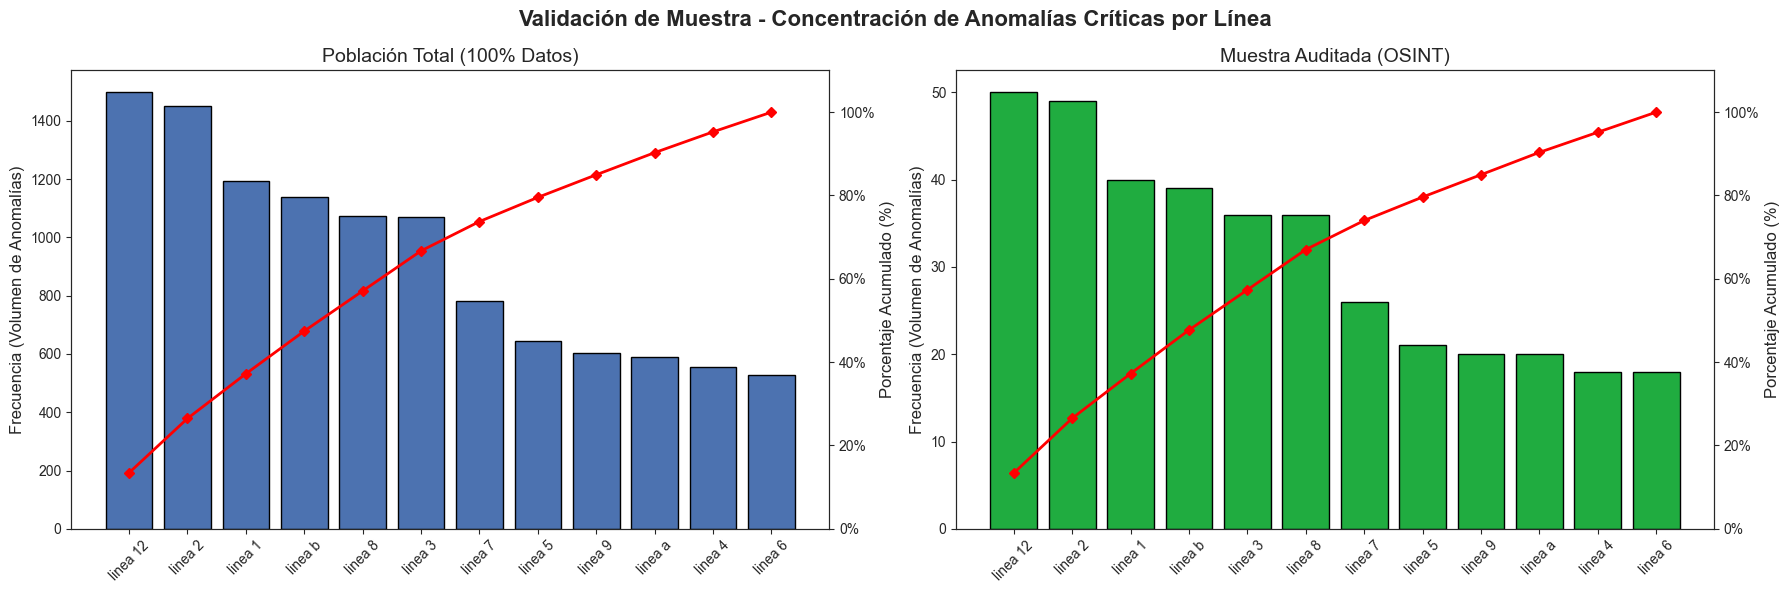

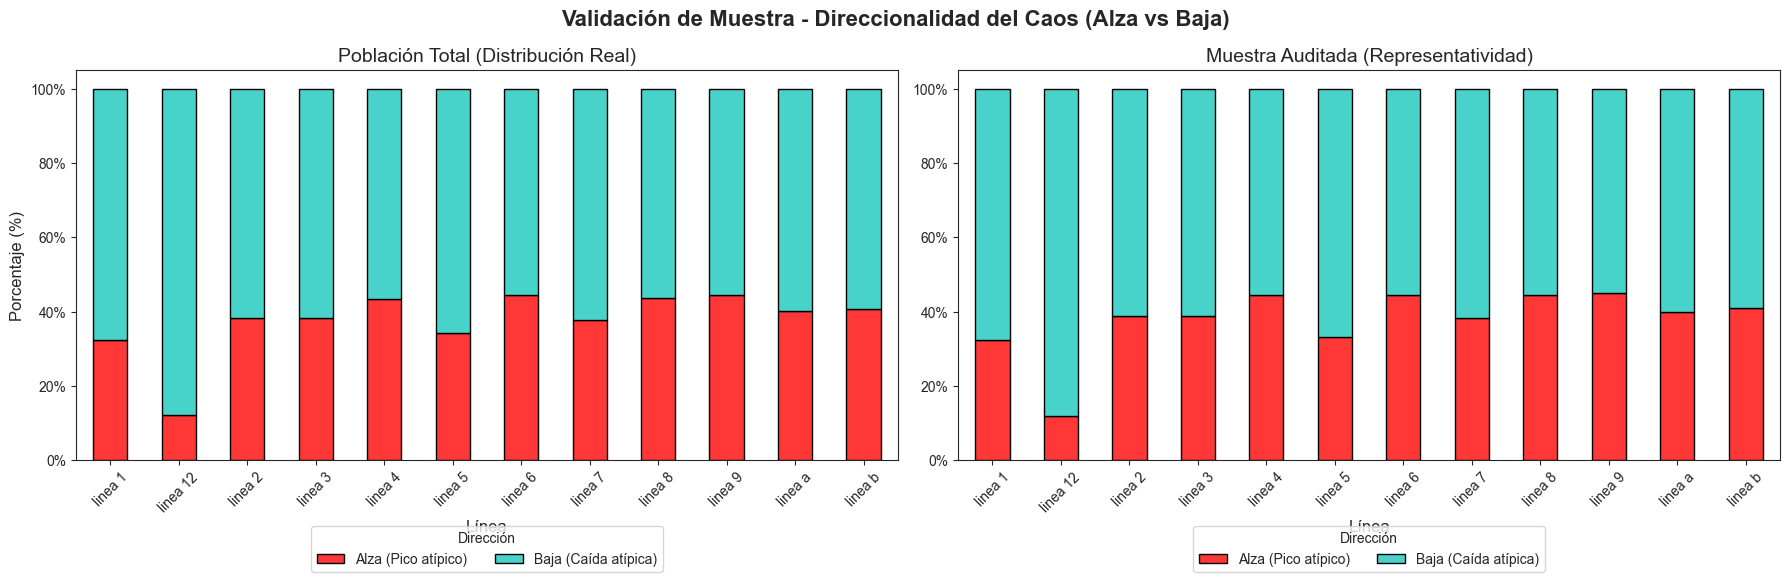

In [109]:
# 0. CARGA Y PREPARACIÓN DE DATOS
# Cargar el archivo maestro (Población Total)
df_poblacion = pd.read_csv('master_auditoria_consenso_MAD.csv') 
# Filtrar solo las anomalías críticas de la población total
df_pob_critica = df_poblacion[df_poblacion['prioridad_auditoria'].str.contains('CRÍTICA', na=False)].copy()

# Cargar el archivo de la muestra auditada manualmente
df_muestra = pd.read_excel('muestra_estratificada_auditoria_manual.xlsx')

# Normalizar los nombres de columnas para que coincidan (minúsculas)
df_muestra.columns = df_muestra.columns.str.lower()
df_pob_critica.columns = df_pob_critica.columns.str.lower()

# DIAGRAMA DE PARETO DUAL (Concentración por Línea)
def calcular_pareto(df, columna):
    """Calcula frecuencias y porcentaje acumulado para Pareto"""
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = [columna, 'frecuencia']
    conteo['pct'] = (conteo['frecuencia'] / conteo['frecuencia'].sum()) * 100
    conteo['acumulado'] = conteo['pct'].cumsum()
    return conteo

pareto_pob = calcular_pareto(df_pob_critica, 'linea')
pareto_muestra = calcular_pareto(df_muestra, 'linea')

# Crear figura para Pareto Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra - Concentración de Anomalías Críticas por Línea', fontsize=16, fontweight='bold')

# Función para graficar un Pareto
def plot_pareto(ax, data, title, color_bar):
    ax.bar(data['linea'], data['frecuencia'], color=color_bar, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Frecuencia (Volumen de Anomalías)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Eje secundario para el porcentaje acumulado
    ax_pct = ax.twinx()
    ax_pct.plot(data['linea'], data['acumulado'], color='red', marker='D', ms=5, linewidth=2)
    ax_pct.yaxis.set_major_formatter(PercentFormatter())
    ax_pct.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax_pct.set_ylim(0, 110)

plot_pareto(ax1, pareto_pob, f'Población Total (100% Datos)', '#4C72B0')
plot_pareto(ax2, pareto_muestra, f'Muestra Auditada (OSINT)', "#20AC40")

plt.tight_layout()
plt.show()

# BALANCE DE DIRECCIONALIDAD (Alza vs Baja al 100%)
def preparar_direccionalidad(df):
    """Crea una tabla cruzada normalizada al 100% de línea vs dirección"""
    ct = pd.crosstab(df['linea'], df['direccion_anomalia'], normalize='index') * 100
    # Asegurar que las líneas estén en el mismo orden (alfabético/numérico)
    return ct.sort_index()

dir_pob = preparar_direccionalidad(df_pob_critica)
dir_muestra = preparar_direccionalidad(df_muestra)

# Crear figura para Direccionalidad Dual
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra - Direccionalidad del Caos (Alza vs Baja)', fontsize=16, fontweight='bold')

colores_dir = ["#FF1D1DE2", "#48D3CA"] # Rojo suave para Baja, Verde agua para Alza

dir_pob.plot(kind='bar', stacked=True, ax=ax3, color=colores_dir, edgecolor='black')
ax3.set_title('Población Total (Distribución Real)', fontsize=14)
ax3.set_ylabel('Porcentaje (%)', fontsize=12)
ax3.set_xlabel('Línea', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

dir_muestra.plot(kind='bar', stacked=True, ax=ax4, color=colores_dir, edgecolor='black')
ax4.set_title('Muestra Auditada (Representatividad)', fontsize=14)
ax4.set_xlabel('Línea', fontsize=12)
ax4.yaxis.set_major_formatter(PercentFormatter())
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/2952930612.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



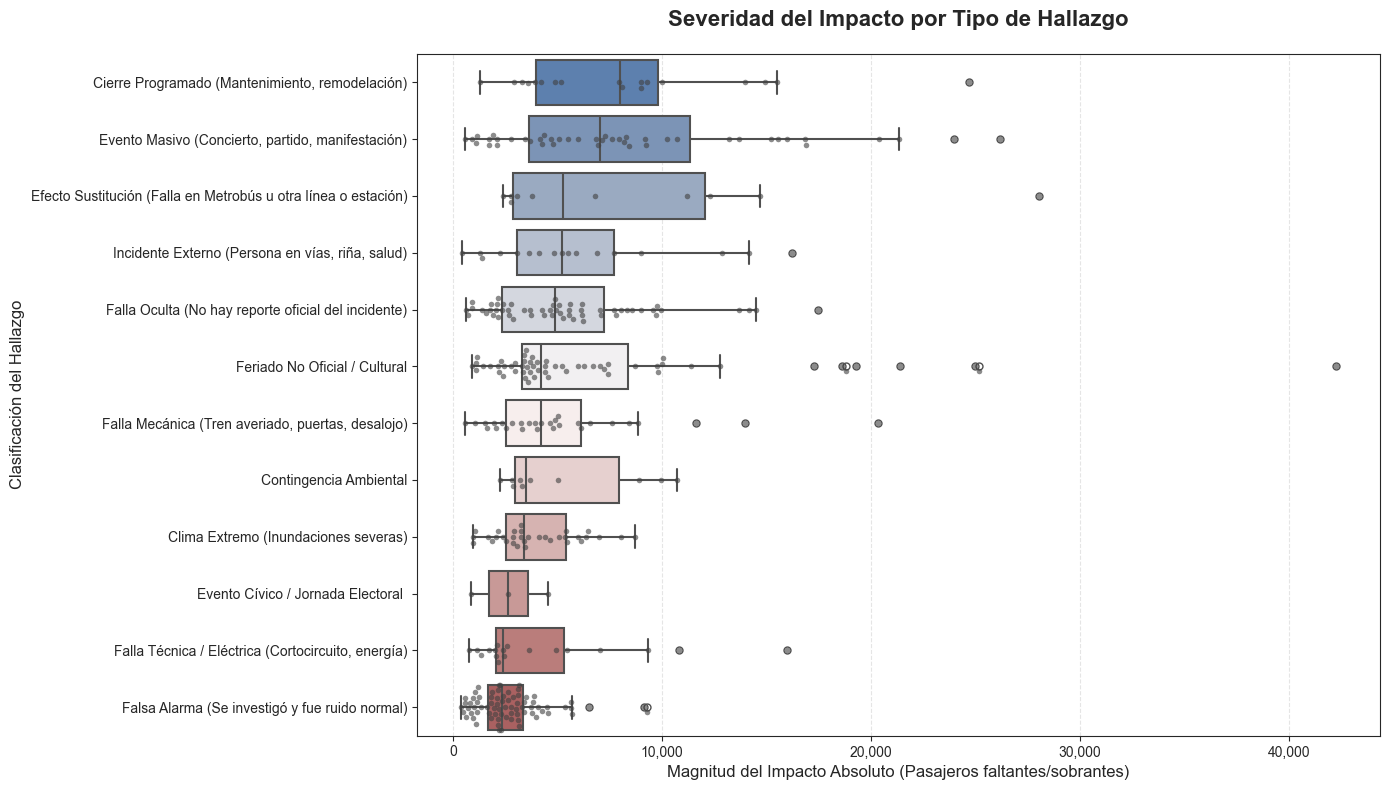

In [119]:
# 0. CARGA DE DATOS DE LA BITÁCORA MANUAL
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')

# Asegurar que los nombres de columnas coincidan
df_muestra.columns = df_muestra.columns.str.lower()
if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# Clasificación de causas encontradas en la investigación manual
conteo_causas = df_muestra['hallazgo'].value_counts().reset_index()
conteo_causas.columns = ['Causa', 'Frecuencia']
conteo_causas = conteo_causas.sort_values('Frecuencia', ascending=True)

total_anomalias = conteo_causas['Frecuencia'].sum()
conteo_causas['Porcentaje'] = (conteo_causas['Frecuencia'] / total_anomalias) * 100

#etiqueta de texto
conteo_causas['Texto_Etiqueta'] = conteo_causas.apply(
    lambda row: f"{int(row['Frecuencia'])} ({row['Porcentaje']:.1f}%)", axis=1
)

# calculo el valor máximo para extender el eje X
max_frecuencia = conteo_causas['Frecuencia'].max()

# Gráfico interactivo con paleta de colores cualitativa
fig_barras = px.bar(
    conteo_causas, 
    x='Frecuencia', 
    y='Causa', 
    orientation='h',
    text='Texto_Etiqueta',
    color='Causa', 
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='<b>Clasificación de Causas (Investigación OSINT)</b>',
    labels={'Frecuencia': 'Número de Incidentes Críticos', 'Causa': 'Clasificación del Hallazgo'}
)

fig_barras.update_traces(
    textposition='outside', 
    textfont=dict(size=10, color='#333333'),
    cliponaxis=False  #  Evita que el eje corte el texto
)

fig_barras.update_layout(
    template='plotly_white', 
    height=500,
    showlegend=False, 
    xaxis=dict(
        showgrid=True, 
        gridcolor='#E5E5E5',
        range=[0, max_frecuencia * 1.2] # Expande el eje X un 20% más allá de la barra más grande
    ),
    yaxis=dict(showgrid=False),
    margin=dict(r=150) # Aumenta el margen derecho de la imagen (de 90 a 150)
)

fig_barras.show()


# ANÁLISIS DE SEVERIDAD 
plt.figure(figsize=(14, 8))
plt.title('Severidad del Impacto por Tipo de Hallazgo', fontsize=16, fontweight='bold', pad=20)

# Convertir impacto a absoluto
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# Ordenar las cajas
orden_cajas = df_muestra.groupby('hallazgo')['impacto_absoluto'].median().sort_values(ascending=False).index


sns.boxplot(
    data=df_muestra, 
    y='hallazgo', 
    x='impacto_absoluto', 
    order=orden_cajas,
    palette='vlag',
    linewidth=1.5,
    fliersize=5
)

# Los puntos de distribución real
sns.swarmplot(
    data=df_muestra, 
    y='hallazgo', 
    x='impacto_absoluto', 
    order=orden_cajas,
    color='.25',
    alpha=0.6,
    size=4
)

plt.xlabel('Magnitud del Impacto Absoluto (Pasajeros faltantes/sobrantes)', fontsize=12)
plt.ylabel('Clasificación del Hallazgo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Formatear eje X
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

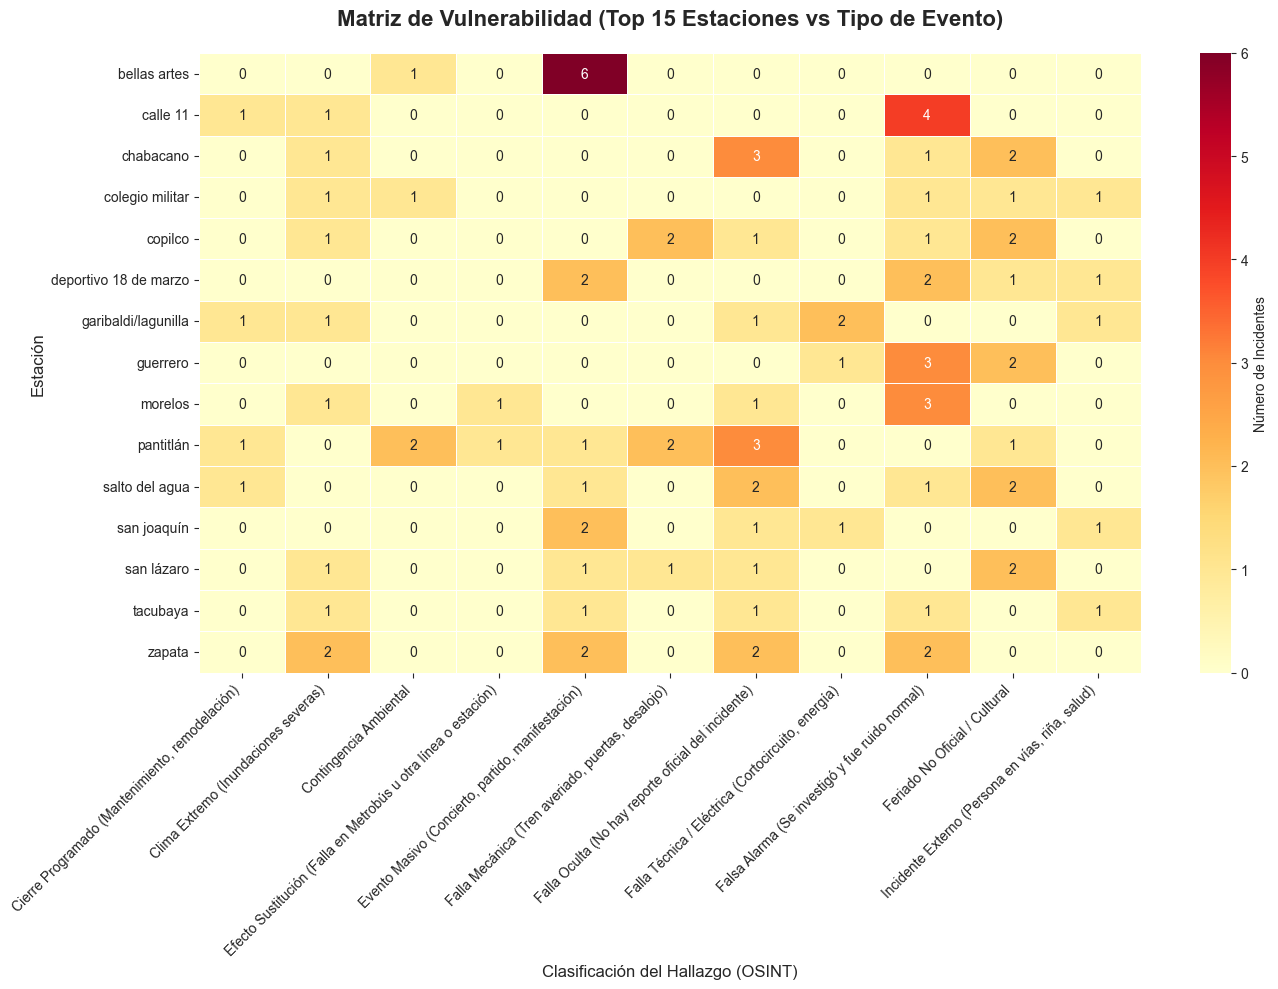


 TOP 5 CASOS CRÍTICOS

Caso de Estudio #1 | Impacto: 42,277 pasajeros (Alza (Pico atípico))
Fecha: 2022-01-02 0:00:00 | Línea: linea 8 | Estación: constitución de 1917
Causa Detectada: Feriado No Oficial / Cultural
Descripción: Afluencia a la alza dado eventos de temporada de inicio de año e inicio de recuperación de periodo postpandemia
Evidencia: Sin fuente URL

Caso de Estudio #2 | Impacto: -28,037 pasajeros (Baja (Caída atípica))
Fecha: 2024-03-29 0:00:00 | Línea: linea b | Estación: buenavista
Causa Detectada: Efecto Sustitución (Falla en Metrobús u otra línea o estación)
Descripción: Buenavista, los usuarios reportan tiempos de espera de 10 minutos en la estación San Lázaro (que conecta con el Metrobús).
Evidencia: https://www.milenio.com/politica/comunidad/metro-metrobus-cdmx-hoy-29-marzo-2024-ultimas-noticias-en-vivo-atm

Caso de Estudio #3 | Impacto: -26,188 pasajeros (Baja (Caída atípica))
Fecha: 2025-11-25 0:00:00 | Línea: linea 2 | Estación: pino suárez
Causa Detectada: Ev

In [120]:
# 0. CARGA DE DATOS
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')

# los nombres de columnas estan estandarizados (minúsculas para el código)
df_muestra.columns = df_muestra.columns.str.lower()
# La columna se llama 'hallazgo_principal', se renombra a 'hallazgo' por simplicidad
if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# MATRIZ DE VULNERABILIDAD (Heatmap)
# se toman solo el TOP 15 de estaciones más afectadas
top_estaciones = df_muestra['estacion'].value_counts().head(15).index

# Filtrado del dataframe solo con esas estaciones
df_top_est = df_muestra[df_muestra['estacion'].isin(top_estaciones)]

# Creamos una tabla cruzada entre Estación y Hallazgo
matriz_vuln = pd.crosstab(df_top_est['estacion'], df_top_est['hallazgo'])

plt.figure(figsize=(14, 10))
plt.title('Matriz de Vulnerabilidad (Top 15 Estaciones vs Tipo de Evento)', fontsize=16, fontweight='bold', pad=20)

# Generamos el Mapa de Calor
sns.heatmap(
    matriz_vuln, 
    annot=True,          # Muestra el número dentro del cuadro
    fmt='d',             # Formato entero
    cmap='YlOrRd',       # Paleta de colores: Amarillo -> Naranja -> Rojo (Alerta)
    linewidths=.5,       # Líneas de separación
    cbar_kws={'label': 'Número de Incidentes'}
)

plt.xlabel('Clasificación del Hallazgo (OSINT)', fontsize=12)
plt.ylabel('Estación', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# EXTRACCIÓN DE CASOS CRÍTICOS
print("\n" + "="*60)
print(" TOP 5 CASOS CRÍTICOS")
print("="*60)

# Calculo del impacto absoluto para encontrar los eventos más violentos
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# Orden de mayor a menor impacto y obtención de los 5 principales
top_casos = df_muestra.sort_values('impacto_absoluto', ascending=False).head(5)

# Iteración sobre los 5 casos para imprimirlos con formato de "Ficha Técnica"
for i, (_, row) in enumerate(top_casos.iterrows(), 1):
    print(f"\nCaso de Estudio #{i} | Impacto: {row['impacto']:,.0f} pasajeros ({row['direccion_anomalia']})")
    print(f"Fecha: {row['fecha']} | Línea: {row['linea']} | Estación: {row['estacion']}")
    print(f"Causa Detectada: {row['hallazgo']}")
    
    # Manejar el caso de que la descripción esté vacía
    desc = row.get('descripcion_incidente', 'Sin descripción detallada')
    if pd.isna(desc): desc = 'Sin descripción detallada'
    
    print(f"Descripción: {desc}")
    
    fuente = row.get('link_fuente_1', 'Sin fuente URL')
    if pd.isna(fuente): fuente = 'Sin fuente URL'
    print(f"Evidencia: {fuente}")

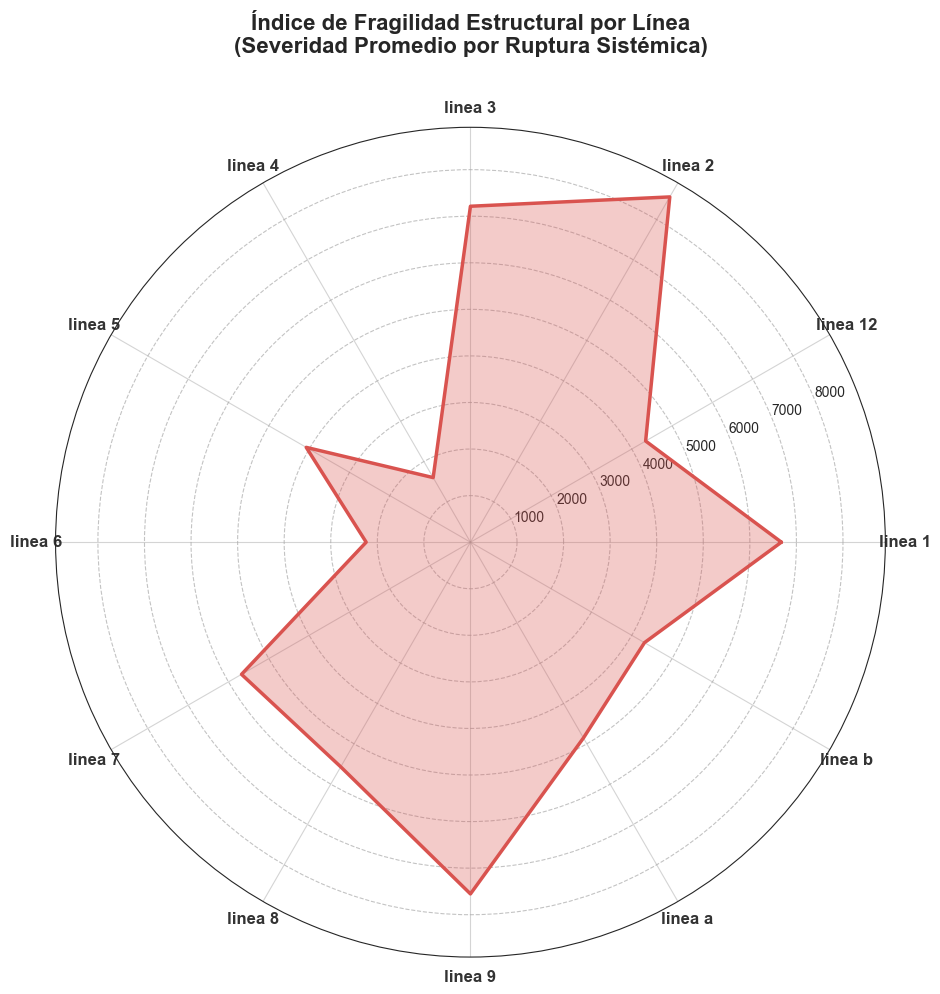

In [121]:
# 0. CARGA Y PREPARACIÓN DE DATOS
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')
df_muestra.columns = df_muestra.columns.str.lower()

if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# Uso del impacto absoluto para medir el "shock" sin importar si es alza o baja
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# CÁLCULO DEL ÍNDICE DE FRAGILIDAD / RESILIENCIA
# Agrupación por línea y cálculo del Promedio de Impacto por evento
resiliencia = df_muestra.groupby('linea')['impacto_absoluto'].mean().reset_index()

# Ordenar las líneas alfabéticamente para que el radar tenga un orden lógico
resiliencia = resiliencia.sort_values('linea')

# Preparar listas de datos para el Radar Chart
categorias = resiliencia['linea'].tolist()
valores = resiliencia['impacto_absoluto'].tolist()

# El gráfico de radar necesita que el último valor 
# sea igual al primero para que el polígono "cierre" visualmente.
valores += valores[:1]

# Calcular los ángulos de la circunferencia para cada categoría (Línea)
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

# DIBUJAR EL GRÁFICO DE RADAR
# Iniciar figura especificando que es una proyección polar
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Dibujar el contorno del polígono
ax.plot(angulos, valores, color='#D9534F', linewidth=2.5, linestyle='solid', label='Impacto Promedio (Fragilidad)')

# Rellenar el área interior
ax.fill(angulos, valores, color='#D9534F', alpha=0.3)

# Configurar las etiquetas de las Líneas en el borde del círculo
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=12, fontweight='bold', color='#333333')

ax.yaxis.grid(True, color='#AAAAAA', linestyle='--', alpha=0.7)
ax.xaxis.grid(True, color='#AAAAAA', linestyle='-', alpha=0.5)

# Título del gráfico
plt.title('Índice de Fragilidad Estructural por Línea\n(Severidad Promedio por Ruptura Sistémica)', 
          size=16, fontweight='bold', y=1.08)

plt.tight_layout()
plt.show()

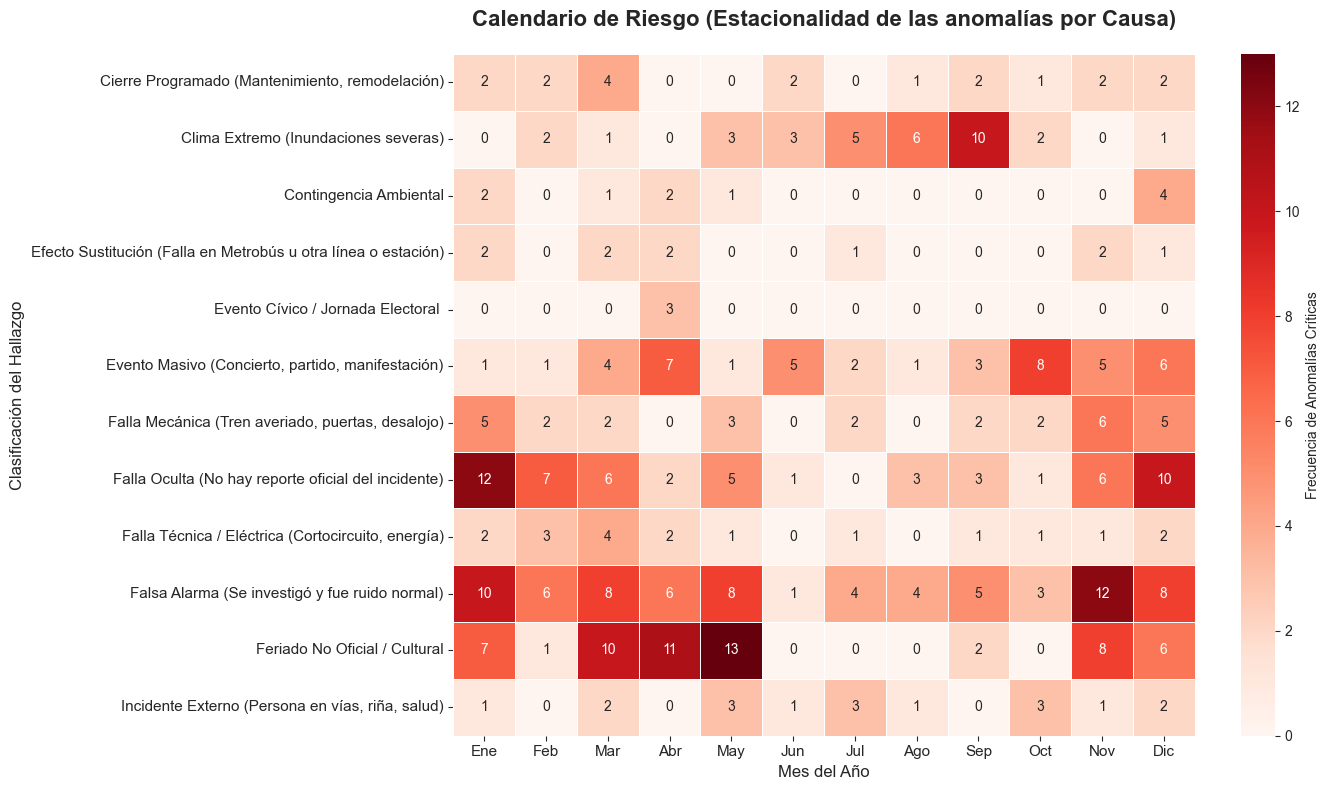

In [122]:
# 1. Cargar la bitácora oficial de investigación manual
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv') # O bitacora_oficial_reparada.csv
df_muestra.columns = df_muestra.columns.str.lower()

if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})

# 2. Extraer el mes de la fecha
# Converción de la columna a tipo datetime
df_muestra['fecha'] = pd.to_datetime(df_muestra['fecha'])

# número del mes (1 al 12)
df_muestra['mes_num'] = df_muestra['fecha'].dt.month

# converción de los números a nombres de meses en español para la gráfica
meses_esp = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 
             7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_muestra['mes'] = df_muestra['mes_num'].map(meses_esp)

# 3. Crear la Matriz Temporal
heatmap_data = pd.crosstab(df_muestra['hallazgo'], df_muestra['mes'])

# Reorden de las columnas para que no salgan alfabéticamente, sino en orden de calendario
meses_presentes = [m for m in meses_esp.values() if m in heatmap_data.columns]
heatmap_data = heatmap_data[meses_presentes]

# 4. Graficar el Heatmap
plt.figure(figsize=(14, 8))
plt.title('Calendario de Riesgo (Estacionalidad de las anomalías por Causa)', fontsize=16, fontweight='bold', pad=20)

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='d', 
    cmap='Reds', # Paleta de alerta
    linewidths=.5,
    cbar_kws={'label': 'Frecuencia de Anomalías Críticas'}
)

plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Clasificación del Hallazgo', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [123]:
# 1. Preparación de los datos
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')
df_muestra.columns = df_muestra.columns.str.lower()

if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

df_muestra['impacto_abs'] = df_muestra['impacto'].abs()
impacto_causas = df_muestra.groupby('hallazgo')['impacto_abs'].sum().reset_index()

# Filtro flexible con .str.contains()
total_detectado = impacto_causas['impacto_abs'].sum()

# Busca cualquier fila que contenga las palabras "Falla Oculta"
mascara_oculta = impacto_causas['hallazgo'].str.contains('Falla Oculta', case=False, na=False)

# Separación correcta entre causas explicadas y la falla oculta, asegurando que la suma de la falla oculta se mantenga como un bloque independiente
explicadas = impacto_causas[~mascara_oculta].sort_values('impacto_abs', ascending=False)
falla_oculta_valor = impacto_causas[mascara_oculta]['impacto_abs'].sum()

# Construcción de la estructura de la Cascada
etiquetas = ["Impacto Total Detectado"] + explicadas['hallazgo'].tolist() + ["Falla sin reportar"]

valores = [total_detectado] + [-v for v in explicadas['impacto_abs']] + [0]
medidas = ["relative"] + ["relative"] * len(explicadas) + ["total"]

# Creación de la Gráfica Sustractiva
# Dividición entre 1,000 y uso del sufijo 'K' para Miles, con 0 decimales para mayor limpieza
text_miles = [f"{v/1000:.0f}K" if v >= 0 else f"-{abs(v)/1000:.0f}K" for v in valores[:-1]] + [f"{falla_oculta_valor/1000:.0f}K"]

fig_waterfall = go.Figure(go.Waterfall(
    name="Auditoría",
    orientation="v",
    measure=medidas,
    x=etiquetas,
    y=valores,
    textposition="outside",
    text=text_miles, # nuevo formato en miles
    connector={"line": {"color": "rgb(63, 63, 63)", "width": 1.5}},
    increasing={"marker": {"color": "#4C72B0"}}, # Azul para el Total Inicial
    decreasing={"marker": {"color": "#AAB6C4"}}, # Gris para lo Explicado
    totals={"marker": {"color": "#D9534F"}}     # Rojo para la Deuda de fallas ocultas
))

fig_waterfall.update_layout(
    title='<b> Auditoría de fallas sin reportar</b><br><sup>Descontando causas explicadas (OSINT) del total de la muestra de anomalías críticas</sup>',
    waterfallgap=0.3,
    template='plotly_white',
    height=700,
    margin=dict(t=100, b=200),
    yaxis=dict(title='Impacto en Pasajeros (Absoluto)', tickformat=","),
    xaxis=dict(tickangle=-45)
)

fig_waterfall.show()